In [1]:
# ============================================================
# SETUP 0 — Instalasi Pustaka
# ============================================================

!pip install transformers accelerate bitsandbytes pandas matplotlib scipy -q
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.7 MB/s eta 0:00:00
All packages installed.


In [2]:
# ============================================================
# SETUP 1 — Mount Google Drive
# Tujuan: menyediakan akses ke file dataset (Food KB, region
#         mapping, koordinat) yang tersimpan di Drive.
# ============================================================

import os

# 1. Pastikan Drive ter-mount
from google.colab import drive
drive.mount('/content/drive')

# 2. Kita list folder di MyDrive untuk melihat nama yang "dikenali" Python
print("Daftar folder di MyDrive:")
print(os.listdir("/content/drive/MyDrive/Percobaan TA/Food KB/Data"))

Mounted at /content/drive
Daftar folder di MyDrive:
['qwen_country_layer_repr.pkl', 'qwen_pure_food_cache.pkl', 'llama_country_layer_repr.pkl', 'llama_pure_food_cache.pkl', 'gemma_country_layer_repr.pkl', 'gemma_pure_food_cache.pkl', 'sarvam_country_layer_repr.pkl', 'sarvam_pure_food_cache.pkl', 'mistral_country_layer_repr.pkl', 'mistral_pure_food_cache.pkl', 'kanana_country_layer_repr.pkl', 'kanana_pure_food_cache.pkl', 'croissantLLM_country_layer_repr.pkl', 'croissantLLM_pure_food_cache.pkl', 'qwen_pure_food_alllayers_fp16.npy', 'qwen_pure_food_alllayers_names.json', 'sarvam_pure_food_alllayers_fp16.npy', 'sarvam_pure_food_alllayers_names.json', 'Qwen2.5-3B_kuliner_layerwise_agregat.csv', 'Qwen2.5-3B_kuliner_layerwise_individual.csv', 'Qwen2.5-3B_kuliner_layerwise_error.png', 'Qwen2.5-3B_kuliner_layerwise_r2.png', 'Qwen2.5-3B_kuliner_layerwise_region_heatmap.png', 'sarvam-1_kuliner_layerwise_agregat.csv', 'sarvam-1_kuliner_layerwise_individual.csv', 'sarvam-1_kuliner_layerwise_error.

In [3]:
# ============================================================
# SETUP 2 — Import dan Konfigurasi Global
# ============================================================

import gc
import os
import ast
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
import pickle
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import RidgeCV

# ── Global Configuration ──
MODEL_ID = "croissantllm/CroissantLLMBase"
FOOD_KB_ID = "1ActuQ8w6h6zXOih6mYDhYft0k3D4eINr"
REGION_CSV_ID = "1XCWJhLua97y-JAu0_p8zI45TawJPmwcE"
COORD_CSV_ID = "1Hu_4ldMVtLOUguj6JmYWJ-31CfmOxdtm"
PROMPT_TEMPLATE = "The most popular traditional food in {country} is"
LOAD_FROM_DISK = True
SAVE_DIR = "/content/drive/MyDrive/Percobaan TA/Food KB/Data/"
COUNTRY_FILE = os.path.join(SAVE_DIR, "croissantLLM_country_layer_repr.pkl")
FOOD_FILE = os.path.join(SAVE_DIR, "croissantLLM_pure_food_cache.pkl")


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_drive_url(file_id):
    return f'https://drive.google.com/uc?export=download&id={file_id}'

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    # Perbaikan: total_mem -> total_memory
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

print("Configuration loaded.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Configuration loaded.


In [4]:
# ============================================================
# SETUP 3 — Pemuatan Model dan Tokenizer
# ============================================================

def _vram_report(label=""):
    """Print current GPU memory usage."""
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resrv = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM [{label}]: {alloc:.2f} GB allocated, "
              f"{resrv:.2f} GB reserved")

print("⏳ Loading tokenizer …")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("⏳ Loading croissantllm/CroissantLLMBase in 4-bit NF4 …")

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    trust_remote_code=True,
    output_hidden_states=True,
)

model.eval()

num_layers = model.config.num_hidden_layers

print(f"Model loaded — {sum(p.numel() for p in model.parameters())/1e9:.2f}B params, "
      f"{num_layers} layers")
_vram_report("post-load")

⏳ Loading tokenizer …


config.json:   0%|          | 0.00/716 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.35M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/18.9k [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded — 0.74B params, 24 layers
VRAM [post-load]: 1.15 GB allocated, 1.27 GB reserved


In [5]:
# ============================================================
# SETUP 4 — Pemuatan Dataset
# Memuat Food Knowledge Base, pemetaan region, dan koordinat
# negara yang menjadi basis seluruh eksperimen di bawah.
# ============================================================

try:
    food_kb_df = pd.read_csv(get_drive_url(FOOD_KB_ID), on_bad_lines='skip', engine='python')
    print(f"Loaded Food KB: {food_kb_df.shape[0]} rows.")
except Exception as e:
    print(f"Gagal memuat Food KB dari Drive: {e}")

# ── 4b. Load Region Mapping ────────────────────────────────
try:
    region_df = pd.read_csv(get_drive_url(REGION_CSV_ID))
    region_mapping = region_df.set_index('country')['region'].to_dict()
    print(f"Region mapping loaded: {len(region_mapping)} countries.")
except Exception as e:
    print(f"Gagal memuat Region Mapping: {e}")
    region_mapping = {}

    print(f"Region mapping loaded: {len(region_mapping)} countries.")
except Exception as e:
    print(f"Gagal memuat country_region.csv: {e}")
    region_mapping = {}

# Fungsi baru untuk klasifikasi (Gantikan classify_north_south)
def get_country_region(country):
    """Mengambil region berdasarkan CSV, default ke 'Other' jika tidak ada."""
    return region_mapping.get(country, "Other")

# ── 4b. Robust Deep Parser for List-Strings ────────────────
def _safe_parse_all(val):
    """
    Membongkar string, memproses Korea, dan mengonsolidasi UK.
    """
    if pd.isna(val): return []

    extracted = []
    if isinstance(val, str):
        val = val.strip()
        if not val: return []
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                extracted = [str(i).strip() for i in parsed if i]
            else:
                extracted = [str(parsed).strip()]
        except (ValueError, SyntaxError):
            clean = val.replace('[','').replace(']','').replace('"','').replace("'",'')
            extracted = [i.strip() for i in clean.split(',') if i.strip()]
    else:
        extracted = [str(val).strip()]

    final_list = []
    # Daftar negara yang ingin digabung ke United Kingdom
    UK_CONSTITUENTS = ["England", "Wales", "Scotland"]

    for c in extracted:
        c_clean = c.strip()

        # 1. Logika Pecah Korea
        if c_clean == "Korea":
            final_list.extend(["North Korea", "South Korea"])

        # 2. Logika Konsolidasi United Kingdom
        elif c_clean in UK_CONSTITUENTS:
            final_list.append("United Kingdom")

        # 3. Negara lainnya tetap apa adanya (termasuk "Global")
        else:
            final_list.append(c_clean)

    # Menghapus duplikat (misal jika ada makanan yang listnya ["England", "Scotland"]
    # maka akan jadi ["United Kingdom"] saja, bukan double)
    return list(set(final_list))

# ── 4c. Extract ALL Unique Countries (FILTERED) ──────────────────────
all_countries_set = set()
if 'countries' in food_kb_df.columns:
    for raw in food_kb_df["countries"]:
        extracted = _safe_parse_all(raw)
        all_countries_set.update(extracted)

# FILTER: Ambil semua negara KECUALI yang bernama "Global"
countries = sorted([
    c for c in all_countries_set
    if c and c.lower() != "global"
])

print(f"Filtered {len(countries)} countries for experiment (Excluded 'Global').")

# ── 4d. Extract ALL Unique Food Names ──────────────────────
if 'name' in food_kb_df.columns:
    # Mengambil semua makanan unik tanpa batasan TOP_K
    all_foods = food_kb_df["name"].dropna().unique().tolist()
else:
    print("Kolom 'name' tidak ditemukan di CSV!")
    all_foods = []

# ── 4e. Build BPE token-id sequences for ALL foods (REVISED) ──
food_names = []
food_token_sequences = []

print(f"⏳ Tokenizing {len(all_foods)} food names (full sequences)...")
for name in all_foods:
    name_str = str(name).strip()
    # Gunakan spasi di depan untuk format autoregresif
    ids = tokenizer.encode(" " + name_str, add_special_tokens=False)

    if len(ids) > 0:
        food_names.append(name_str)
        food_token_sequences.append(ids)

# ── Summary (Updated) ──
print(f"Full Dataset Parsed:")
print(f"   - Total Negara: {len(countries)}")
print(f"   - Total Makanan: {len(food_names)}")
print(f"   - Contoh: '{food_names[0]}' diwakili oleh {len(food_token_sequences[0])} token: {food_token_sequences[0]}")

Loaded Food KB: 2414 rows.
Region mapping loaded: 192 countries.
Filtered 187 countries for experiment (Excluded 'Global').
⏳ Tokenizing 2414 food names (full sequences)...
Full Dataset Parsed:
   - Total Negara: 187
   - Total Makanan: 2414
   - Contoh: 'Rawon' diwakili oleh 3 token: [1248, 2554, 1105]


In [6]:
# ============================================================
# SETUP 5 — Utilitas Bersama
# Guard pengecekan model termuat, fungsi logit lens, dan
# forward pass aman yang dipakai ulang di beberapa eksperimen.
# ============================================================

def _check_model_loaded():
    """Guard: abort early if the model cell hasn't been run."""
    assert 'model' in dir() or 'model' in globals(), (
        "`model` not found. Run Cell 3 (Model Loading) first."
    )
    assert 'tokenizer' in dir() or 'tokenizer' in globals(), (
        "`tokenizer` not found. Run Cell 3 (Model Loading) first."
    )

def logit_lens_project(model, hidden_state):
    """
    Shared projection: apply final RMSNorm, then unembedding.
    Parameters
    ----------
    model        : the loaded Sarvam model
    hidden_state : tensor of shape (1, D) — one position's activations
    Returns
    -------
    logits : tensor of shape (1, V) — full vocabulary logits
    """
    # 1. Pastikan input dalam dtype yang sesuai dengan model (float16/bfloat16)
    h_input = hidden_state.to(next(model.parameters()).dtype)

    # 2. Apply Final LayerNorm (RMSNorm) - Penting untuk Qwen/Llama
    h_normed = model.model.norm(h_input)

    # 3. Project ke lm_head menggunakan float32 untuk akurasi interpretability
    logits = torch.matmul(
        h_normed.float(),
        model.lm_head.weight.detach().t().float()
    )
    return logits

def safe_forward(model, tokenizer, prompt):
    """
    Shared forward pass with output_hidden_states=True.
    Returns
    -------
    hidden_states : tuple of (num_layers+1) tensors
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Kita hanya butuh token terakhir [:, -1, :] untuk Logit Lens pada prediksi 'is'
    # Mengonversi ke float32 di sini untuk stabilisasi kalkulasi di cell berikutnya
    hidden_states = tuple(h[:, -1, :].float() for h in outputs.hidden_states)

    del outputs, inputs
    return hidden_states

def flush():
    """Aggressive VRAM + RAM cleanup."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Shared utilities defined: logit_lens_project, safe_forward, flush")

Shared utilities defined: logit_lens_project, safe_forward, flush


In [7]:
# ============================================================
# SETUP 6 — Utilitas Probing Sferis (versi awal)
# Catatan: fungsi di sel ini kemudian DITULIS ULANG dengan
# cakupan lebih lengkap di Eksperimen C (lihat sel Utilitas
# Geometri Sferis sebelum Eksperimen C.1). Dibiarkan di sini
# agar cell Kontrol/Eksperimen A yang berjalan lebih dulu tidak
# error jika sewaktu-waktu memanggil fungsi ini.
# ============================================================

import numpy as np

def latlon_to_xyz(lat_deg, lon_deg):
    """Konversi koordinat lat/lon (derajat) ke vektor satuan 3D."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.stack([x, y, z], axis=-1)  # shape (..., 3)

def xyz_to_latlon(xyz):
    """Konversi balik vektor 3D (tidak harus satuan) ke lat/lon derajat."""
    xyz = np.atleast_2d(xyz)
    norm = np.linalg.norm(xyz, axis=-1, keepdims=True)
    norm[norm == 0] = 1e-9  # guard pembagian nol
    xyz_unit = xyz / norm
    lat = np.degrees(np.arcsin(np.clip(xyz_unit[..., 2], -1, 1)))
    lon = np.degrees(np.arctan2(xyz_unit[..., 1], xyz_unit[..., 0]))
    return lat, lon

def great_circle_deg(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam derajat busur (bukan km) — konsisten dengan
    skala error lama (MAE dalam derajat) supaya angka tetap bisa dibandingkan."""
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return np.degrees(c)

print("Spherical utilities defined: latlon_to_xyz, xyz_to_latlon, great_circle_deg")

Spherical utilities defined: latlon_to_xyz, xyz_to_latlon, great_circle_deg


In [8]:
# ============================================================
# EKSPERIMEN KONTROL — Ekstraksi Representasi Berbasis Prompt
# Metode: teacher-forcing pada prompt yang menyertakan nama
#         negara secara eksplisit -> vektor log-probabilitas
#         atas kosakata makanan (country_layer_repr).
# Peran: kondisi kontrol / batas atas, BUKAN jalur analisis
#        utama, karena prompt menyertakan penanda geografis
#        eksplisit (lihat Bab III.2.1).
# ============================================================

import torch.nn.functional as F
import torch
import numpy as np
import gc
from transformers.cache_utils import DynamicCache

print("=" * 65)
print("EKSPERIMEN KONTROL — EKSTRAKSI REPRESENTASI BERBASIS PROMPT")
print("Metode: batch per negara dengan pembersihan cache KV bertahap")
print("=" * 65)

_check_model_loaded()
country_layer_repr = {}
BATCH_SIZE = 512

# --- LOGIKA AUTO-LOAD (SISIPAN) ---
if os.path.exists(COUNTRY_FILE):
    print(f"Data ditemukan di Drive! Memuat {COUNTRY_FILE}...")
    with open(COUNTRY_FILE, 'rb') as f:
        country_layer_repr = pickle.load(f)
    print(f"Berhasil memuat {len(country_layer_repr)} negara. (Inference di-skip)")
    RUN_INFERENCE = False
else:
    print("Data tidak ditemukan di Drive. Menjalankan inference...")
    RUN_INFERENCE = True

# Seluruh proses di bawah ini hanya berjalan jika data tidak ada di Drive
if RUN_INFERENCE:
    # ── 1. Helper: Expansion yang Lebih Aman ──
    def expand_kv_cache_to_obj(past_kv, batch_size):
        if past_kv is None:
            return None

        new_cache = DynamicCache()

        for layer_idx, layer in enumerate(past_kv.layers):
            k = layer.keys    # shape: (1, num_heads, seq_len, head_dim)
            v = layer.values

            k_exp = k.expand(batch_size, -1, -1, -1).clone().contiguous()
            v_exp = v.expand(batch_size, -1, -1, -1).clone().contiguous()
            new_cache.update(k_exp, v_exp, layer_idx=layer_idx)

        return new_cache

    # ── 2. Grouping Makanan ──
    food_groups = {}
    for i, seq in enumerate(food_token_sequences):
        l = len(seq)
        if l not in food_groups: food_groups[l] = []
        food_groups[l].append({'id': i, 'tokens': seq})

    # Gunakan Inference Mode (Lebih ketat & irit daripada no_grad)
    for ci, country in enumerate(countries):
        print(f"  [{ci+1}/{len(countries)}] Processing: {country:.<20s}", end="", flush=True)

        prompt = PROMPT_TEMPLATE.format(country=country)
        prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

        try:
            with torch.inference_mode():
                # A. Prompt Forward
                outputs = model(prompt_ids, use_cache=True)
                # Ambil KV-Cache asli
                past_kv = outputs.past_key_values
                # Simpan logits token pertama ke CPU
                first_lps = F.log_softmax(outputs.logits[:, -1, :], dim=-1).float().cpu().squeeze(0).numpy()

                # SEGERA hapus outputs agar VRAM lega
                del outputs

                final_scores = np.zeros(len(food_names), dtype=np.float32)

                # B. Loop Makanan
                for length, group in food_groups.items():
                    for item in group:
                        final_scores[item['id']] = first_lps[item['tokens'][0]]

                    if length > 1:
                        for i in range(0, len(group), BATCH_SIZE):
                            sub_group = group[i : i + BATCH_SIZE]
                            curr_bs = len(sub_group)

                            rem_tokens = torch.tensor([item['tokens'][:-1] for item in sub_group], device=DEVICE)
                            target_ids = [item['tokens'][1:] for item in sub_group]

                            # Expand KV-Cache
                            expanded_cache = expand_kv_cache_to_obj(past_kv, curr_bs)

                            res_out = model(rem_tokens, past_key_values=expanded_cache, use_cache=False)
                            # Hitung log-prob di CPU secara bertahap agar tidak numpuk
                            res_lps = F.log_softmax(res_out.logits.float(), dim=-1).cpu()

                            for b_idx in range(curr_bs):
                                f_id = sub_group[b_idx]['id']
                                for t_pos, tid in enumerate(target_ids[b_idx]):
                                    final_scores[f_id] += res_lps[b_idx, t_pos, tid].item()

                            for layer in expanded_cache.layers:
                                layer.keys = None
                                layer.values = None
                            del expanded_cache
                            # Tiap 5 batch, kosongkan cache
                            if (i // BATCH_SIZE) % 5 == 0:
                                torch.cuda.empty_cache()

                # C. Softmax & Simpan
                stable_repr = final_scores - np.mean(final_scores)

                full_repr = np.zeros((num_layers, len(food_names)), dtype=np.float32)

                full_repr[num_layers - 1] = stable_repr
                country_layer_repr[country] = full_repr

                # --- D. FINAL CLEANUP NEGARA ---
                # Hapus referensi KV-cache asli
                for layer in past_kv.layers:
                    layer.keys = None
                    layer.values = None
                del past_kv, first_lps, final_scores, prompt_ids

                gc.collect()
                torch.cuda.empty_cache()

                v_info = torch.cuda.mem_get_info()
                vram_free = v_info[0] / 1e9
                print(f"Done. (VRAM Sisa: {vram_free:.2f} GB)", flush=True)

        except RuntimeError as e:
            print(f"Error: {e}")
            torch.cuda.empty_cache()
            gc.collect()
            continue

    # --- SIMPAN KE DRIVE SETELAH LOOP SELESAI ---
    with open(COUNTRY_FILE, 'wb') as f:
        pickle.dump(country_layer_repr, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"\n HASIL INFERENCE DISIMPAN KE: {COUNTRY_FILE}")

print("\nEkstraksi selesai.")

EKSPERIMEN KONTROL — EKSTRAKSI REPRESENTASI BERBASIS PROMPT
Metode: batch per negara dengan pembersihan cache KV bertahap
Data ditemukan di Drive! Memuat /content/drive/MyDrive/Percobaan TA/Food KB/Data/croissantLLM_country_layer_repr.pkl...
Berhasil memuat 187 negara. (Inference di-skip)

Ekstraksi selesai.


In [9]:
# ============================================================
# EKSPERIMEN KONTROL — Pemeriksaan Sanity
# Menampilkan top-5 makanan dengan probabilitas tertinggi per
# negara sebagai pengecekan kualitatif hasil ekstraksi Cell 7.
# ============================================================

test_countries = ["Indonesia", "Japan", "Italy", "Mexico", "Lebanon"]

for c in test_countries:
    if c in country_layer_repr:
        # Ambil vektor probabilitas dari layer terakhir
        probs = country_layer_repr[c][num_layers - 1]

        # Ambil 5 index dengan nilai probabilitas tertinggi
        top_5_idx = np.argsort(probs)[-5:][::-1]

        print(f"\n{c.upper()}:")
        for idx in top_5_idx:
            print(f"  - {food_names[idx]:<20} | Prob: {probs[idx]:.4f}")


INDONESIA:
  - Sate                 | Prob: 17.8192
  - Rendang              | Prob: 17.3860
  - Roti                 | Prob: 16.9074
  - Bakso                | Prob: 16.6613
  - Pizza                | Prob: 16.0795

JAPAN:
  - Udon                 | Prob: 19.5904
  - Sushi                | Prob: 19.2124
  - Takoyaki             | Prob: 18.8325
  - Tonkatsu             | Prob: 18.4440
  - Okonomiyaki          | Prob: 18.0852

ITALY:
  - Pizza                | Prob: 21.5626
  - Risotto              | Prob: 20.1272
  - Ricotta              | Prob: 17.6967
  - Parmigiana           | Prob: 17.5613
  - Pastizz              | Prob: 17.3795

MEXICO:
  - Churro               | Prob: 18.1325
  - Pozole               | Prob: 17.4808
  - Tamale               | Prob: 17.4081
  - Guacamole            | Prob: 17.3677
  - Tortilla             | Prob: 17.1060

LEBANON:
  - Falafel              | Prob: 18.9693
  - Kebab                | Prob: 18.3261
  - Harira               | Prob: 18.1735
  - Baba  

EKSPERIMEN KONTROL — PROBING LINEAR (AGREGAT-NEGARA)
Loaded coordinates for 245 countries from CSV.

 HASIL EVALUASI LINEAR PROBE (GLOBAL):
Latitude  | MAE: 4.92°
Longitude | MAE: 10.99°
AVERAGE GLOBAL ERROR: 10.04 derajat (SD: 8.97°, n=184)
Latitude R² (Kontrol): 0.915
Longitude R² (Kontrol): 0.753


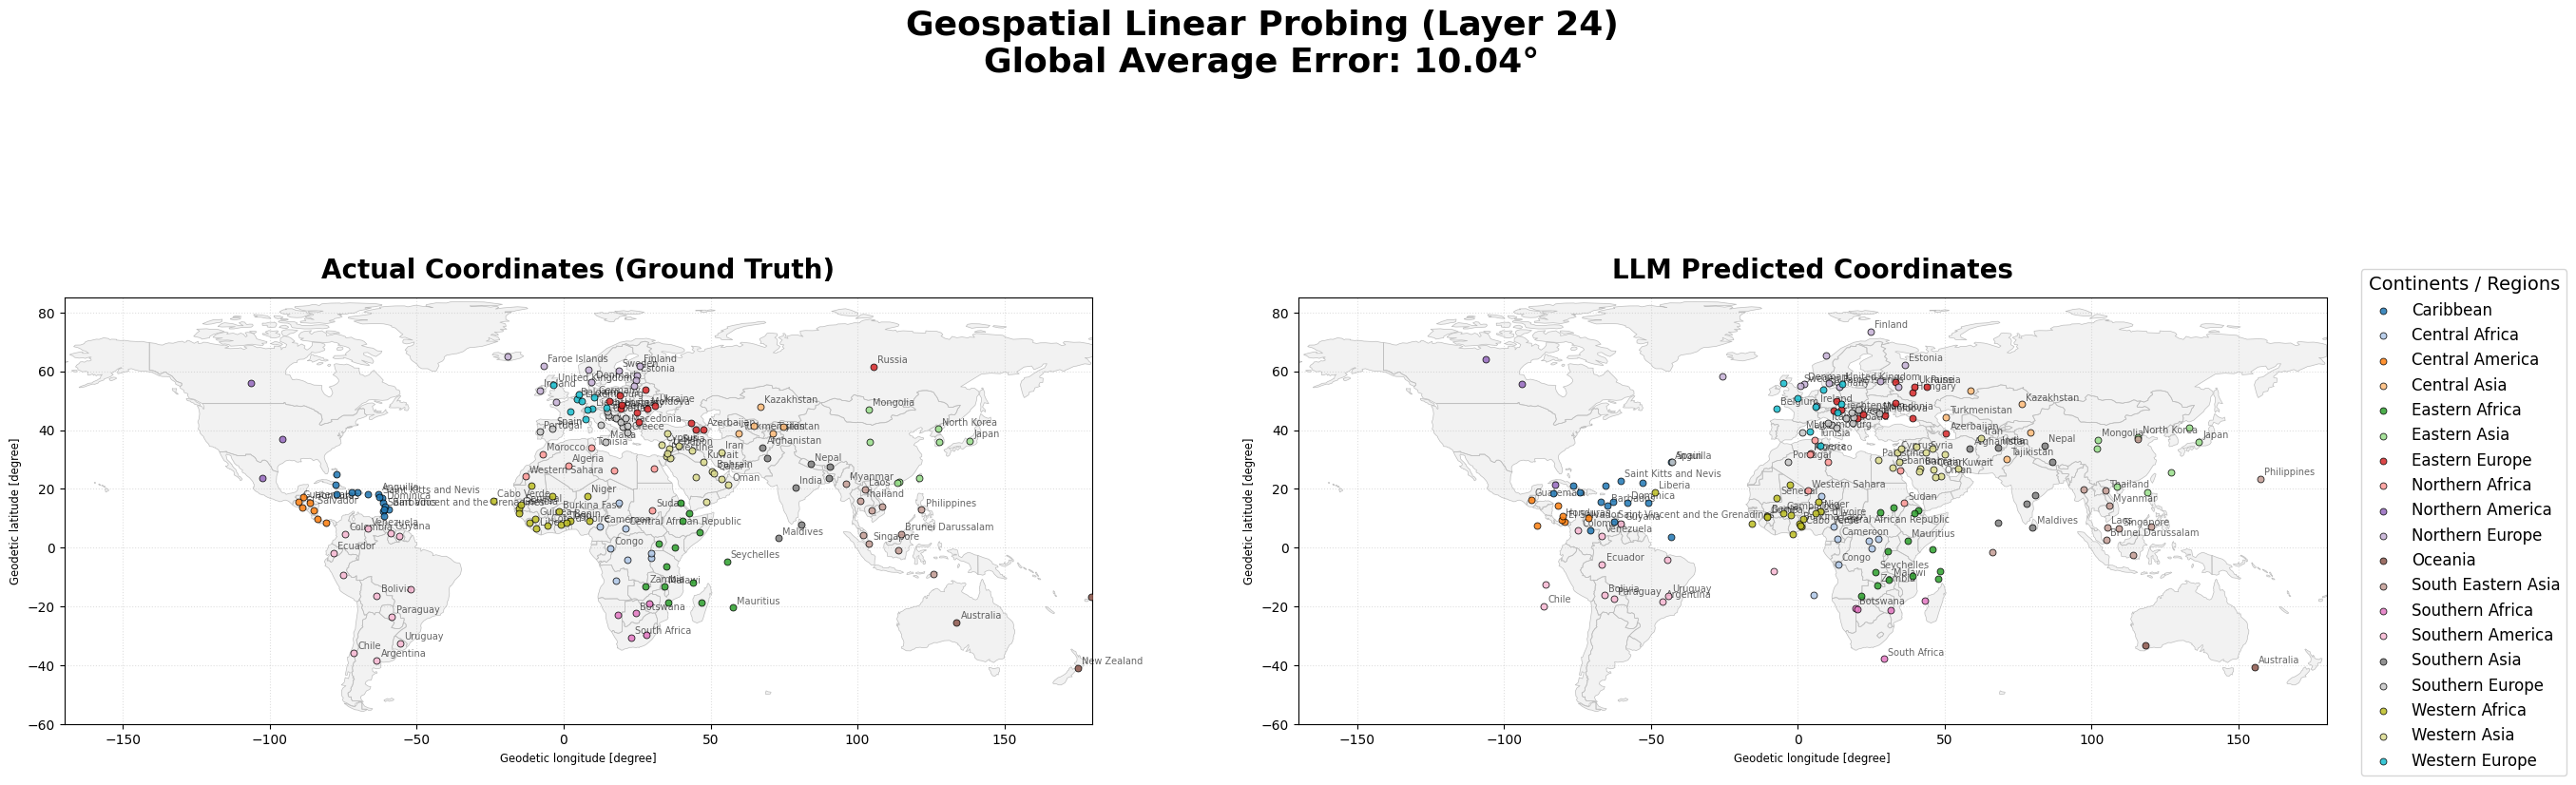

In [10]:
# ============================================================
# EKSPERIMEN KONTROL — Probing Linear (Agregat-Negara)
# Meregresi country_layer_repr (Cell 7) ke koordinat lat/lon.
# Menjawab RQ1 untuk kondisi kontrol/batas atas.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("=" * 65)
print("EKSPERIMEN KONTROL — PROBING LINEAR (AGREGAT-NEGARA)")
print("=" * 65)

# ── 1. Load Koordinat ──
try:
    coord_df = pd.read_csv(get_drive_url(COORD_CSV_ID))
    country_coords = {}
    for _, row in coord_df.iterrows():
        country_coords[row['name'].strip()] = {
            'lat': float(row['latitude']),
            'lon': float(row['longitude'])
        }

    # Penyesuaian Manual
    if "Korea" in country_coords:
        country_coords["North Korea"] = {'lat': 40.3, 'lon': 127.5}
        country_coords["South Korea"] = {'lat': 35.9, 'lon': 127.7}

    print(f"Loaded coordinates for {len(country_coords)} countries from CSV.")
except Exception as e:
    print(f"Gagal membaca CSV Koordinat: {e}")
    country_coords = {}

# ── 2. Persiapkan Data X dan Y ──
probe_layer_idx = num_layers - 1
X_list, y_lat_list, y_lon_list, valid_countries = [], [], [], []

for c in countries:
    if c in country_coords:
        feat = country_layer_repr[c][probe_layer_idx]
        X_list.append(feat)
        y_lat_list.append(country_coords[c]['lat'])
        y_lon_list.append(country_coords[c]['lon'])
        valid_countries.append(c)

X = np.array(X_list)
y_lat = np.array(y_lat_list)
y_lon = np.array(y_lon_list)

# ── 3. Train & Evaluate (5-Fold Cross-Validation) ──
# FIX: StandardScaler(with_std=False) dan RidgeCV, konsisten dengan
# kebijakan preprocessing/regularisasi di Eksperimen A/Baseline/B/D.
probe_model = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                      scoring='neg_mean_absolute_error'))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_xyz = latlon_to_xyz(y_lat, y_lon)
pred_xyz = cross_val_predict(probe_model, X, y_xyz, cv=cv)
pred_lat, pred_lon = xyz_to_latlon(pred_xyz)
gc_errors = great_circle_deg(y_lat, y_lon, pred_lat, pred_lon)
avg_global_error = gc_errors.mean()
std_global_error = gc_errors.std()  # TAMBAHAN: standar deviasi galat great-circle antar-negara

# --- TAMBAHAN: R² untuk komponen lintang dan bujur (Kontrol) ---
r2_lat_kontrol = r2_score(y_lat, pred_lat)
r2_lon_kontrol = r2_score(y_lon, pred_lon)
# -----------------------------------------------------------------

print("\n HASIL EVALUASI LINEAR PROBE (GLOBAL):")
print(f"Latitude  | MAE: {mean_absolute_error(y_lat, pred_lat):.2f}°")
print(f"Longitude | MAE: {mean_absolute_error(y_lon, pred_lon):.2f}°")
print(f"AVERAGE GLOBAL ERROR: {avg_global_error:.2f} derajat (SD: {std_global_error:.2f}°, n={len(gc_errors)})")
print(f"Latitude R² (Kontrol): {r2_lat_kontrol:.3f}")
print(f"Longitude R² (Kontrol): {r2_lon_kontrol:.3f}")

# ── 4. BANGUN DATAFRAME HASIL (PENTING: Harus sebelum Plotting) ──
analysis_data = []
for i, country in enumerate(valid_countries):
    analysis_data.append({
        "Country": country,
        "Region": get_country_region(country),
        "Actual_Lat": y_lat[i],
        "Actual_Lon": y_lon[i],
        "Pred_Lat": pred_lat[i],
        "Pred_Lon": pred_lon[i]
    })
df_results = pd.DataFrame(analysis_data)

# ── 5. LOAD BACKGROUND PETA (Mencegah NameError: world) ──
try:
    # Coba load dataset bawaan
    world_path = gpd.datasets.get_path('naturalearth_lowres')
    world = gpd.read_file(world_path)
except:
    # Fallback jika library geopandas versi baru (dataset dihapus)
    url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"
    world = gpd.read_file(url)

# ── 6. Visualisasi (PETA MAKSIMAL) ──
unique_regions = sorted(df_results['Region'].unique())
cmap = mpl.colormaps.get_cmap('tab20')
region_colors = {reg: cmap(i % 20) for i, reg in enumerate(unique_regions)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 12))
plt.suptitle(f"Geospatial Linear Probing (Layer {probe_layer_idx+1})\nGlobal Average Error: {avg_global_error:.2f}°",
             fontsize=26, fontweight='bold', y=0.95)

for ax, mode, title in zip([ax1, ax2], ["Actual", "Pred"],
                           ["Actual Coordinates (Ground Truth)", "LLM Predicted Coordinates"]):
    # Gambar Background
    world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
    world.plot(ax=ax, color='#f2f2f2', zorder=0)

    # Plot per region
    for reg in unique_regions:
        reg_data = df_results[df_results['Region'] == reg]
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        ax.scatter(lons, lats, color=region_colors[reg], edgecolor='black',
                   linewidth=0.6, s=25, alpha=0.85, label=reg, zorder=5)

    ax.set_title(title, fontsize=20, pad=15, fontweight='semibold')
    ax.set_xlim(-170, 180)
    ax.set_ylim(-60, 85)
    ax.grid(True, linestyle=':', alpha=0.4)

    # Label Negara (Sampling)
    for i, row in df_results.reset_index().iterrows():
        if i % 2 == 0: # Biar tidak terlalu penuh
            tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
            ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
            ax.annotate(row['Country'], (tx, ty), fontsize=7, alpha=0.6,
                        xytext=(3,3), textcoords='offset points')

# Legenda
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5),
           fontsize=12, title="Continents / Regions", title_fontsize=14)

plt.subplots_adjust(left=0.05, right=0.90, top=0.92, bottom=0.1)
plt.show()


EKSPERIMEN KONTROL — ANALISIS AKURASI REGIONAL
            Region  Count  Avg_Error_Deg  Std_Error_Deg  MAE_Lat  MAE_Lon
      Eastern Asia      8           5.86           3.02     3.38     4.83
      Western Asia     16           6.22           2.99     3.44     5.14
    Western Europe     10           6.66           2.86     3.74     6.62
   Central America      7           6.70           3.30     2.82     6.06
   Northern Africa      7           7.27           4.29     2.50     7.28
   Southern Africa      5           7.57           6.32     4.97     6.18
    Central Africa      8           7.61           2.96     4.02     5.62
   Southern Europe     12           7.68           8.71     4.11     7.28
    Eastern Europe     13           8.97           8.22     3.61    12.57
   Northern Europe     11           9.31           4.93     5.10    12.81
      Central Asia      5          10.25           3.84     5.89     9.82
         Caribbean     15          10.31           6.46     3.41

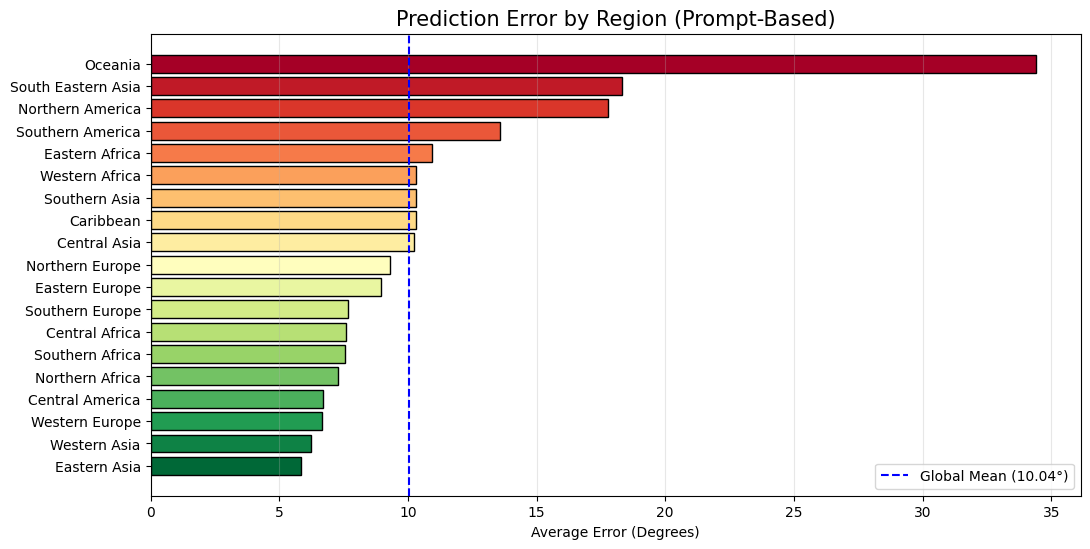

In [11]:
# ============================================================
# EKSPERIMEN KONTROL — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("EKSPERIMEN KONTROL — ANALISIS AKURASI REGIONAL")
print("=" * 65)

regional_stats = []

# Grouping berdasarkan df_results yang baru saja kamu buat
for region, group in df_results.groupby("Region"):
    n_samples = len(group)

    # MAE per region
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    gc_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                   group["Pred_Lat"], group["Pred_Lon"])
    avg_err_reg = gc_err_reg.mean()
    std_err_reg = gc_err_reg.std()  # TAMBAHAN: standar deviasi galat great-circle per wilayah

    # R^2 per region (minimal 2 sampel)
    if n_samples > 1:
        r2_lat_reg = r2_score(group["Actual_Lat"], group["Pred_Lat"])
    else:
        r2_lat_reg = np.nan

    regional_stats.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "Std_Error_Deg": round(std_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2),
    })

df_stats = pd.DataFrame(regional_stats).sort_values("Avg_Error_Deg")
df_plot = df_stats.sort_values("Avg_Error_Deg", ascending=True)

print(df_stats.to_string(index=False))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_plot))) # Hijau ke Merah

# Plotting Bar Chart Error per Region
plt.figure(figsize=(12, 6))
df_plot = df_stats.sort_values("Avg_Error_Deg", ascending=True)
plt.barh(df_plot["Region"], df_plot["Avg_Error_Deg"], color=colors, edgecolor='black')
plt.axvline(avg_global_error, color='blue', linestyle='--', label=f'Global Mean ({avg_global_error:.2f}°)')
plt.title("Prediction Error by Region (Prompt-Based)", fontsize=15)
plt.xlabel("Average Error (Degrees)")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [12]:
# ============================================================
# EKSPERIMEN KONTROL — Visualisasi Peta Per-Wilayah (Auto-Zoom)
# ============================================================

import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("=" * 65)
print("EKSPERIMEN KONTROL — VISUALISASI PETA PER-WILAYAH")
print("Generating and saving detailed maps for each region...")
print("=" * 65)

# 1. Dapatkan daftar region unik
unique_regions = sorted(df_results['Region'].unique())

# 2. Gunakan palette warna yang sama dengan peta global sebelumnya
# (Pastikan variabel region_colors dari cell sebelumnya sudah ada)

for region in unique_regions:
    # Filter data khusus region ini
    reg_data = df_results[df_results['Region'] == region].copy()

    if len(reg_data) < 1:
        continue

    # 3. Hitung Error Spesifik Region
    mae_lat_reg = mean_absolute_error(reg_data["Actual_Lat"], reg_data["Pred_Lat"])

    delta_lon = (reg_data["Actual_Lon"], reg_data["Pred_Lon"])
    # Koreksi kecil untuk perhitungan MAE longitude agar aman dari antimeridian
    delta_lon_val = (reg_data["Actual_Lon"] - reg_data["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon_val, 360 - delta_lon_val).mean()

    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                    reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    # 4. Setup Plot Side-by-Side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Judul Per Region
    plt.suptitle(f"REGION ANALYSIS: {region.upper()}\n"
                 f"Avg Error: {avg_err_reg:.2f}° | Sample: {len(reg_data)} Countries",
                 fontsize=22, fontweight='bold', y=1.05)

    # 5. Tentukan Batas Zoom Otomatis (Auto-Zoom Logic)
    # Kita ambil batas dari koordinat asli dan prediksi, lalu beri padding 5-10 derajat
    all_lons = pd.concat([reg_data["Actual_Lon"], reg_data["Pred_Lon"]])
    all_lats = pd.concat([reg_data["Actual_Lat"], reg_data["Pred_Lat"]])

    pad = 8 # Padding derajat agar peta tidak terlalu mepet ke pinggir
    lon_min, lon_max = all_lons.min() - pad, all_lons.max() + pad
    lat_min, lat_max = all_lats.min() - pad, all_lats.max() + pad

    # 6. Plotting Actual vs Predicted
    for ax, mode, title, color_map_key in zip(
        [ax1, ax2],
        ["Actual", "Pred"],
        [f"Ground Truth ({region})", f"LLM Internal Concept ({region})"],
        ["Actual", "Predicted"]
    ):
        # Gambar background peta dunia
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=1, color='gray', alpha=0.4, zorder=1)
            world.plot(ax=ax, color='#fdfdfd', zorder=0)

        # Plot titik negara
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        # Gunakan warna spesifik region dari map global
        current_color = region_colors.get(region, "dodgerblue")

        ax.scatter(lons, lats, color=current_color, edgecolor='black',
                   s=100, alpha=0.9, zorder=5)

        # Beri label SEMUA negara (karena level region, ruangnya cukup luas)
        for i, row in reg_data.reset_index().iterrows():
            tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
            ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
            ax.annotate(row['Country'], (tx, ty), fontsize=11, fontweight='bold',
                        xytext=(5, 5), textcoords='offset points',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

        ax.set_title(title, fontsize=16, fontweight='semibold')
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_facecolor('#f0f8ff') # Warna air laut tipis

    plt.tight_layout()

    # Menyimpan file gambar secara otomatis ke direktori /content
    filename = f"control_map_{region.replace(' ', '_').lower()}.png"
    filepath = os.path.join('/content', filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved map to: {filepath}")

    plt.show()
    plt.close()

Output hidden; open in https://colab.research.google.com to view.

EKSPERIMEN A — EKSTRAKSI PURE EMBEDDING DAN CLUSTERING
Data ditemukan di Drive! Memuat /content/drive/MyDrive/Percobaan TA/Food KB/Data/croissantLLM_pure_food_cache.pkl...
Berhasil memuat 2414 data ringan (Layer Terakhir).
⏳ Mengelompokkan seluruh makanan ke dalam kategori region...
Berhasil mencocokkan 2414 makanan untuk visualisasi.
⏳ Menghitung t-SNE...


/tmp/ipykernel_745/501627210.py:124: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(main_regions))


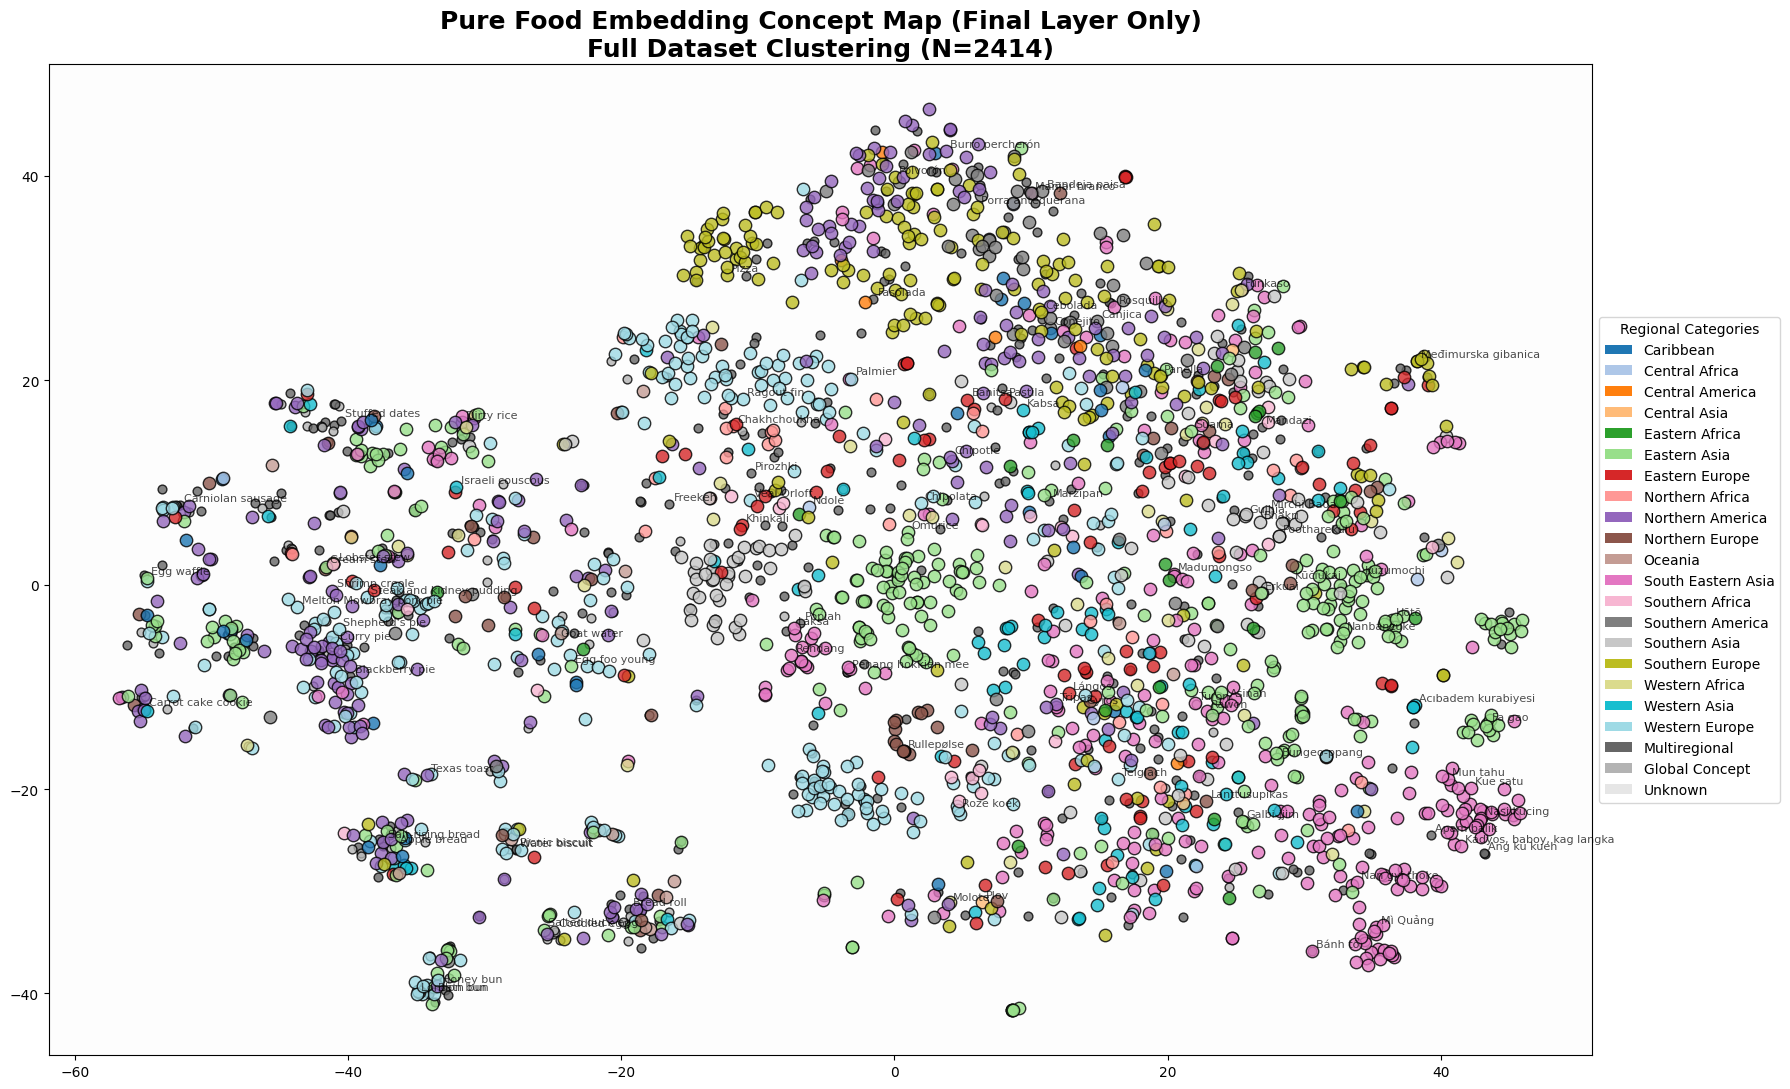

In [13]:
# ============================================================
# EKSPERIMEN A — Ekstraksi Pure Embedding dan Clustering
# Representasi diambil dari hidden state nama makanan SAJA,
# tanpa konteks kalimat/nama negara (lihat Bab III.2.1).
# ============================================================

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
import pickle

print("=" * 65)
print("EKSPERIMEN A — EKSTRAKSI PURE EMBEDDING DAN CLUSTERING")
print("=" * 65)

# 1. Persiapan data
pure_food_cache = {}
all_foods_to_process = food_names

# --- LOGIKA AUTO-LOAD ---
if os.path.exists(FOOD_FILE):
    print(f"Data ditemukan di Drive! Memuat {FOOD_FILE}...")
    with open(FOOD_FILE, 'rb') as f:
        pure_food_cache = pickle.load(f)

    # VALIDASI: Jika data kosong atau format lama (3D/Semua Layer), kita reset.
    reset_needed = False
    if len(pure_food_cache) == 0:
        reset_needed = True
    else:
        sample_val = list(pure_food_cache.values())[0]
        # Jika dimensi > 1, berarti ini data lama (semua layer), kita hapus supaya hemat tempat
        if sample_val.ndim > 1:
            print("Format lama (semua layer) terdeteksi. Reset ke format ringan (layer terakhir)...")
            reset_needed = True
        # Jika kunci ternyata nama negara, bukan nama makanan
        elif list(pure_food_cache.keys())[0] in countries:
            print("Isi file salah (data negara). Reset...")
            reset_needed = True

    if reset_needed:
        os.remove(FOOD_FILE)
        RUN_FOOD_INF = True
        pure_food_cache = {}
    else:
        print(f"Berhasil memuat {len(pure_food_cache)} data ringan (Layer Terakhir).")
        RUN_FOOD_INF = False
else:
    print(f"⏳ Data tidak ditemukan. Mengekstrak pure embedding untuk {len(all_foods_to_process)} makanan...")
    RUN_FOOD_INF = True

# Proses ekstraksi (Hanya Layer Terakhir)
if RUN_FOOD_INF:
    for i, food in enumerate(all_foods_to_process):
        if (i+1) % 200 == 0:
            print(f"  [{i+1}/{len(all_foods_to_process)}] Processing...")

        # Ambil hidden states
        hs = safe_forward(model, tokenizer, food)

        # HANYA AMBIL LAYER TERAKHIR (hs[-1]) untuk efisiensi file
        # Dimensi: (Dimensi_Hidden,) misal (3072,)
        last_layer = hs[-1].detach().cpu().numpy().squeeze(0)
        pure_food_cache[food] = last_layer

    # Simpan ke Drive
    with open(FOOD_FILE, 'wb') as f:
        pickle.dump(pure_food_cache, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"HASIL RINGAN DISIMPAN KE: {FOOD_FILE} (Size: ~2MB)")

# 2. Mapping Skala Penuh dengan Normalisasi
food_to_region = {}
valid_foods = []
normalized_cache = {str(k).strip(): v for k, v in pure_food_cache.items()}

print("⏳ Mengelompokkan seluruh makanan ke dalam kategori region...")

for _, row in food_kb_df.iterrows():
    f_name = str(row['name']).strip()
    if f_name not in normalized_cache: continue

    c_list = _safe_parse_all(row['countries'])
    regions_found = []
    is_global_only = False

    if not c_list:
        final_label = "Unknown"
    else:
        for c in c_list:
            if str(c).lower() == "global": is_global_only = True
            else: regions_found.append(get_country_region(c))

        unique_regions = list(set(regions_found))
        if len(unique_regions) == 1: final_label = unique_regions[0]
        elif len(unique_regions) > 1: final_label = "Multiregional"
        elif is_global_only: final_label = "Global Concept"
        else: final_label = "Unknown"

    food_to_region[f_name] = final_label
    valid_foods.append(f_name)

print(f"Berhasil mencocokkan {len(valid_foods)} makanan untuk visualisasi.")

# 3. Visualisasi t-SNE
if len(valid_foods) > 1:
    # Karena cache sekarang sudah 1 layer saja, tidak perlu [TARGET_LAYER]
    X_pure = np.array([normalized_cache[f] for f in valid_foods])
    X_pure = X_pure - np.mean(X_pure, axis=0)

    print(f"⏳ Menghitung t-SNE...")
    perp_val = max(1, min(30, len(valid_foods) - 1))
    tsne_pure = TSNE(n_components=2, perplexity=perp_val, random_state=42)
    X_embedded_pure = tsne_pure.fit_transform(X_pure)

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(18, 11))
    all_labels = sorted(list(set(food_to_region.values())))
    special_labels = ["Multiregional", "Global Concept", "Unknown"]
    main_regions = [l for l in all_labels if l not in special_labels]

    # Palet warna
    cmap = plt.cm.get_cmap('tab20', len(main_regions))
    color_map = {reg: cmap(i) for i, reg in enumerate(main_regions)}
    color_map["Multiregional"] = (0.4, 0.4, 0.4)
    color_map["Global Concept"] = (0.7, 0.7, 0.7)
    color_map["Unknown"] = (0.9, 0.9, 0.9)

    for i, food in enumerate(valid_foods):
        reg = food_to_region[food]
        color = color_map.get(reg, (0.5, 0.5, 0.5))

        ax.scatter(X_embedded_pure[i, 0], X_embedded_pure[i, 1],
                   c=[color],
                   s=80 if reg not in special_labels else 40,
                   edgecolors='black', alpha=0.8,
                   zorder=2 if reg not in special_labels else 1)

        if i % 25 == 0: # Label setiap 25 makanan agar tidak terlalu berantakan
            ax.annotate(food, (X_embedded_pure[i, 0], X_embedded_pure[i, 1]),
                        fontsize=8, alpha=0.7, xytext=(3,3), textcoords='offset points')

    legend_elements = [Patch(facecolor=color_map[reg], label=reg) for reg in main_regions + special_labels]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Regional Categories")

    ax.set_title(f"Pure Food Embedding Concept Map (Final Layer Only)\nFull Dataset Clustering (N={len(valid_foods)})",
                 fontsize=18, fontweight='bold')
    ax.set_facecolor('#fdfdfd')
    plt.tight_layout()
    plt.show()
else:
    print("Gagal mencocokkan data. Pastikan kolom 'name' di CSV sesuai dengan yang di-inference.")

EKSPERIMEN A — PROBING LINEAR (INKLUSIF, AGREGAT-NEGARA)
Logika: Makanan Multiregional berkontribusi ke semua negara asalnya
⏳ Mengumpulkan daftar makanan per negara...
⏳ Menghitung rata-rata embedding per negara (Threshold: 5)...
Data siap: 151 negara dianalisis.

 HASIL EVALUASI (PURE EMBEDDING):
Average Global Error: 16.84 derajat (SD: 18.98°, n=151)
Latitude R²: 0.486
Longitude R²: 0.834


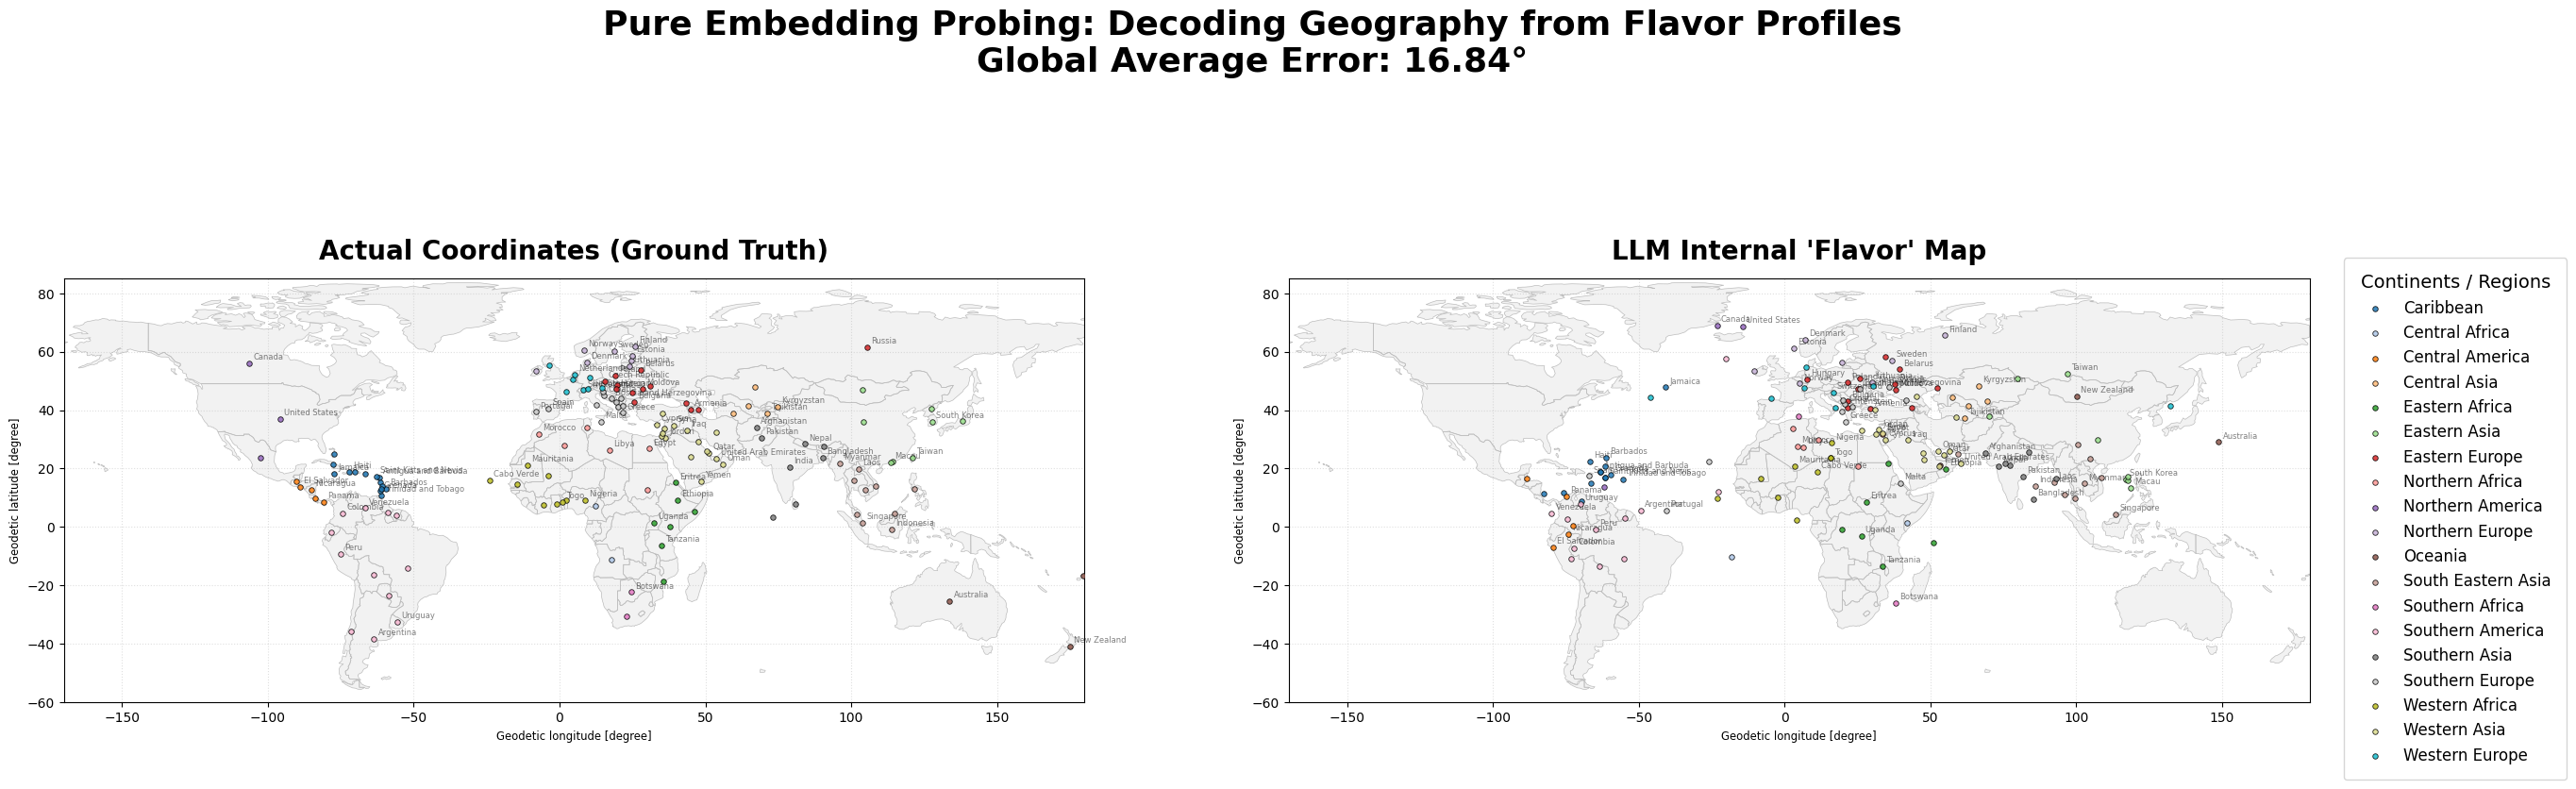

Visualisasi Pure Embedding Probing selesai.


In [14]:
# ============================================================
# EKSPERIMEN A — Probing Linear (Inklusif, Agregat-Negara)
# Menjawab RQ1 untuk jalur analisis utama (pure embedding).
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import geopandas as gpd

print("=" * 65)
print("EKSPERIMEN A — PROBING LINEAR (INKLUSIF, AGREGAT-NEGARA)")
print("Logika: Makanan Multiregional berkontribusi ke semua negara asalnya")
print("=" * 65)

TARGET_LAYER = num_layers - 1

# --- KONFIGURASI ---
MIN_FOODS_THRESHOLD = 5
# -------------------

# 1. Mapping Makanan ke SEMUA Negara Asalnya
print(f"⏳ Mengumpulkan daftar makanan per negara...")
country_to_foods_map = {}

for _, row in food_kb_df.iterrows():
    f_name = row['name']
    if f_name not in pure_food_cache: continue

    # Parser ini sudah menangani UK, Korea split, dll.
    c_list = _safe_parse_all(row['countries'])

    for country in c_list:
        # Kita abaikan label "Global" untuk urusan koordinat geografis
        if country.lower() == "global": continue

        if country not in country_to_foods_map:
            country_to_foods_map[country] = []

        # Rendang akan dimasukkan ke list Indonesia DAN list Malaysia
        country_to_foods_map[country].append(f_name)

# 2. Hitung Rata-rata Embedding (Citra Rasa Negara)
print(f"⏳ Menghitung rata-rata embedding per negara (Threshold: {MIN_FOODS_THRESHOLD})...")
pure_country_repr = {}
valid_pure_countries = []

for country, foods in country_to_foods_map.items():
    # Hanya proses negara yang punya data koordinat dan jumlah makanan cukup
    if country in country_coords and len(foods) >= MIN_FOODS_THRESHOLD:
        # Ambil embedding untuk semua makanan milik negara tersebut
        embs = [pure_food_cache[f] for f in foods]

        # Rata-rata vektor (ini adalah 'titik pusat' rasa negara tersebut di ruang embedding)
        pure_country_repr[country] = np.mean(embs, axis=0)
        valid_pure_countries.append(country)

# 3. Siapkan Matriks untuk Linear Probing
X_pure_list = []
y_lat_pure = []
y_lon_pure = []

for c in valid_pure_countries:
    X_pure_list.append(pure_country_repr[c])
    y_lat_pure.append(country_coords[c]['lat'])
    y_lon_pure.append(country_coords[c]['lon'])

X_pure = np.array(X_pure_list)
y_lat_pure = np.array(y_lat_pure)
y_lon_pure = np.array(y_lon_pure)

print(f"Data siap: {len(valid_pure_countries)} negara dianalisis.")

# 4. Train & Evaluate (5-Fold CV)
if len(valid_pure_countries) >= 5:
    # FIX: RidgeCV, konsisten dengan kebijakan regularisasi eksperimen lain.
    probe_model_pure = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                          scoring='neg_mean_absolute_error'))
    ])

    cv_pure = KFold(n_splits=5, shuffle=True, random_state=42)

    y_xyz_pure = latlon_to_xyz(y_lat_pure, y_lon_pure)
    pred_xyz_pure = cross_val_predict(probe_model_pure, X_pure, y_xyz_pure, cv=cv_pure)
    pred_lat_pure, pred_lon_pure = xyz_to_latlon(pred_xyz_pure)
    gc_errors_pure = great_circle_deg(y_lat_pure, y_lon_pure, pred_lat_pure, pred_lon_pure)
    avg_err_pure = gc_errors_pure.mean()
    std_err_pure = gc_errors_pure.std()  # TAMBAHAN: standar deviasi galat great-circle

    print("\n HASIL EVALUASI (PURE EMBEDDING):")
    print(f"Average Global Error: {avg_err_pure:.2f} derajat (SD: {std_err_pure:.2f}°, n={len(gc_errors_pure)})")
    print(f"Latitude R²: {r2_score(y_lat_pure, pred_lat_pure):.3f}")
    print(f"Longitude R²: {r2_score(y_lon_pure, pred_lon_pure):.3f}")

    # 6. Simpan df_results_pure untuk analisa regional nanti jika butuh
    df_results_pure = pd.DataFrame({
        "Country": valid_pure_countries,
        "Region": [get_country_region(c) for c in valid_pure_countries],
        "Actual_Lat": y_lat_pure, "Actual_Lon": y_lon_pure,
        "Pred_Lat": pred_lat_pure, "Pred_Lon": pred_lon_pure
    })

# 5. Visualisasi Hasil Prediksi (PETA MAKSIMAL - LEGENDA VERTIKAL)
    import matplotlib as mpl

    # Setup Palette Warna berdasarkan Region
    unique_regions_pure = sorted(df_results_pure['Region'].unique())
    cmap = mpl.colormaps.get_cmap('tab20')
    region_colors_pure = {reg: cmap(i % 20) for i, reg in enumerate(unique_regions_pure)}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 12))

    plt.suptitle(f"Pure Embedding Probing: Decoding Geography from Flavor Profiles\nGlobal Average Error: {avg_err_pure:.2f}°",
                 fontsize=26, fontweight='bold', y=0.95)

    for ax, mode, title in zip([ax1, ax2], ["Actual", "Pred"],
                                ["Actual Coordinates (Ground Truth)", "LLM Internal 'Flavor' Map"]):
        # Gambar Background Peta
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
            world.plot(ax=ax, color='#f2f2f2', zorder=0)

        # Plot per region
        for reg in unique_regions_pure:
            reg_data = df_results_pure[df_results_pure['Region'] == reg]
            lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
            lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

            ax.scatter(lons, lats, color=region_colors_pure[reg], edgecolor='black',
                       linewidth=0.6, s=16, alpha=0.85, label=reg, zorder=5)

        ax.set_title(title, fontsize=20, pad=15, fontweight='semibold')

        # Zoom ke area yang relevan (menghilangkan kutub kosong)
        ax.set_xlim(-170, 180)
        ax.set_ylim(-60, 85)
        ax.grid(True, linestyle=':', alpha=0.4)

        # Label Negara (Sampling biar tidak numpuk)
        for i, row in df_results_pure.reset_index().iterrows():
            if i % 2 == 0: # Tampilkan tiap 2 negara
                tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
                ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
                ax.annotate(row['Country'], (tx, ty), fontsize=6, alpha=0.5,
                            xytext=(3,3), textcoords='offset points')

    # 6. Buat Legenda Vertikal di Sisi Kanan
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5),
                     fontsize=12, title="Continents / Regions", title_fontsize=14,
                     frameon=True, borderpad=1)

    # Atur tata letak
    plt.subplots_adjust(left=0.05, right=0.90, top=0.95, bottom=0.1)

    # Simpan untuk TA
    plt.savefig("pure_embedding_geography.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Visualisasi Pure Embedding Probing selesai.")
else:
    print("Data tidak mencukupi untuk melakukan probing.")


EKSPERIMEN A — ANALISIS AKURASI REGIONAL
Melihat seberapa akurat 'Citra Rasa' per wilayah
            Region  Count  Avg_Error_Deg  Std_Error_Deg  MAE_Lat  MAE_Lon
      Western Asia     16           5.72           2.00     3.57     4.39
      Central Asia      5           6.86           3.22     3.32     7.81
   Northern Africa      6           7.59           2.67     4.60     5.60
   Northern Europe      8           8.10           4.30     4.38    11.04
    Eastern Europe     13           9.00           9.27     3.52    12.19
         Caribbean     14           9.84          10.06     6.95     6.57
     Southern Asia      8          13.76           6.20    10.30     8.61
    Eastern Africa      7          14.77           6.13     9.85    10.49
    Western Africa      9          15.82           8.63     8.73    11.52
   Central America      5          15.87           8.11    12.03     9.78
South Eastern Asia     10          17.36          16.73     7.95    14.64
   Southern Europe   

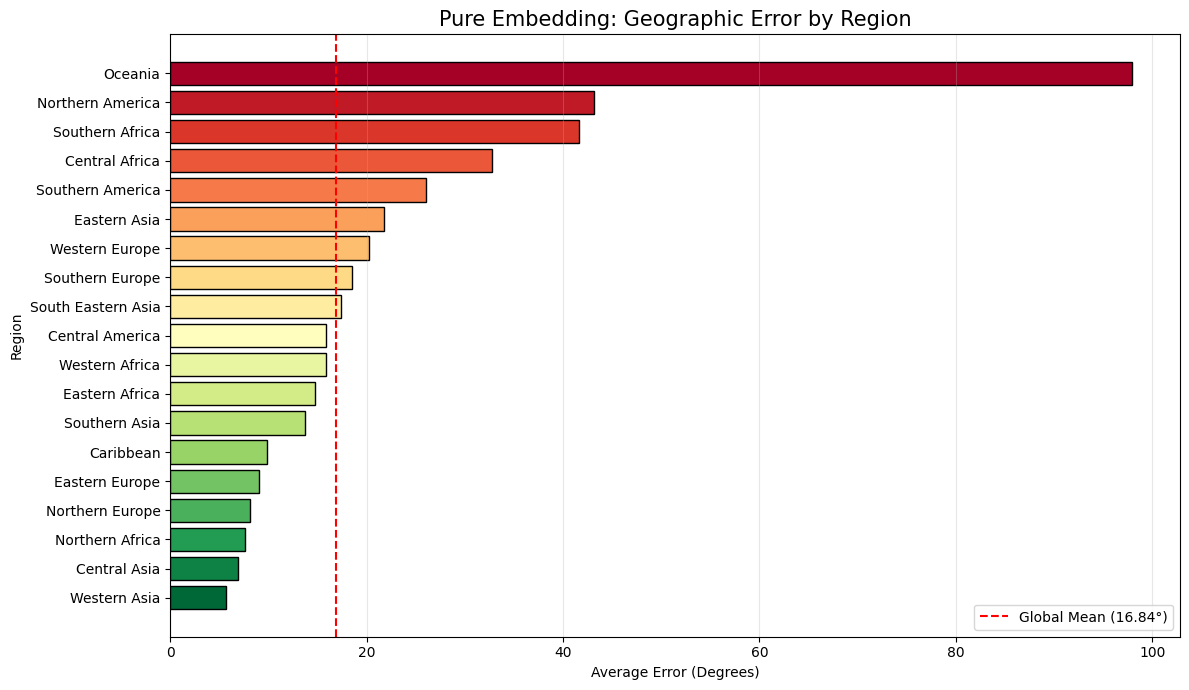

In [15]:
# ============================================================
# EKSPERIMEN A — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("EKSPERIMEN A — ANALISIS AKURASI REGIONAL")
print("Melihat seberapa akurat 'Citra Rasa' per wilayah")
print("=" * 65)

regional_stats_pure = []

# Gunakan df_results_pure yang baru saja kita buat di Cell 4.5
for region, group in df_results_pure.groupby("Region"):
    n_samples = len(group)

    # Hitung MAE
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    gc_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                   group["Pred_Lat"], group["Pred_Lon"])
    avg_err_reg = gc_err_reg.mean()
    std_err_reg = gc_err_reg.std()  # TAMBAHAN: standar deviasi galat great-circle per wilayah

    # Hitung R^2 jika sampel cukup
    if n_samples > 1:
        r2_lat = r2_score(group["Actual_Lat"], group["Pred_Lat"])
        r2_lon = r2_score(group["Actual_Lon"], group["Pred_Lon"])
    else:
        r2_lat, r2_lon = np.nan, np.nan

    regional_stats_pure.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "Std_Error_Deg": round(std_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2),
    })

# Tampilkan Tabel
df_stats_pure = pd.DataFrame(regional_stats_pure).sort_values("Avg_Error_Deg")
print(df_stats_pure.to_string(index=False))

# Visualisasi Perbandingan Error per Region
plt.figure(figsize=(12, 7))
df_plot_pure = df_stats_pure.sort_values("Avg_Error_Deg", ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_plot_pure))) # Hijau ke Merah

plt.barh(df_plot_pure["Region"], df_plot_pure["Avg_Error_Deg"], color=colors, edgecolor='black')
plt.axvline(avg_err_pure, color='red', linestyle='--', label=f'Global Mean ({avg_err_pure:.2f}°)')

plt.title("Pure Embedding: Geographic Error by Region", fontsize=15)
plt.xlabel("Average Error (Degrees)")
plt.ylabel("Region")
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# EKSPERIMEN A — Visualisasi Peta Per-Wilayah
# ============================================================

print("\n⏳ Menghasilkan plot peta regional untuk Pure Embeddings...")

# Pastikan menggunakan df_results_pure dari eksperimen 4.5
unique_regions_pure = sorted(df_results_pure['Region'].unique())

for region in unique_regions_pure:
    reg_data = df_results_pure[df_results_pure['Region'] == region].copy()

    # Kita butuh minimal 1 negara untuk diplot
    if len(reg_data) < 1: continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

    # Hitung error lokal untuk region ini
    mae_lat_reg = mean_absolute_error(reg_data["Actual_Lat"], reg_data["Pred_Lat"])

    delta_lon = (reg_data["Actual_Lon"] - reg_data["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                    reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    plt.suptitle(f"REGION DEEP-DIVE: {region.upper()} (PURE EMBEDDING)\n"
                 f"Avg Error: {avg_err_reg:.2f}° | Sample: {len(reg_data)} Countries",
                 fontsize=24, fontweight='bold', y=1.05)

    # Auto-Zoom Logic: Ambil batas dari koordinat asli DAN prediksi
    all_lons = pd.concat([reg_data["Actual_Lon"], reg_data["Pred_Lon"]])
    all_lats = pd.concat([reg_data["Actual_Lat"], reg_data["Pred_Lat"]])

    padding = 8 # Derajat ruang kosong di sekitar titik
    lon_min, lon_max = all_lons.min() - padding, all_lons.max() + padding
    lat_min, lat_max = all_lats.min() - padding, all_lats.max() + padding

    for ax, mode, title, dot_color in zip(
        [ax1, ax2],
        ["Actual", "Pred"],
        [f"Actual Coordinates ({region})", f"LLM Internal 'Flavor' Map"],
        ["#1e90ff", "#ff4757"] # Biru Cerah vs Merah Solid
    ):
        # 1. WARNAI LAUT (Background axis)
        ax.set_facecolor('#d1eefc')

        # 2. GAMBAR DARATAN
        if world is not None:
            # Garis pantai
            world.boundary.plot(ax=ax, linewidth=1, color='#7f8c8d', alpha=0.6, zorder=2)
            # Isi daratan (Putih bersih agar titik menonjol)
            world.plot(ax=ax, color='#fdfdfd', zorder=1)

        # 3. PLOT TITIK NEGARA
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        ax.scatter(lons, lats, c=dot_color, edgecolor='black',
                   linewidth=1.2, s=100, alpha=0.9, zorder=5)

        # 4. LABEL NEGARA DENGAN BACKGROUND (Agar terbaca di atas garis pantai)
        for i, row in reg_data.reset_index().iterrows():
            tx = lons.iloc[i]
            ty = lats.iloc[i]
            ax.annotate(row['Country'], (tx, ty),
                        fontsize=11, fontweight='bold',
                        xytext=(6, 6), textcoords='offset points',
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1),
                        zorder=6)

        ax.set_title(title, fontsize=18, fontweight='semibold', pad=10)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle=':', alpha=0.5, color='white', zorder=3)

    plt.tight_layout()

    # Simpan file
    filename = f"pure_probing_{region.replace(' ', '_').lower()}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Plot regional untuk {region} berhasil dibuat (Warna Laut: Biru).")

Output hidden; open in https://colab.research.google.com to view.


BASELINE EKSKLUSIF — PROBING LINEAR (HANYA MAKANAN 1-NEGARA)
Logika: Hanya menggunakan makanan yang memiliki 1 negara eksklusif
HASIL BASELINE (EXCLUSIVE ONLY):
Negara yang memenuhi syarat (min 1 makanan unik): 117
Average Global Error (Unique): 33.20 derajat
Latitude R² Score: -0.082
Longitude R² Score: 0.417

 ANALISIS PERBANDINGAN:
Error Inclusive (Exp 4.5): 16.84°
Error Exclusive (Exp 4.7): 33.20°
Hasil: Error naik sebesar 16.36° saat menggunakan hanya makanan unik.


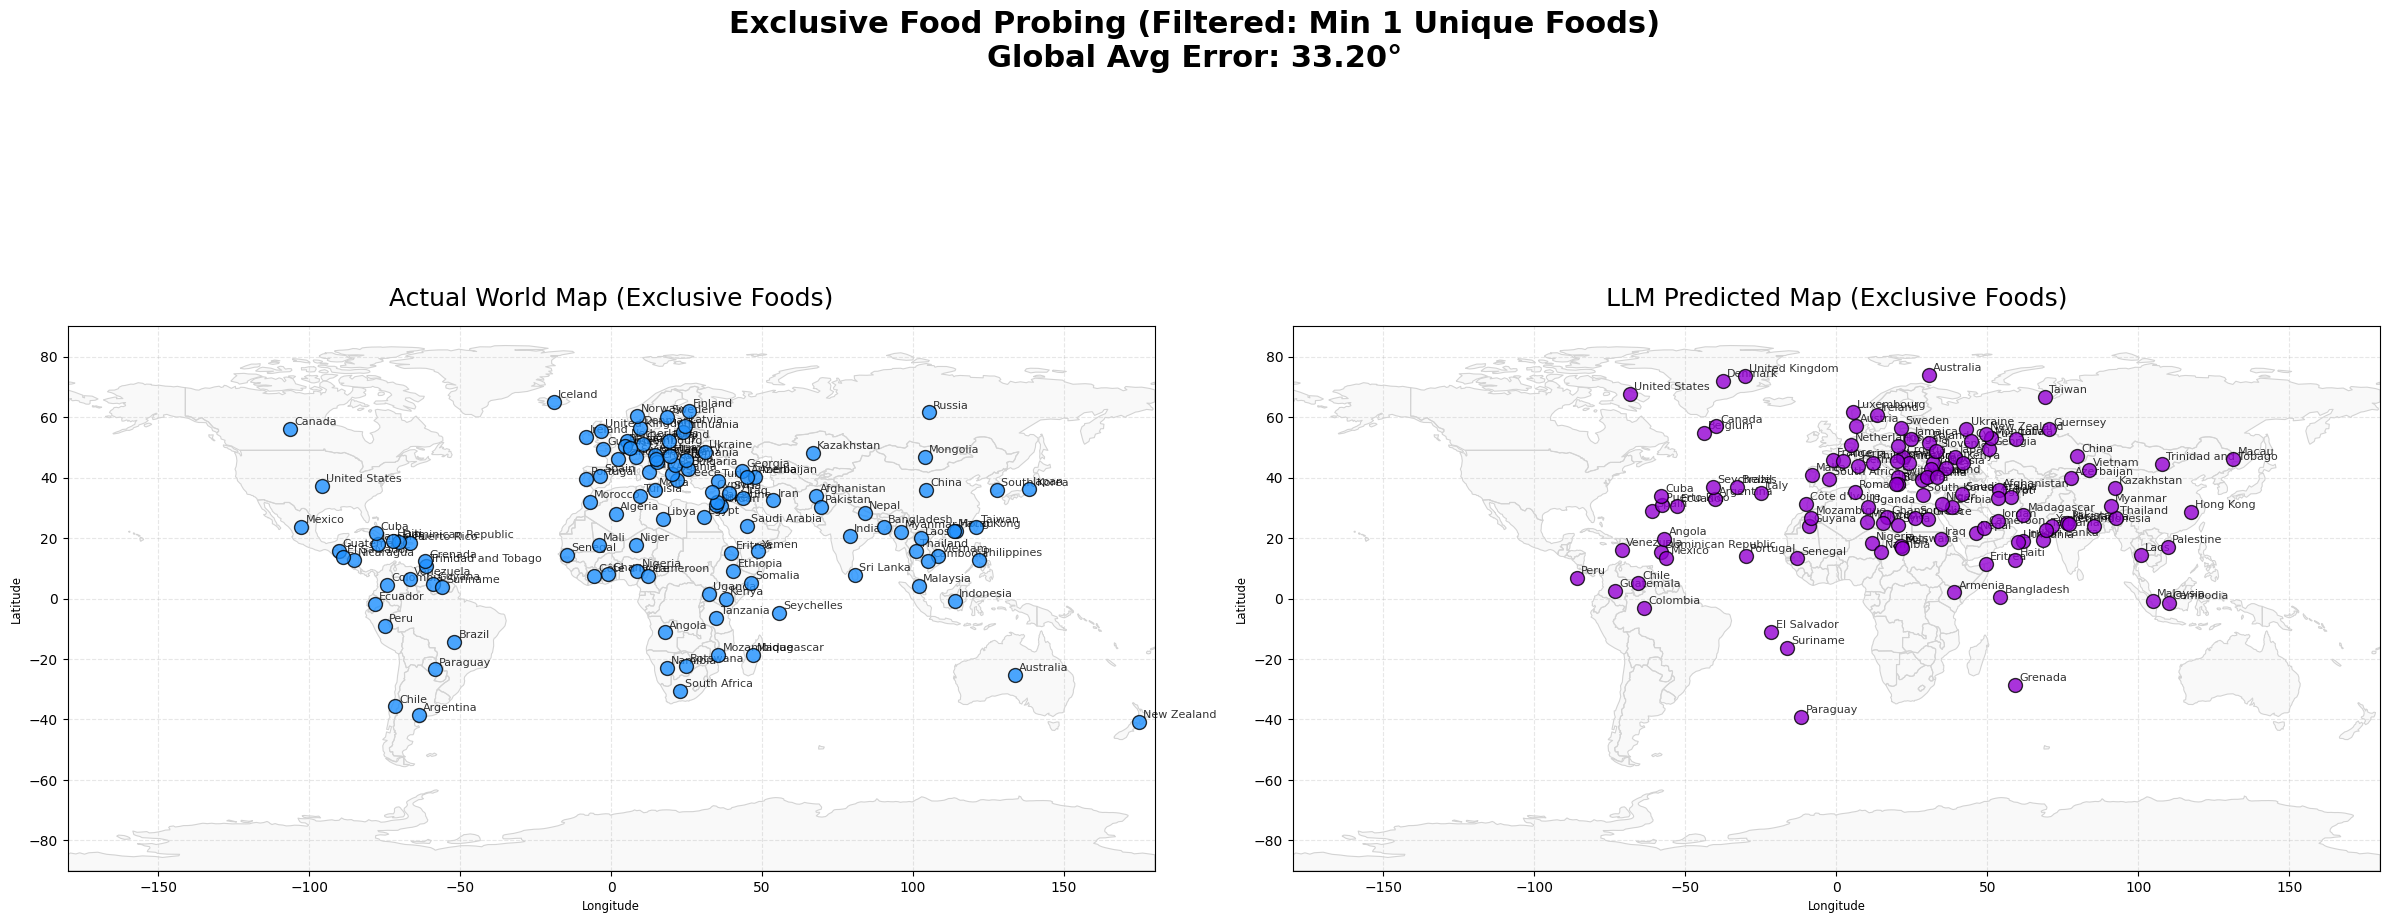

Baseline Dataframe created for 117 exclusive countries.


In [17]:
# ============================================================
# BASELINE EKSKLUSIF — Probing Linear (Hanya Makanan 1-Negara)
# Tujuan: bandingkan hasil inklusif (Eksperimen A) dengan
# baseline yang hanya memakai makanan tanpa klaim ganda negara.
# ============================================================

print("\n" + "="*65)
print("BASELINE EKSKLUSIF — PROBING LINEAR (HANYA MAKANAN 1-NEGARA)")
print("Logika: Hanya menggunakan makanan yang memiliki 1 negara eksklusif")
print("=" * 65)

# 1. Identifikasi Makanan yang Benar-benar Unik (Eksklusif per Negara)
exclusive_country_to_foods = {}

for _, row in food_kb_df.iterrows():
    f_name = row['name']
    if f_name not in pure_food_cache:
        continue

    # Gunakan parser existing untuk mendapatkan list negara (tanpa 'Global')
    c_list = [c for c in _safe_parse_all(row['countries']) if c.lower() != 'global']

    # FILTER: Hanya ambil jika makanan tersebut HANYA milik 1 negara
    if len(c_list) == 1:
        country = c_list[0]
        if country not in exclusive_country_to_foods:
            exclusive_country_to_foods[country] = []
        exclusive_country_to_foods[country].append(f_name)

# 2. Hitung Rata-rata Embedding untuk Baseline Unik
X_unique = []
y_lat_unique = []
y_lon_unique = []
valid_exclusive_countries = []

MIN_UNIQUE_THRESHOLD = 1

for country, foods in exclusive_country_to_foods.items():
    if country in country_coords and len(foods) >= MIN_UNIQUE_THRESHOLD:
        # Hitung mean embedding dari makanan unik
        embs = [pure_food_cache[f] for f in foods]
        X_unique.append(np.mean(embs, axis=0))
        y_lat_unique.append(country_coords[country]['lat'])
        y_lon_unique.append(country_coords[country]['lon'])
        valid_exclusive_countries.append(country)

# 3. Jalankan Linear Probing pada Data Unik
if len(valid_exclusive_countries) >= 5:
    X_u = np.array(X_unique)
    y_lat_u = np.array(y_lat_unique)
    y_lon_u = np.array(y_lon_unique)

    # Reuse pipeline logic dari eksperimen sebelumnya
    # FIX: RidgeCV (bukan alpha=1.0 tetap) dan target sferis + great-circle,
    # konsisten dengan kebijakan Eksperimen A/B/C/D.
    probe_unique = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                          scoring='neg_mean_absolute_error'))
    ])

    cv_u = KFold(n_splits=5, shuffle=True, random_state=42)

    y_xyz_u = latlon_to_xyz(y_lat_u, y_lon_u)
    pred_xyz_u = cross_val_predict(probe_unique, X_u, y_xyz_u, cv=cv_u)
    pred_lat_u, pred_lon_u = xyz_to_latlon(pred_xyz_u)

    avg_err_unique = great_circle_deg(y_lat_u, y_lon_u, pred_lat_u, pred_lon_u).mean()
    r2_u = r2_score(y_lat_u, pred_lat_u)

    # 4. Tampilkan Perbandingan Hasil
    print(f"HASIL BASELINE (EXCLUSIVE ONLY):")
    print(f"Negara yang memenuhi syarat (min {MIN_UNIQUE_THRESHOLD} makanan unik): {len(valid_exclusive_countries)}")
    print(f"Average Global Error (Unique): {avg_err_unique:.2f} derajat")
    print(f"Latitude R² Score: {r2_u:.3f}")
    print(f"Longitude R² Score: {r2_score(y_lon_u, pred_lon_u):.3f}")

    print(f"\n ANALISIS PERBANDINGAN:")
    # Membandingkan dengan avg_err_pure dari Experiment 4.5 yang sudah jalan sebelumnya
    diff = avg_err_unique - avg_err_pure
    print(f"Error Inclusive (Exp 4.5): {avg_err_pure:.2f}°")
    print(f"Error Exclusive (Exp 4.7): {avg_err_unique:.2f}°")

    if diff > 0:
        print(f"Hasil: Error naik sebesar {diff:.2f}° saat menggunakan hanya makanan unik.")
    else:
        print(f"Hasil: Error turun sebesar {abs(diff):.2f}°.")

    # ── 5. Visualisasi Hasil Prediksi (Exclusive Only) ──
    # Menggunakan variabel world yang sudah di-load di cell sebelumnya
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
    plt.suptitle(f"Exclusive Food Probing (Filtered: Min {MIN_UNIQUE_THRESHOLD} Unique Foods)\n"
                 f"Global Avg Error: {avg_err_unique:.2f}°",
                 fontsize=22, fontweight='bold', y=1.05)

    for ax, lons, lats, title, color in zip(
        [ax1, ax2],
        [y_lon_u, pred_lon_u],
        [y_lat_u, pred_lat_u],
        ["Actual World Map (Exclusive Foods)", "LLM Predicted Map (Exclusive Foods)"],
        ["dodgerblue", "darkviolet"] # Warna beda dikit biar gak ketuker sama inclusive
    ):
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=0.8, color='lightgray')
            world.plot(ax=ax, color='whitesmoke', alpha=0.5)

        # Plot titik negara
        ax.scatter(lons, lats, c=color, edgecolor='black', s=100, alpha=0.8, zorder=5)
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

        # Label negara (hanya sampel supaya tidak terlalu penuh)
        for i, c in enumerate(valid_exclusive_countries):
            ax.annotate(c, (lons[i], lats[i]), fontsize=8, xytext=(3, 3),
                            textcoords='offset points', alpha=0.8)

    plt.tight_layout()
    plt.show()

    # ── 6. Simpan Dataframe Baseline (Opsional) ──
    df_results_unique = pd.DataFrame({
        "Country": valid_exclusive_countries,
        "Region": [get_country_region(c) for c in valid_exclusive_countries],
        "Actual_Lat": y_lat_u, "Actual_Lon": y_lon_u,
        "Pred_Lat": pred_lat_u, "Pred_Lon": pred_lon_u
    })
    print(f"Baseline Dataframe created for {len(valid_exclusive_countries)} exclusive countries.")
else:
    print(f"Data unik tidak mencukupi (Hanya ada {len(valid_exclusive_countries)} negara).")
    print("   Saran: Kurangi MIN_UNIQUE_THRESHOLD atau tambahkan data di CSV.")


BASELINE EKSKLUSIF — ANALISIS AKURASI REGIONAL
Melihat wilayah mana yang identitas kulinernya paling 'eksklusif'
            Region  Count  Avg_Error_Deg  MAE_Lat  MAE_Lon
    Western Europe      8          11.91     7.44    12.92
   Northern Africa      5          16.45    10.63    11.83
    Eastern Europe      9          17.60    10.11    17.82
    Western Africa      6          18.85    11.23    13.22
      Western Asia     10          19.47     9.89    16.81
   Southern Europe      9          20.62     9.06    22.00
     Southern Asia      6          21.59     8.38    20.76
      Central Asia      1          21.81    11.47    25.32
   Northern Europe      9          24.79    14.50    31.26
South Eastern Asia      8          27.04    16.10    23.29
  Northern America      3          38.02    13.84    46.63
  Southern America     10          39.16    28.44    23.59
      Eastern Asia      7          41.48    14.66    49.76
    Eastern Africa      9          45.23    32.20    29.58
 

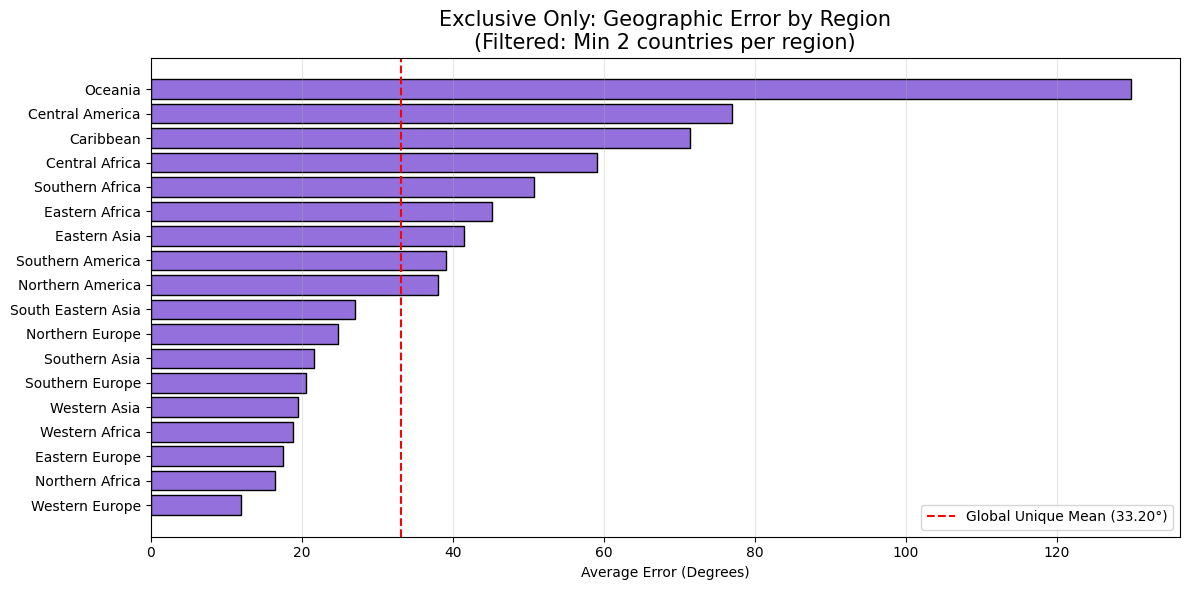

In [18]:
# ============================================================
# BASELINE EKSKLUSIF — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("BASELINE EKSKLUSIF — ANALISIS AKURASI REGIONAL")
print("Melihat wilayah mana yang identitas kulinernya paling 'eksklusif'")
print("=" * 65)

regional_stats_unique = []

# Gunakan df_results_unique dari tahap sebelumnya
for region, group in df_results_unique.groupby("Region"):
    n_samples = len(group)

    # Hitung MAE
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                    group["Pred_Lat"], group["Pred_Lon"]).mean()

    regional_stats_unique.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2)
    })

# Tampilkan Tabel
df_stats_unique = pd.DataFrame(regional_stats_unique).sort_values("Avg_Error_Deg")
print(df_stats_unique.to_string(index=False))

# Visualisasi Bar Chart (Hanya jika ada lebih dari 1 region)
if len(df_stats_unique) > 1:
    plt.figure(figsize=(12, 6))
    # Filter: Hanya tampilkan region yang punya minimal 2 negara agar bar chart tidak bias
    df_plot_u = df_stats_unique[df_stats_unique['Count'] >= 2].sort_values("Avg_Error_Deg")

    plt.barh(df_plot_u["Region"], df_plot_u["Avg_Error_Deg"], color='mediumpurple', edgecolor='black')
    plt.axvline(avg_err_unique, color='red', linestyle='--', label=f'Global Unique Mean ({avg_err_unique:.2f}°)')

    plt.title("Exclusive Only: Geographic Error by Region\n(Filtered: Min 2 countries per region)", fontsize=15)
    plt.xlabel("Average Error (Degrees)")
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

EKSPERIMEN B — PROBING LINEAR (INDIVIDUAL PER MAKANAN)
Data siap: 4872 titik data makanan-negara.
   - Artefak unik: 2333
   - Artefak multi-negara (diklaim >1 negara): 653 (28.0%)
Data siap: 4872 titik data makanan-negara.
⏳ Probing 4872 titik dengan GroupKFold(n=5)...
Latitude R² (Eksperimen B): -0.459
Longitude R² (Eksperimen B): 0.234
   Alpha dipilih RidgeCV: 500.0
HASIL PROBING INDIVIDUAL FOOD:
Average Global Error: 35.50 derajat (SD: 29.26°, n=4872)


/tmp/ipykernel_745/4012860046.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_regs))


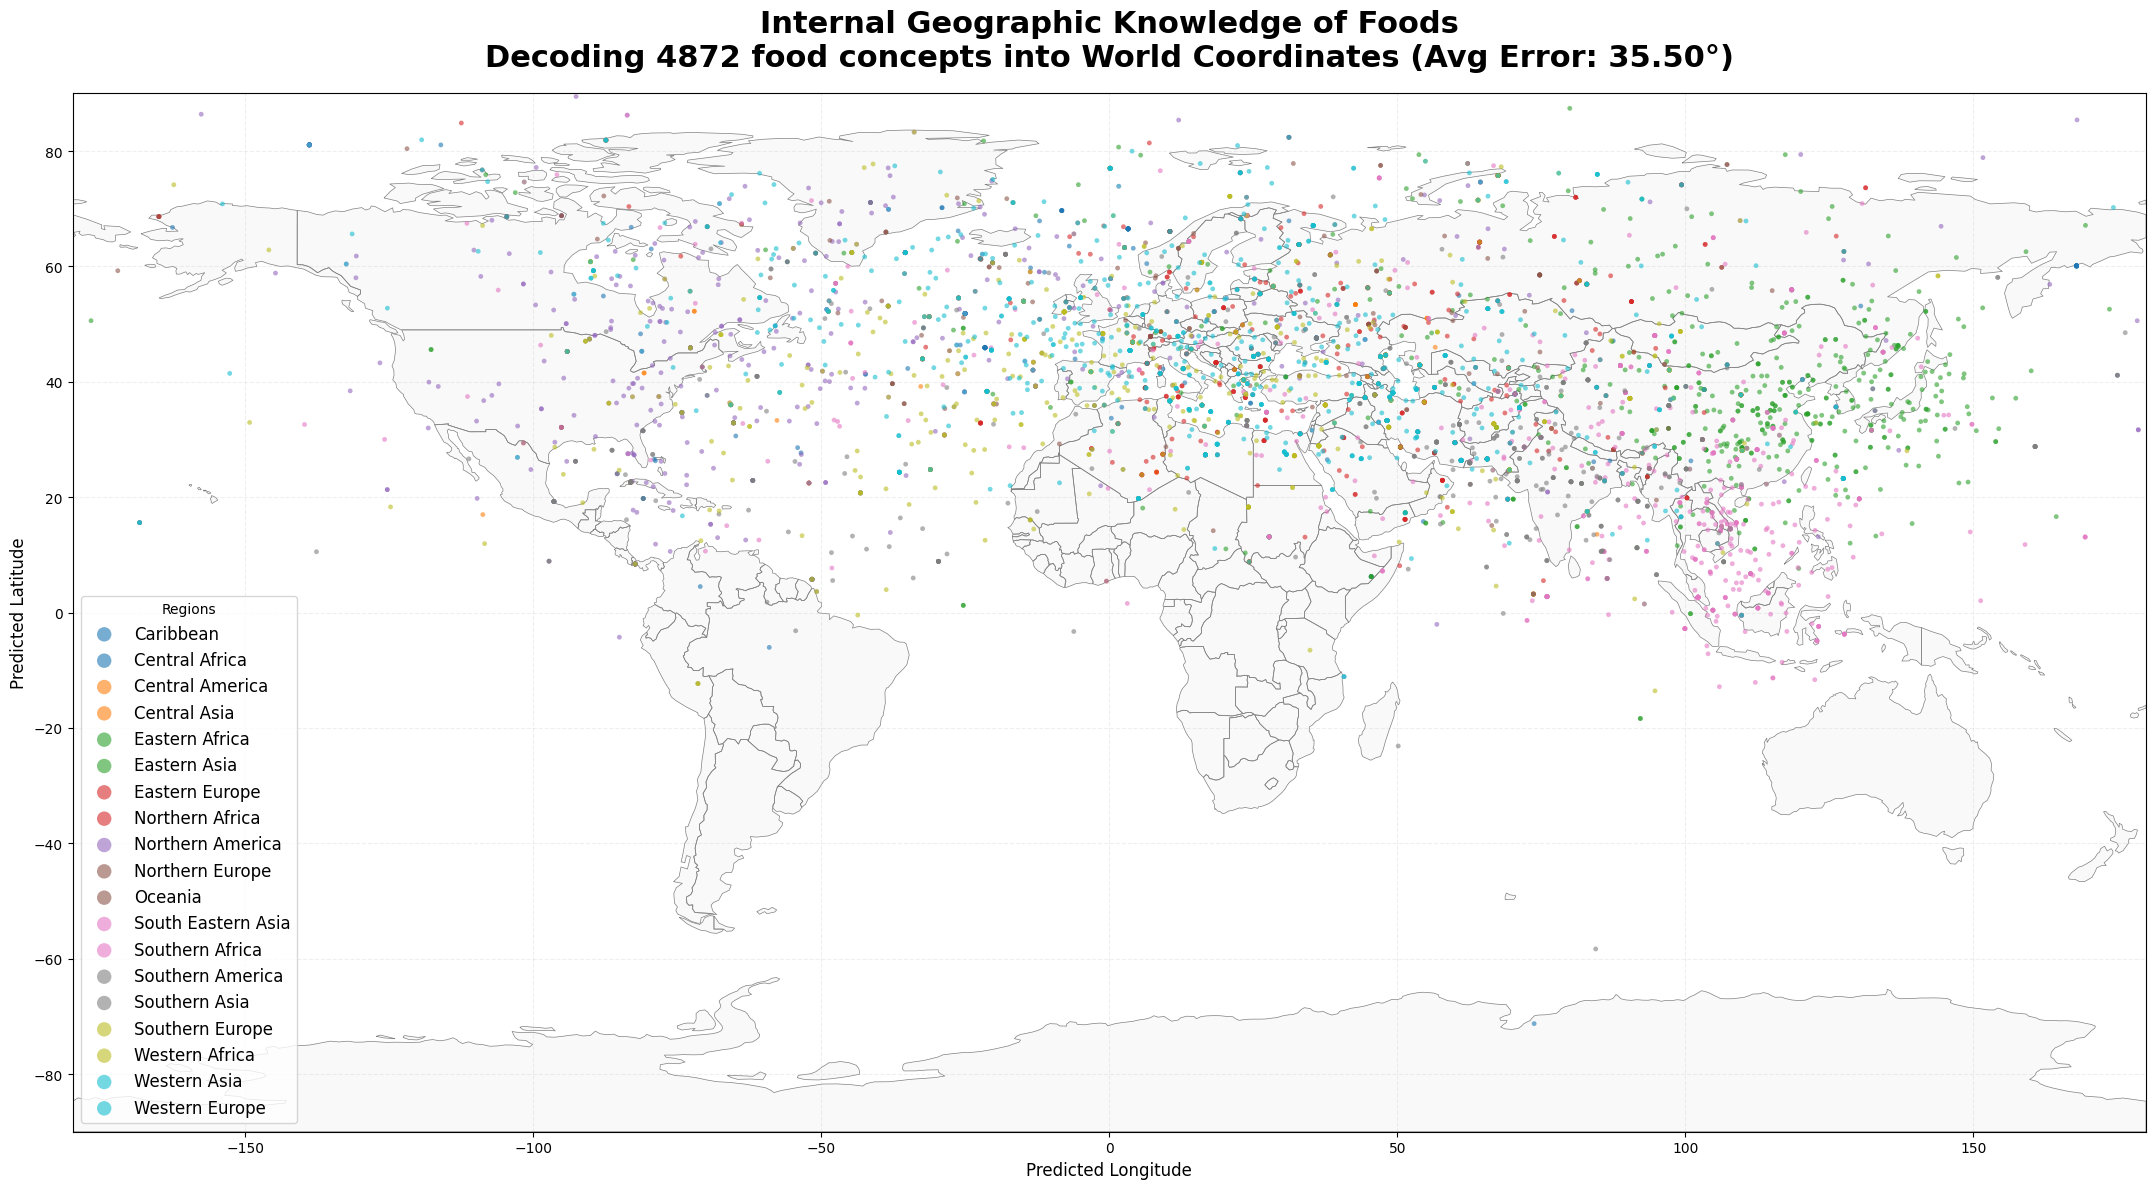

In [19]:
# ============================================================
# EKSPERIMEN B — Probing Linear (Individual per Makanan)
# Unit analisis: satu baris per pasangan makanan-negara,
# dibobot 1/N_negara_pengklaim. GroupKFold berbasis identitas
# makanan untuk mencegah kebocoran data. Basis bagi seluruh
# metrik dekomposisi di Eksperimen C. Menjawab RQ1 dan RQ2.
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

print("=" * 65)
print("EKSPERIMEN B — PROBING LINEAR (INDIVIDUAL PER MAKANAN)")
print("=" * 65)

X_food = []
y_lat_food = []
y_lon_food = []
food_regions = []
food_labels = []
food_weights = []

# 1. Siapkan data pasangan (Vektor Makanan -> Koordinat Negara)
for _, row in food_kb_df.iterrows():
    f_name = str(row['name']).strip()
    if f_name not in normalized_cache: continue

    c_list = _safe_parse_all(row['countries'])
    valid_countries_for_food = [c for c in c_list if c in country_coords]
    if not valid_countries_for_food:
        continue

    weight = 1.0 / len(valid_countries_for_food)  # bobot per baris

    for country in valid_countries_for_food:
        X_food.append(normalized_cache[f_name])
        y_lat_food.append(country_coords[country]['lat'])
        y_lon_food.append(country_coords[country]['lon'])
        food_regions.append(get_country_region(country))
        food_labels.append(f_name)
        food_weights.append(weight)          # <-- list baru, tambahkan di inisialisasi atas

X_f = np.array(X_food)
y_lat_f = np.array(y_lat_food)
y_lon_f = np.array(y_lon_food)
food_groups = np.array(food_labels)          # grup = nama makanan, untuk GroupKFold
food_weights_arr = np.array(food_weights)

# Laporan: berapa % data punya lebih dari 1 negara?
from collections import Counter
name_counts = Counter(food_labels)
multi = sum(1 for v in name_counts.values() if v > 1)
print(f"Data siap: {len(X_f)} titik data makanan-negara.")
print(f"   - Artefak unik: {len(name_counts)}")
print(f"   - Artefak multi-negara (diklaim >1 negara): {multi} "
      f"({100*multi/len(name_counts):.1f}%)")

print(f"Data siap: {len(X_f)} titik data makanan-negara.")

# 2. Linear Probing dengan 5-Fold CV
if len(X_f) > 10:
    # Tune alpha dari rentang yang mencakup nilai lama (150) sebagai kandidat
    probe_food = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                          scoring='neg_mean_absolute_error'))
    ])

    # GroupKFold: n_splits maksimal = jumlah artefak unik, tapi cap di 5
    n_unique_foods = len(np.unique(food_groups))
    n_splits_gkf = min(5, n_unique_foods)
    cv_f = GroupKFold(n_splits=n_splits_gkf)

    print(f"⏳ Probing {len(X_f)} titik dengan GroupKFold(n={n_splits_gkf})...")
    y_xyz_f = latlon_to_xyz(y_lat_f, y_lon_f)
    pred_xyz_f = cross_val_predict(
        probe_food, X_f, y_xyz_f,
        cv=cv_f, groups=food_groups,
        params={'ridge__sample_weight': food_weights_arr}
    )
    pred_lat_f, pred_lon_f = xyz_to_latlon(pred_xyz_f)

    r2_lat_f = r2_score(y_lat_f, pred_lat_f)
    r2_lon_f = r2_score(y_lon_f, pred_lon_f)
    print(f"Latitude R² (Eksperimen B): {r2_lat_f:.3f}")
    print(f"Longitude R² (Eksperimen B): {r2_lon_f:.3f}")

    # simpan per-titik great-circle error untuk dipakai ulang di Eksperimen 6 (Cell 22-25)
    gc_error_f = great_circle_deg(y_lat_f, y_lon_f, pred_lat_f, pred_lon_f)
    avg_err_f = gc_error_f.mean()
    std_err_f = gc_error_f.std()  # TAMBAHAN: standar deviasi galat great-circle

    # Laporan alpha yang dipilih (fit ulang di seluruh data untuk inspeksi)
    probe_food.fit(X_f, y_lat_f,
                   ridge__sample_weight=food_weights_arr)
    chosen_alpha = probe_food.named_steps['ridge'].alpha_
    print(f"   Alpha dipilih RidgeCV: {chosen_alpha}")

    print(f"HASIL PROBING INDIVIDUAL FOOD:")
    print(f"Average Global Error: {avg_err_f:.2f} derajat (SD: {std_err_f:.2f}°, n={len(gc_error_f)})")

    # 3. Visualisasi Peta Dunia (Titik Kecil-kecil)
    fig, ax = plt.subplots(figsize=(24, 12))

    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='gray', zorder=1)
        world.plot(ax=ax, color='#f9f9f9', zorder=0)

    # Siapkan warna berdasarkan region
    unique_regs = sorted(list(set(food_regions)))
    colors = plt.cm.get_cmap('tab10', len(unique_regs))
    region_color_map = {reg: colors(i) for i, reg in enumerate(unique_regs)}

    # Plot setiap titik
    for reg in unique_regs:
        idx = [i for i, r in enumerate(food_regions) if r == reg]
        ax.scatter(pred_lon_f[idx], pred_lat_f[idx],
                   color=region_color_map[reg],
                   s=12,         # Ukuran titik kecil sesuai permintaan
                   alpha=0.6,    # Sedikit transparan agar tumpukan terlihat
                   label=reg,
                   edgecolors='none',
                   zorder=5)

    # 4. Kosmetik Peta
    plt.title(f"Internal Geographic Knowledge of Foods\nDecoding {len(X_f)} food concepts into World Coordinates (Avg Error: {avg_err_f:.2f}°)",
              fontsize=22, fontweight='bold', pad=20)

    ax.legend(title="Regions", loc='lower left', fontsize=12, markerscale=3)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_xlabel("Predicted Longitude", fontsize=12)
    ax.set_ylabel("Predicted Latitude", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.2)

    plt.tight_layout()
    # Simpan sebagai aset TA
    plt.savefig("food_concept_world_map.png", dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("Data tidak cukup untuk probing individual.")

In [20]:
# ============================================================
# EKSPERIMEN B — Konstruksi DataFrame Per-Makanan
# Menyusun ulang hasil Eksperimen B dengan kolom 'Country' agar
# bisa difilter per negara (dipakai visualisasi Cell 20-21).
# ============================================================

food_country_labels = []
X_food, y_lat_food, y_lon_food, food_regions, food_labels = [], [], [], [], []

for _, row in food_kb_df.iterrows():
    f_name = str(row['name']).strip()
    if f_name not in normalized_cache: continue
    c_list = _safe_parse_all(row['countries'])
    for country in c_list:
        if country in country_coords:
            X_food.append(normalized_cache[f_name])
            y_lat_food.append(country_coords[country]['lat'])
            y_lon_food.append(country_coords[country]['lon'])
            food_regions.append(get_country_region(country))
            food_labels.append(f_name)
            food_country_labels.append(country) # Tambahkan ini

df_food_points = pd.DataFrame({
    'Food': food_labels,
    'Country': food_country_labels,
    'Region': food_regions,
    'Actual_Lat': y_lat_food, 'Actual_Lon': y_lon_food,
    'Pred_Lat': pred_lat_f, 'Pred_Lon': pred_lon_f
})

# Clipping anti-halu
df_food_points['Pred_Lat_Plot'] = df_food_points['Pred_Lat'].clip(-90, 90)
df_food_points['Pred_Lon_Plot'] = df_food_points['Pred_Lon'].clip(-180, 180)

In [21]:
# ============================================================
# EKSPERIMEN B — Visualisasi Peta Per-Wilayah (Poster Style)
# ============================================================

import os
import matplotlib.pyplot as plt

print("=" * 65)
print("EKSPERIMEN B — VISUALISASI PETA PER-WILAYAH (POSTER STYLE)")
print("Generating and saving full-width flavor maps...")
print("=" * 65)

# 1. Gunakan Koordinat yang sudah di-CLIP (Anti-Halu)
df_food_points['Pred_Lat_Plot'] = df_food_points['Pred_Lat'].clip(-85, 85) # Batas sedikit di bawah kutub
df_food_points['Pred_Lon_Plot'] = df_food_points['Pred_Lon'].clip(-180, 180)

unique_regions_f = sorted(df_food_points['Region'].unique())

for region in unique_regions_f:
    reg_data = df_food_points[df_food_points['Region'] == region].copy()
    if len(reg_data) < 3: continue

    # 2. Setup Figure (Widescreen 16:9 untuk memenuhi layar Colab)
    fig, ax = plt.subplots(figsize=(20, 10))

    # Hitung error lokal
    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                 reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    # 3. Auto-Zoom Logic (Lebih Luas agar Daratan Terlihat Jelas)
    padding_lon = 20
    padding_lat = 15
    lon_min, lon_max = reg_data["Pred_Lon_Plot"].min() - padding_lon, reg_data["Pred_Lon_Plot"].max() + padding_lon
    lat_min, lat_max = reg_data["Pred_Lat_Plot"].min() - padding_lat, reg_data["Pred_Lat_Plot"].max() + padding_lat

    # 4. Estetika Peta (Full Sea Background)
    ax.set_facecolor('#aad3df') # Warna Biru Laut Atlas
    if world is not None:
        # Garis pantai tipis
        world.boundary.plot(ax=ax, linewidth=0.7, color='#5a5a5a', alpha=0.4, zorder=2)
        # Daratan (Warna Krem/Putih Gading agar klasik)
        world.plot(ax=ax, color='#f9f4e8', zorder=1)

    # 5. Plot Titik Makanan
    current_color = region_color_map.get(region, "dodgerblue")
    ax.scatter(reg_data['Pred_Lon_Plot'], reg_data['Pred_Lat_Plot'],
               color=current_color, edgecolor='black',
               linewidth=0.5, s=50, alpha=0.8, zorder=5)

    # 6. Labeling (Label terpilih untuk menghindari semrawut)
    sample_size = min(15, len(reg_data)) # Dioptimalkan untuk menampilkan beberapa label ikonik
    labeled_samples = reg_data.sample(sample_size, random_state=42)

    for i, row in labeled_samples.iterrows():
        ax.annotate(row['Food'], (row['Pred_Lon_Plot'], row['Pred_Lat_Plot']),
                    fontsize=9, fontweight='bold', color='#2c3e50',
                    xytext=(4, 4), textcoords='offset points',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.8),
                    zorder=6)

    # 7. MAKSIMALISASI AREA
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xticks([])
    ax.set_yticks([])

    # Overlay Judul di dalam Peta (Posisi Atas Tengah)
    ax.text(0.5, 0.96, f"INTERNAL FLAVOR MAP: {region.upper()}",
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5))

    ax.text(0.5, 0.91, f"Individual Food Probing | Avg Error: {avg_err_reg:.2f}°",
            transform=ax.transAxes, fontsize=14, ha='center', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

    # Menghilangkan margin putih kosong di sekeliling figure
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    # Menyimpan file secara eksplisit ke folder Colab
    filename = f"flavor_map_full_{region.replace(' ', '_').lower()}.png"
    filepath = os.path.join('/content', filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight', pad_inches=0.1)
    print(f"Berhasil menyimpan: {filepath}")

    plt.show()
    plt.close()

Output hidden; open in https://colab.research.google.com to view.

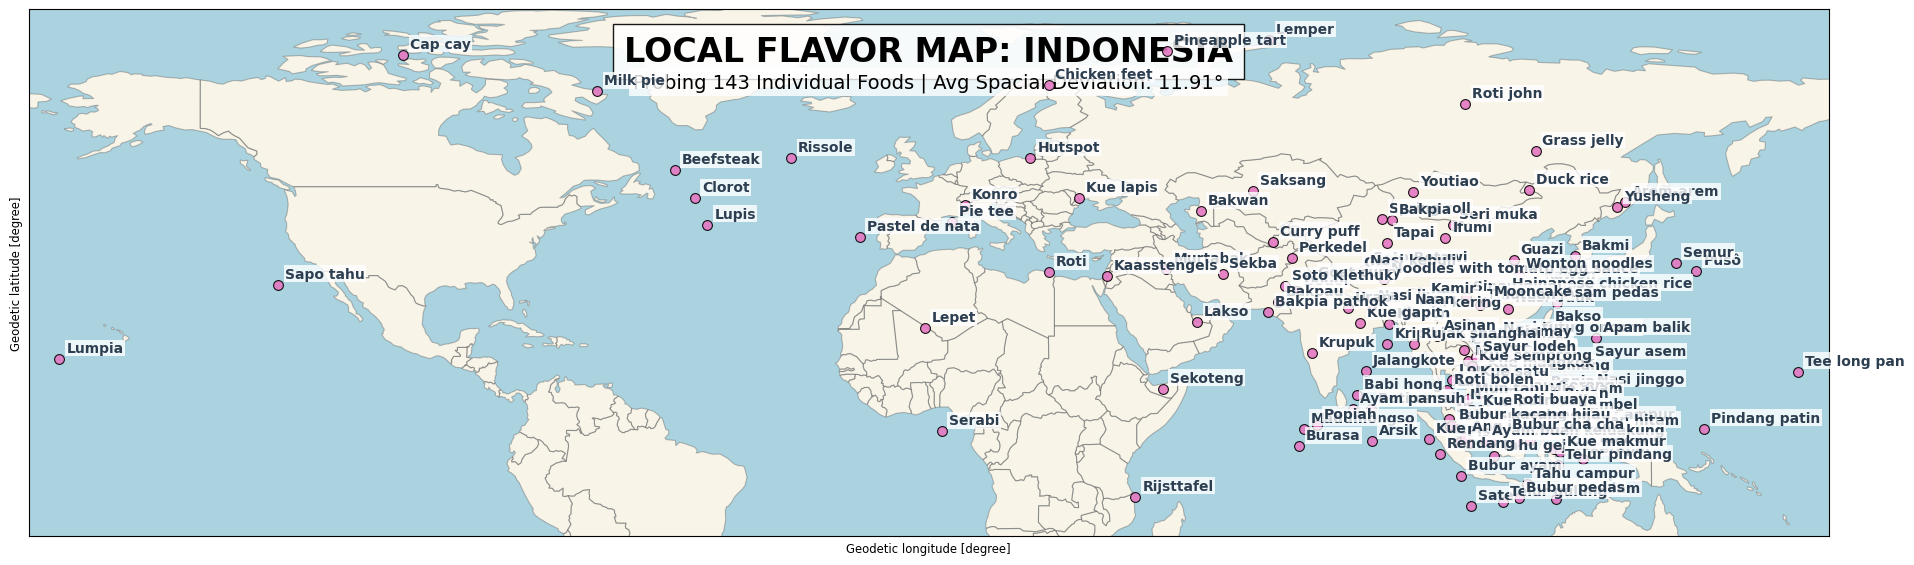

In [22]:
# ============================================================
# EKSPERIMEN B — Fungsi Visualisasi Peta Per-Negara
# Dipanggil manual dengan nama negara untuk inspeksi kualitatif.
# ============================================================

def plot_flavor_map_by_country(target_country):
    # Filter data
    country_data = df_food_points[df_food_points['Country'].str.lower() == target_country.lower()].copy()

    if len(country_data) == 0:
        print(f"Negara '{target_country}' tidak ditemukan atau tidak memiliki data makanan.")
        return

    # Setup Plot (Poster Style)
    fig, ax = plt.subplots(figsize=(18, 10))

    # Hitung Error lokal
    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                 group["Pred_Lat"], group["Pred_Lon"]).mean()

    # Auto-Zoom: Fokus pada sebaran makanan negara tersebut
    padding = 6
    lon_min, lon_max = country_data["Pred_Lon_Plot"].min() - padding, country_data["Pred_Lon_Plot"].max() + padding
    lat_min, lat_max = country_data["Pred_Lat_Plot"].min() - padding, country_data["Pred_Lat_Plot"].max() + padding

    # Estetika Peta
    ax.set_facecolor('#aad3df') # Laut
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.8, color='#5a5a5a', alpha=0.4, zorder=2)
        world.plot(ax=ax, color='#f9f4e8', zorder=1) # Daratan

    # Plot Titik Makanan
    region_name = country_data['Region'].iloc[0]
    dot_color = region_color_map.get(region_name, "dodgerblue")

    ax.scatter(country_data['Pred_Lon_Plot'], country_data['Pred_Lat_Plot'],
               color=dot_color, edgecolor='black', linewidth=0.8, s=50, alpha=0.9, zorder=5)

    # Labeling: Kita tampilkan SEMUA makanan karena per negara biasanya tidak terlalu banyak (10-50)
    for i, row in country_data.iterrows():
        ax.annotate(row['Food'], (row['Pred_Lon_Plot'], row['Pred_Lat_Plot']),
                    fontsize=10, fontweight='bold', color='#2c3e50',
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1),
                    zorder=6)

    # Maksimalisasi Area
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xticks([]); ax.set_yticks([])

    # Judul Overlay
    ax.text(0.5, 0.95, f"LOCAL FLAVOR MAP: {target_country.upper()}",
            transform=ax.transAxes, fontsize=24, fontweight='bold',
            ha='center', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=8))

    ax.text(0.5, 0.88, f"Probing {len(country_data)} Individual Foods | Avg Spacial Deviation: {avg_err_reg:.2f}°",
            transform=ax.transAxes, fontsize=14, ha='center', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
    plt.show()

# --- CARA PAKAI ---
# plot_flavor_map_by_country("Indonesia")
# plot_flavor_map_by_country("Italy")
plot_flavor_map_by_country("Indonesia")

In [23]:
# ============================================================
# HELPER: Koordinat Sferis (3D unit-sphere)
# Menggantikan semua komputasi Euclidean lat/lon untuk Eks 6
# ============================================================
R_EARTH_KM = 6371.0

def latlon_to_xyz(lat_deg, lon_deg):
    """Konversi (lat, lon) derajat → vektor satuan 3D."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.stack([x, y, z], axis=-1)   # shape (..., 3)

def xyz_to_latlon(xyz):
    """Konversi vektor 3D → (lat_deg, lon_deg). xyz tidak harus satuan."""
    xyz = xyz / np.linalg.norm(xyz, axis=-1, keepdims=True)
    lat = np.degrees(np.arcsin(np.clip(xyz[..., 2], -1, 1)))
    lon = np.degrees(np.arctan2(xyz[..., 1], xyz[..., 0]))
    return lat, lon

def spherical_centroid(lat_arr, lon_arr):
    """
    Centroid sferis: rata-rata vektor 3D lalu normalisasi.
    Benar untuk data tersebar di bola; kebal antimeridian.
    """
    xyz = latlon_to_xyz(np.array(lat_arr), np.array(lon_arr))
    mean_xyz = xyz.mean(axis=0)
    mean_xyz /= np.linalg.norm(mean_xyz)
    return xyz_to_latlon(mean_xyz)   # (lat_deg, lon_deg)

def great_circle_km(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam km. Scalar atau array."""
    xyz1 = latlon_to_xyz(np.array(lat1), np.array(lon1))
    xyz2 = latlon_to_xyz(np.array(lat2), np.array(lon2))
    dot = np.clip((xyz1 * xyz2).sum(axis=-1), -1.0, 1.0)
    return R_EARTH_KM * np.arccos(dot)

def great_circle_deg(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam derajat (untuk kompatibilitas laporan lama)."""
    return np.degrees(great_circle_km(lat1, lon1, lat2, lon2) / R_EARTH_KM)

def tangent_plane_error(pred_lat, pred_lon, actual_lat, actual_lon):
    """
    Vektor galat pada bidang tangen lokal di titik aktual: aman terhadap
    wraparound antimeridian, dan komponen timur diskalakan dengan cos(lat)
    karena 1° bujur menyempit di lintang tinggi.
    Return: (north_error_deg, east_error_deg)
    """
    north_error = pred_lat - actual_lat                     # lat tidak periodik, aman apa adanya
    dlon_raw = pred_lon - actual_lon
    dlon_wrapped = (dlon_raw + 180) % 360 - 180              # bungkus ke (-180, 180]
    east_error = dlon_wrapped * np.cos(np.radians(actual_lat))
    return north_error, east_error

def great_circle_error_vector(pred_lat, pred_lon, actual_lat, actual_lon):
    """
    Vektor galat (utara, timur) berbasis azimuth eksak + jarak great-circle.
    Valid untuk sembarang besar sudut, tidak mengasumsikan sudut kecil
    seperti aproksimasi bidang tangen datar.
    """
    lat1 = np.radians(actual_lat)
    lat2 = np.radians(pred_lat)
    dlon = np.radians(pred_lon - actual_lon)

    dist = great_circle_deg(actual_lat, actual_lon, pred_lat, pred_lon)  # great-circle eksak (fungsi di atas)

    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.arctan2(x, y)   # azimuth eksak dari titik aktual ke titik prediksi

    north_err = dist * np.cos(bearing)
    east_err = dist * np.sin(bearing)
    return north_err, east_err

EKSPERIMEN C.1 — CENTROID PREDIKSI PER WILAYAH
Apakah region dengan error tinggi punya centroid prediksi
yang sama (fallback) atau berbeda-beda (genuine hybridity)?
Data individual prediction: 4872 baris artefak.

 CENTROID PREDIKSI PER REGION (diurutkan dari error tertinggi):
            Region  N_Artifacts  Pred_Centroid_Lat  Pred_Centroid_Lon  Actual_Centroid_Lat  Actual_Centroid_Lon  Pred_Spread  Avg_Error  Std_Error
           Oceania           57          66.280033          23.111102           -31.676243           150.790039    34.261149 128.633509  27.846427
  Southern America          238          47.360211         -41.406667           -15.202405           -63.675679    47.467078  70.762114  34.606271
   Southern Africa           47          39.518936          27.481783           -28.250543            23.635684    32.713064  70.316857  21.345341
         Caribbean          178          67.595913         -16.960150            17.425015           -69.001868    40.334495  63.49636

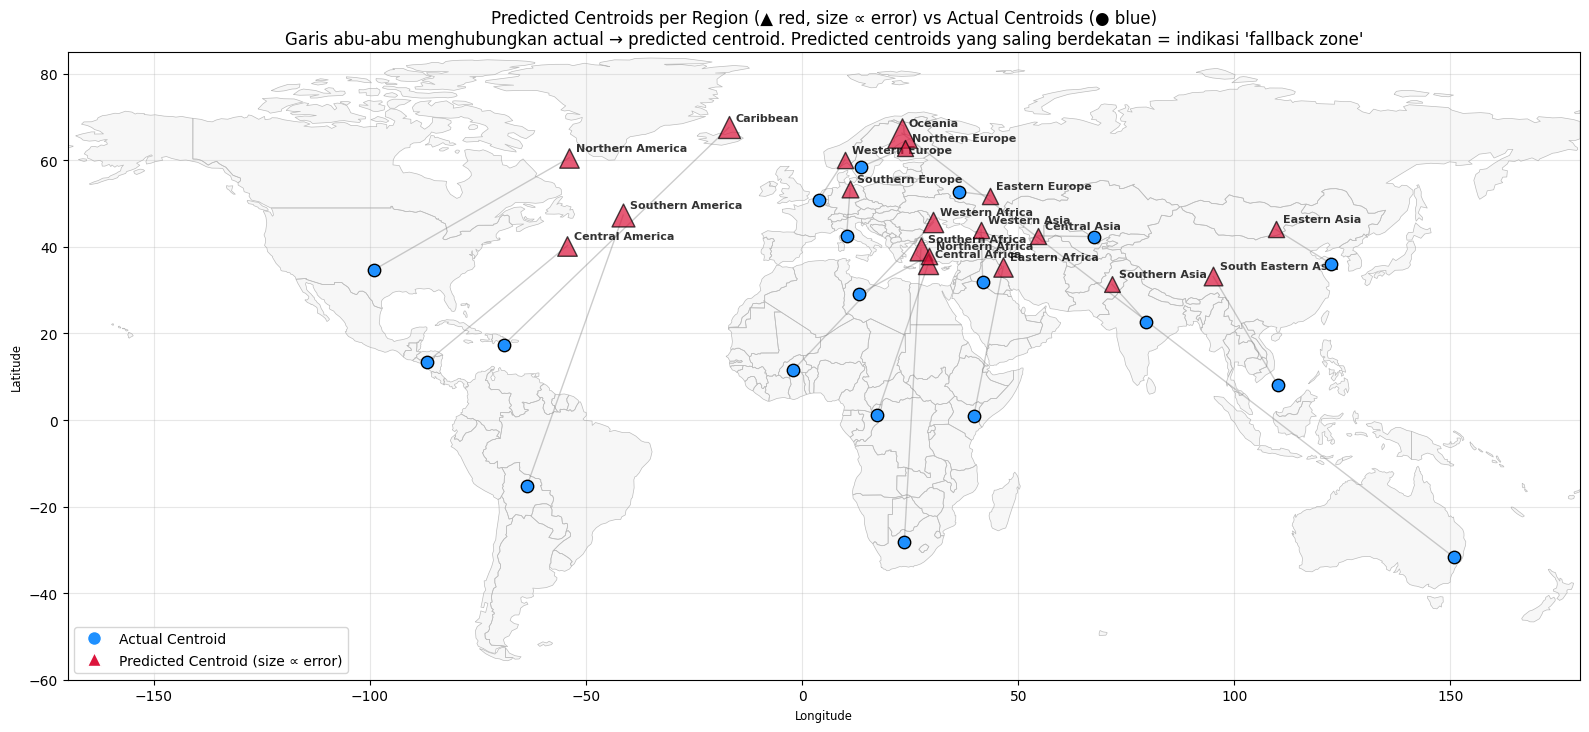


EKSPERIMEN C.1 — KLASIFIKASI MEKANISME ERROR PER WILAYAH

 KLASIFIKASI MEKANISME PER REGION:
            Region  N_Artifacts  Avg_Error  Pred_Spread                             Mechanism
           Oceania           57 128.633509    34.261149 Representational Fallback / Misplaced
  Southern America          238  70.762114    47.467078 Representational Fallback / Misplaced
   Southern Africa           47  70.316857    32.713064 Representational Fallback / Misplaced
         Caribbean          178  63.496364    40.334495 Representational Fallback / Misplaced
    Western Africa          115  51.437461    38.933357 Representational Fallback / Misplaced
    Central Africa           23  50.258237    45.765052 Representational Fallback / Misplaced
   Central America           48  45.858180    38.076887 Representational Fallback / Misplaced
  Northern America          390  44.931213    36.707198 Representational Fallback / Misplaced
    Eastern Africa           75  44.675018    35.400967 Repr

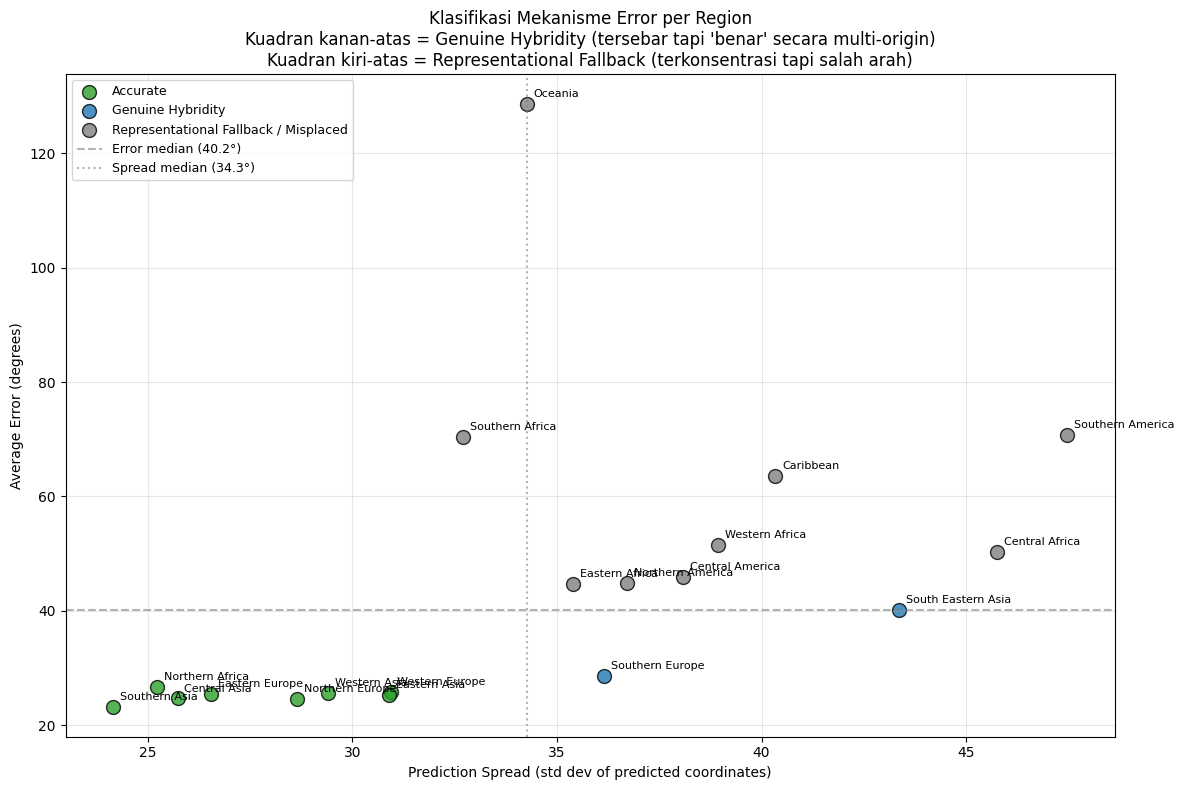


 RINGKASAN AKHIR:

   Genuine Hybridity (2 region):
      - South Eastern Asia
      - Southern Europe

   Representational Fallback / Misplaced (9 region):
      - Oceania
      - Southern America
      - Southern Africa
      - Caribbean
      - Western Africa
      - Central Africa
      - Central America
      - Northern America
      - Eastern Africa

   Accurate (8 region):
      - Northern Africa
      - Western Europe
      - Western Asia
      - Eastern Europe
      - Eastern Asia
      - Central Asia
      - Northern Europe
      - Southern Asia

 EXPERIMENT 6 SELESAI.

Catatan interpretasi:
- 'Genuine Hybridity': error tinggi WAJAR karena artefak budaya
  region ini memang historis berasal dari banyak tempat berbeda.
  -> metrik single-point lat/lon TIDAK ADIL untuk region ini.
- 'Representational Fallback': error tinggi karena model TIDAK
  PUNYA representasi spesifik, prediksi 'jatuh' ke satu zona
  default yang sempit (mungkin sama dengan region lain).
  -> ini indikasi 

In [24]:
# ============================================================
# EKSPERIMEN C.1 — Centroid Regional dan Klasifikasi Mekanisme
# Objective:
#   Membedakan dua mekanisme error tinggi:
#   (A) "Genuine Hybridity"         -> prediksi tersebar mengikuti
#                                       realitas multi-origin artefak
#   (B) "Representational Fallback" -> prediksi konvergen ke satu
#                                       "zona default" global, terlepas
#                                       dari artefaknya
#
# Sumber data: df_food_points, hasil Eksperimen B (Cell 19),
# dengan kolom wajib: Region, Pred_Lat, Pred_Lon, Actual_Lat,
# Actual_Lon.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("=" * 65)
print("EKSPERIMEN C.1 — CENTROID PREDIKSI PER WILAYAH")
print("Apakah region dengan error tinggi punya centroid prediksi")
print("yang sama (fallback) atau berbeda-beda (genuine hybridity)?")
print("=" * 65)

# ------------------------------------------------------------
# Sumber data: df_food_points (hasil Eksperimen B, Cell 19)
# ------------------------------------------------------------

df_ind = df_food_points.copy()

required_cols = {'Region', 'Pred_Lat', 'Pred_Lon', 'Actual_Lat', 'Actual_Lon'}
missing = required_cols - set(df_ind.columns)
assert not missing, f"Kolom berikut tidak ditemukan di df_results_individual: {missing}"

print(f"Data individual prediction: {len(df_ind)} baris artefak.")

# ------------------------------------------------------------
# 6.1.B — Hitung centroid predicted & actual per region
# ------------------------------------------------------------
centroid_records = []

for region, group in df_ind.groupby("Region"):
    if len(group) < 2:
        continue

    pred_centroid_lat, pred_centroid_lon = spherical_centroid(
        group["Pred_Lat"].values, group["Pred_Lon"].values)
    actual_centroid_lat, actual_centroid_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)

    per_item_error = great_circle_deg(
        group["Actual_Lat"].values, group["Actual_Lon"].values,
        group["Pred_Lat"].values,   group["Pred_Lon"].values
    )
    avg_error = per_item_error.mean()
    std_error = per_item_error.std()  # TAMBAHAN: standar deviasi galat great-circle per wilayah

    # Pred_Spread: seberapa tersebar prediksi dalam region ini
    dist_to_pred_centroid = great_circle_deg(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        np.full(len(group), pred_centroid_lat),
        np.full(len(group), pred_centroid_lon)
    )
    pred_spread = np.sqrt(np.mean(dist_to_pred_centroid**2))

    centroid_records.append({
        "Region": region,
        "N_Artifacts": len(group),
        "Pred_Centroid_Lat": pred_centroid_lat,
        "Pred_Centroid_Lon": pred_centroid_lon,
        "Actual_Centroid_Lat": actual_centroid_lat,
        "Actual_Centroid_Lon": actual_centroid_lon,
        "Pred_Spread": pred_spread,
        "Avg_Error": avg_error,
        "Std_Error": std_error,
    })

df_centroids = pd.DataFrame(centroid_records).sort_values("Avg_Error", ascending=False)
print("\n CENTROID PREDIKSI PER REGION (diurutkan dari error tertinggi):")
print(df_centroids.to_string(index=False))

df_centroids['Centroid_Distance'] = great_circle_deg(
    df_centroids['Actual_Centroid_Lat'].values,
    df_centroids['Actual_Centroid_Lon'].values,
    df_centroids['Pred_Centroid_Lat'].values,
    df_centroids['Pred_Centroid_Lon'].values
)

print("\n CENTROID DISTANCE (Actual vs Predicted) per Region:")
print(df_centroids[['Region', 'Centroid_Distance', 'Pred_Spread', 'Avg_Error']]
      .sort_values('Centroid_Distance', ascending=False)
      .to_string(index=False))

# ------------------------------------------------------------
# 6.1.C — Cek "Global Fallback Zone" Hypothesis
# Hitung jarak antar pred_centroid region-region berbeda.
# Jika region-region ber-error-tinggi punya pred_centroid yang
# SALING BERDEKATAN (clustered), maka mendukung hipotesis fallback.
# ------------------------------------------------------------
high_error_regions = df_centroids[df_centroids["Avg_Error"] > df_centroids["Avg_Error"].median()]
low_error_regions = df_centroids[df_centroids["Avg_Error"] <= df_centroids["Avg_Error"].median()]

print(f"\n⏳ Membandingkan dispersi centroid prediksi:")
print(f"   High-error regions (n={len(high_error_regions)}): "
      f"{high_error_regions['Region'].tolist()}")
print(f"   Low-error regions  (n={len(low_error_regions)}): "
      f"{low_error_regions['Region'].tolist()}")

def centroid_dispersion(df_subset):
    """Rata-rata jarak pairwise antar centroid prediksi (lat/lon)."""
    coords = df_subset[["Pred_Centroid_Lat", "Pred_Centroid_Lon"]].values
    if len(coords) < 2:
        return np.nan
    dists = cdist(coords, coords)
    # ambil upper triangle (tanpa diagonal)
    iu = np.triu_indices_from(dists, k=1)
    return dists[iu].mean()

disp_high = centroid_dispersion(high_error_regions)
disp_low = centroid_dispersion(low_error_regions)

print(f"\n Rata-rata jarak antar pred_centroid (degree):")
print(f"   High-error regions: {disp_high:.2f}°")
print(f"   Low-error regions : {disp_low:.2f}°")

if disp_high < disp_low:
    print("\n High-error regions' centroids LEBIH BERDEKATAN satu sama lain")
    print("      -> mendukung hipotesis 'GLOBAL FALLBACK ZONE'")
    print("      (region-region ber-error-tinggi 'jatuh' ke zona yang sama)")
else:
    print("\n High-error regions' centroids TIDAK lebih berdekatan")
    print("      -> tidak ada bukti fallback zone tunggal;")
    print("      tiap region mungkin punya pola hybridity sendiri-sendiri")

# ------------------------------------------------------------
# 6.1.D — Visualisasi: Semua Centroid di Peta Dunia
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))

try:
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
        world.plot(ax=ax, color='#f7f7f7', zorder=0)
except NameError:
    pass

# Plot actual centroids (biru) dan predicted centroids (merah),
# dengan garis penghubung
for _, row in df_centroids.iterrows():
    # Garis dari actual ke predicted centroid
    ax.plot([row["Actual_Centroid_Lon"], row["Pred_Centroid_Lon"]],
            [row["Actual_Centroid_Lat"], row["Pred_Centroid_Lat"]],
            color='gray', alpha=0.4, linewidth=1, zorder=2)

    # Actual centroid (biru)
    ax.scatter(row["Actual_Centroid_Lon"], row["Actual_Centroid_Lat"],
               color='dodgerblue', s=80, edgecolor='black',
               zorder=4, marker='o')

    # Predicted centroid (merah), ukuran proporsional ke avg_error
    size = 60 + row["Avg_Error"] * 3
    ax.scatter(row["Pred_Centroid_Lon"], row["Pred_Centroid_Lat"],
               color='crimson', s=size, edgecolor='black',
               alpha=0.7, zorder=5, marker='^')

    # Label region di predicted centroid
    ax.annotate(row["Region"],
                 (row["Pred_Centroid_Lon"], row["Pred_Centroid_Lat"]),
                 fontsize=8, fontweight='bold', alpha=0.8,
                 xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-170, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Predicted Centroids per Region (▲ red, size ∝ error) "
              "vs Actual Centroids (● blue)\n"
              "Garis abu-abu menghubungkan actual → predicted centroid. "
              "Predicted centroids yang saling berdekatan = indikasi 'fallback zone'")
ax.grid(alpha=0.3)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue',
           markersize=10, label='Actual Centroid'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='crimson',
           markersize=10, label='Predicted Centroid (size ∝ error)')
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.2 — CLASSIFYING ERROR MECHANISM PER REGION
# Objective:
#   Klasifikasi tiap region sebagai:
#   - "Genuine Hybridity"    : Pred_Spread tinggi (prediksi tersebar
#                               luas, mengikuti realitas multi-origin)
#   - "Representational Fallback": Pred_Spread rendah TAPI Avg_Error
#                               tinggi (prediksi terkonsentrasi tapi
#                               salah tempat -> jatuh ke 1 titik tetap)
#   - "Accurate"             : Avg_Error rendah
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.1 — KLASIFIKASI MEKANISME ERROR PER WILAYAH")
print("=" * 65)

# ------------------------------------------------------------
# 6.2.A — Threshold berbasis median (data-driven, bukan arbitrary)
# ------------------------------------------------------------
distance_median = df_centroids["Centroid_Distance"].median()
spread_median = df_centroids["Pred_Spread"].median()

def classify_mechanism(row):
    if row["Centroid_Distance"] <= distance_median:
        if row["Pred_Spread"] > spread_median:
            return "Genuine Hybridity"
        else:
            return "Accurate"
    else:
        return "Representational Fallback / Misplaced"

df_centroids["Mechanism"] = df_centroids.apply(classify_mechanism, axis=1)

print("\n KLASIFIKASI MEKANISME PER REGION:")
print(df_centroids[["Region", "N_Artifacts", "Avg_Error",
                     "Pred_Spread", "Mechanism"]]
      .sort_values("Avg_Error", ascending=False)
      .to_string(index=False))

error_median = df_centroids["Avg_Error"].median()
spread_median = df_centroids["Pred_Spread"].median()

# ------------------------------------------------------------
# 6.2.B — Visualisasi: Scatter Avg_Error vs Pred_Spread,
#         dengan kuadran klasifikasi
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

mechanism_colors = {
    "Accurate": "tab:green",
    "Genuine Hybridity": "tab:blue",
    "Representational Fallback": "tab:red"
}

for mech, group in df_centroids.groupby("Mechanism"):
    ax.scatter(group["Pred_Spread"], group["Avg_Error"],
               label=mech, color=mechanism_colors.get(mech, "gray"),
               s=100, edgecolor='black', alpha=0.8)
    for _, row in group.iterrows():
        ax.annotate(row["Region"], (row["Pred_Spread"], row["Avg_Error"]),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

# Garis threshold
ax.axhline(error_median, color='gray', linestyle='--', alpha=0.6,
           label=f'Error median ({error_median:.1f}°)')
ax.axvline(spread_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Spread median ({spread_median:.1f}°)')

ax.set_xlabel("Prediction Spread (std dev of predicted coordinates)")
ax.set_ylabel("Average Error (degrees)")
ax.set_title("Klasifikasi Mekanisme Error per Region\n"
              "Kuadran kanan-atas = Genuine Hybridity (tersebar tapi 'benar' secara multi-origin)\n"
              "Kuadran kiri-atas = Representational Fallback (terkonsentrasi tapi salah arah)")
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6.2.C — Ringkasan akhir
# ------------------------------------------------------------
print("\n RINGKASAN AKHIR:")
for mech in ["Genuine Hybridity", "Representational Fallback / Misplaced", "Accurate"]:  # FIX: string harus persis sama dengan classify_mechanism()
    regions = df_centroids[df_centroids["Mechanism"] == mech]["Region"].tolist()
    print(f"\n   {mech} ({len(regions)} region):")
    for r in regions:
        print(f"      - {r}")

print("\n EXPERIMENT 6 SELESAI.")
print("\nCatatan interpretasi:")
print("- 'Genuine Hybridity': error tinggi WAJAR karena artefak budaya")
print("  region ini memang historis berasal dari banyak tempat berbeda.")
print("  -> metrik single-point lat/lon TIDAK ADIL untuk region ini.")
print("- 'Representational Fallback': error tinggi karena model TIDAK")
print("  PUNYA representasi spesifik, prediksi 'jatuh' ke satu zona")
print("  default yang sempit (mungkin sama dengan region lain).")
print("  -> ini indikasi UNDERREPRESENTATION dalam training data.")

EKSPERIMEN C.2 — RASIO BIAS SISTEMATIS
Ratio = Centroid_Distance / Avg_Error
  Ratio -> 1+  : BIAS SISTEMATIS (model 'salah arah' konsisten)
  Ratio -> 0   : ERROR ACAK (individual errors saling membatalkan)
Bias_Ratio = bias²/MSE (fraksi MSE dari error sistematis), range [0,1] eksak.

 BIAS RATIO PER REGION (diurutkan dari paling sistematis):
            Region  N_Artifacts  Avg_Error  Centroid_Distance  Pred_Spread  Bias_Ratio
   Southern Africa           47  70.316857          67.864175    32.713064    0.711037
         Caribbean          178  63.496364          59.965060    40.334495    0.617227
           Oceania           57 128.633509         133.630829    34.261149    0.594762
   Central America           48  45.858180          39.208674    38.076887    0.518316
  Northern America          390  44.931213          38.706570    36.707198    0.500859
  Southern America          238  70.762114          65.667960    47.467078    0.498227
    Western Africa          115  51.437461   

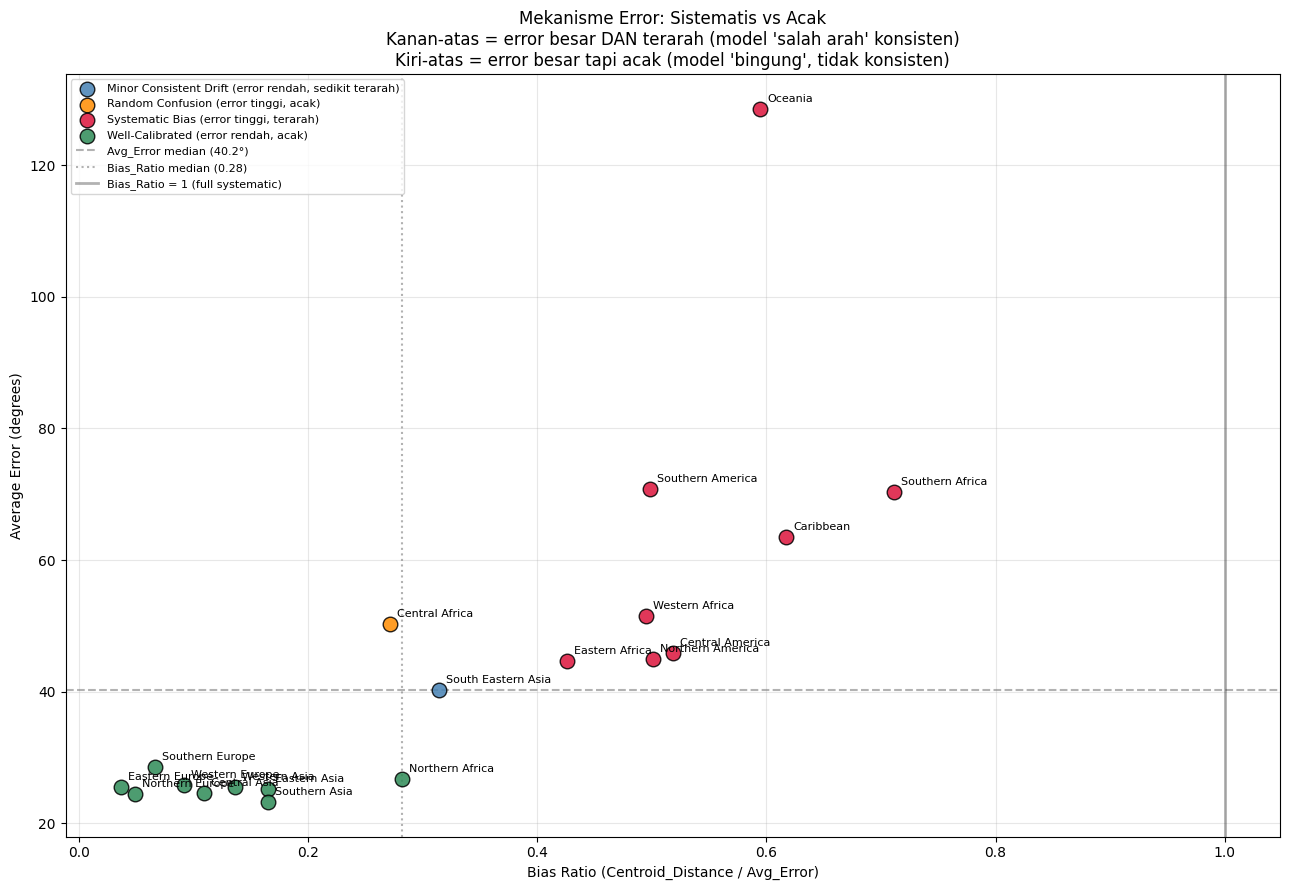


 EXPERIMENT 6.3 SELESAI.

Catatan interpretasi:
- Bias_Ratio tinggi + Avg_Error tinggi (kuadran kanan-atas):
  Model punya 'mental map yang salah secara konsisten' untuk region ini
  -> mengarah ke representational fallback / misconception sistematis
- Bias_Ratio rendah + Avg_Error tinggi (kuadran kiri-atas):
  Model 'tidak yakin' tapi tidak bias ke arah tertentu
  -> mengarah ke genuine ambiguity / lack of strong signal (bukan misconception)
- Bias_Ratio tinggi + Avg_Error rendah (kuadran kanan-bawah):
  Sedikit bias konsisten, tapi magnitude kecil -> minor, biasanya bisa diabaikan
- Bias_Ratio rendah + Avg_Error rendah (kuadran kiri-bawah):
  Model akurat dan tidak bias -> representasi paling 'sehat'


In [25]:
# ============================================================
# EKSPERIMEN C.2 — Rasio Bias Sistematis (Bias_Ratio)
# Objective:
#   Membedakan dua mekanisme error:
#   - ERROR ACAK: galat individual saling membatalkan ->
#     Centroid_Distance << Avg_Error -> rasio kecil
#   - BIAS SISTEMATIS: galat individual konsisten ke satu arah
#     -> Centroid_Distance mendekati Avg_Error -> rasio mendekati 1
#
# Formula: Bias_Ratio = Bias^2 / MSE (lihat Bab III.3.5.2).
# Dependensi: df_centroids dari Eksperimen C.1.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 65)
print("EKSPERIMEN C.2 — RASIO BIAS SISTEMATIS")
print("Ratio = Centroid_Distance / Avg_Error")
print("  Ratio -> 1+  : BIAS SISTEMATIS (model 'salah arah' konsisten)")
print("  Ratio -> 0   : ERROR ACAK (individual errors saling membatalkan)")
print("=" * 65)

assert 'Centroid_Distance' in df_centroids.columns, (
    "Kolom 'Centroid_Distance' tidak ada di df_centroids. "
    "Pastikan Experiment 6.1 (centroid distance) sudah dijalankan."
)

# ------------------------------------------------------------
# 6.3.A — Hitung Bias Ratio
# ------------------------------------------------------------
# Hitung di ruang vektor error 2D (setelah Patch 2, Centroid_Distance sudah great-circle)
# Gunakan komponen error lat dan lon (dalam derajat) per artefak.

bias_variance_records = []
for region, group in df_ind.groupby("Region"):
    if len(group) < 2:
        continue
    # --- DENGAN ini ---
    north_err, east_err = great_circle_error_vector(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        group["Actual_Lat"].values, group["Actual_Lon"].values
    )
    errors = np.stack([north_err, east_err], axis=1)   # aman antimeridian

    mse = np.mean(np.sum(errors**2, axis=1))       # rata-rata ||e||^2
    bias_vec = errors.mean(axis=0)                  # mean error vektor
    bias_sq = np.dot(bias_vec, bias_vec)            # ||mean_e||^2

    # Identitas eksak: MSE = bias^2 + variance
    bias_ratio_sq = bias_sq / mse if mse > 0 else 0.0   # ∈ [0,1] eksak

    bias_variance_records.append({
        "Region": region,
        "MSE": mse,
        "Bias_Sq": bias_sq,
        "Variance": mse - bias_sq,
        "Bias_Ratio": bias_ratio_sq,   # ini sekarang fraksi bias dari MSE
    })

df_bv = pd.DataFrame(bias_variance_records)
# Merge ke df_centroids
df_centroids = df_centroids.merge(df_bv[["Region", "Bias_Ratio"]], on="Region", how="left")

print("Bias_Ratio = bias²/MSE (fraksi MSE dari error sistematis), range [0,1] eksak.")

df_bias = df_centroids[
    ['Region', 'N_Artifacts', 'Avg_Error', 'Centroid_Distance',
     'Pred_Spread', 'Bias_Ratio']
].sort_values('Bias_Ratio', ascending=False)

print("\n BIAS RATIO PER REGION (diurutkan dari paling sistematis):")
print(df_bias.to_string(index=False))

# ------------------------------------------------------------
# 6.3.B — Bandingkan ranking: Avg_Error vs Bias_Ratio
# ------------------------------------------------------------
df_bias_ranked = df_bias.copy()
df_bias_ranked['Rank_AvgError'] = df_bias_ranked['Avg_Error'].rank(ascending=False).astype(int)
df_bias_ranked['Rank_BiasRatio'] = df_bias_ranked['Bias_Ratio'].rank(ascending=False).astype(int)
df_bias_ranked['Rank_Diff'] = df_bias_ranked['Rank_AvgError'] - df_bias_ranked['Rank_BiasRatio']

print("\n PERBANDINGAN RANKING: Avg_Error vs Bias_Ratio")
print("   (Rank_Diff = 0 -> ranking sama; "
      "Rank_Diff besar -> region ini 'pindah kelompok')")
print(df_bias_ranked[['Region', 'Avg_Error', 'Rank_AvgError',
                       'Bias_Ratio', 'Rank_BiasRatio', 'Rank_Diff']]
      .sort_values('Rank_AvgError')
      .to_string(index=False))

from scipy.stats import spearmanr
r_rank, p_rank = spearmanr(df_bias_ranked['Avg_Error'], df_bias_ranked['Bias_Ratio'])
print(f"\n Korelasi Spearman Avg_Error vs Bias_Ratio: r={r_rank:.3f} (p={p_rank:.4f})")
if r_rank > 0.5:
    print("   -> Region dengan error tinggi JUGA cenderung punya bias sistematis")
    print("      (error tinggi DAN terarah, bukan acak)")
elif r_rank < -0.2:
    print("   -> Region dengan error tinggi justru cenderung errornya ACAK")
else:
    print("   -> Tidak ada hubungan kuat; error tinggi bisa sistematis ATAU acak,")
    print("      tergantung region -> dua mekanisme berbeda yang perlu dibedakan")

# ------------------------------------------------------------
# 6.3.C — Klasifikasi 2x2: Avg_Error (tinggi/rendah) x Bias_Ratio (tinggi/rendah)
# ------------------------------------------------------------
error_median = df_bias['Avg_Error'].median()
ratio_median = df_bias['Bias_Ratio'].median()

print(f"\nThreshold (median-based):")
print(f"   Avg_Error median = {error_median:.2f}°")
print(f"   Bias_Ratio median = {ratio_median:.3f}")

def classify_2x2(row):
    high_error = row['Avg_Error'] > error_median
    high_ratio = row['Bias_Ratio'] > ratio_median
    if high_error and high_ratio:
        return "Systematic Bias (error tinggi, terarah)"
    elif high_error and not high_ratio:
        return "Random Confusion (error tinggi, acak)"
    elif not high_error and high_ratio:
        return "Minor Consistent Drift (error rendah, sedikit terarah)"
    else:
        return "Well-Calibrated (error rendah, acak)"

df_bias['Mechanism_2x2'] = df_bias.apply(classify_2x2, axis=1)
# FIX: gabungkan balik ke df_centroids, supaya Eksperimen C.3 memakai
# klasifikasi 2x2 yang benar alih-alih selalu jatuh ke fallback
df_centroids = df_centroids.merge(
    df_bias[['Region', 'Mechanism_2x2']], on='Region', how='left'
)

print("\n KLASIFIKASI 2x2 (Avg_Error x Bias_Ratio):")
print(df_bias[['Region', 'Avg_Error', 'Bias_Ratio', 'Mechanism_2x2']]
      .sort_values('Avg_Error', ascending=False)
      .to_string(index=False))

print("\n RINGKASAN PER KUADRAN:")
for mech in ["Systematic Bias (error tinggi, terarah)",
              "Random Confusion (error tinggi, acak)",
              "Minor Consistent Drift (error rendah, sedikit terarah)",
              "Well-Calibrated (error rendah, acak)"]:
    regions = df_bias[df_bias['Mechanism_2x2'] == mech]['Region'].tolist()
    print(f"\n   {mech} ({len(regions)} region):")
    for r in regions:
        print(f"      - {r}")

# ------------------------------------------------------------
# 6.3.D — Visualisasi: Scatter 2x2 (Avg_Error vs Bias_Ratio)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 9))

quadrant_colors = {
    "Systematic Bias (error tinggi, terarah)": "crimson",
    "Random Confusion (error tinggi, acak)": "darkorange",
    "Minor Consistent Drift (error rendah, sedikit terarah)": "steelblue",
    "Well-Calibrated (error rendah, acak)": "seagreen",
}

for mech, group in df_bias.groupby("Mechanism_2x2"):
    ax.scatter(group['Bias_Ratio'], group['Avg_Error'],
               label=mech, color=quadrant_colors.get(mech, "gray"),
               s=110, edgecolor='black', alpha=0.85, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['Region'], (row['Bias_Ratio'], row['Avg_Error']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(error_median, color='gray', linestyle='--', alpha=0.6,
           label=f'Avg_Error median ({error_median:.1f}°)')
ax.axvline(ratio_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Bias_Ratio median ({ratio_median:.2f})')
ax.axvline(1.0, color='black', linestyle='-', alpha=0.3, linewidth=2,
           label='Bias_Ratio = 1 (full systematic)')

ax.set_xlabel("Bias Ratio (Centroid_Distance / Avg_Error)")
ax.set_ylabel("Average Error (degrees)")
ax.set_title("Mekanisme Error: Sistematis vs Acak\n"
              "Kanan-atas = error besar DAN terarah (model 'salah arah' konsisten)\n"
              "Kiri-atas = error besar tapi acak (model 'bingung', tidak konsisten)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.3 SELESAI.")
print("\nCatatan interpretasi:")
print("- Bias_Ratio tinggi + Avg_Error tinggi (kuadran kanan-atas):")
print("  Model punya 'mental map yang salah secara konsisten' untuk region ini")
print("  -> mengarah ke representational fallback / misconception sistematis")
print("- Bias_Ratio rendah + Avg_Error tinggi (kuadran kiri-atas):")
print("  Model 'tidak yakin' tapi tidak bias ke arah tertentu")
print("  -> mengarah ke genuine ambiguity / lack of strong signal (bukan misconception)")
print("- Bias_Ratio tinggi + Avg_Error rendah (kuadran kanan-bawah):")
print("  Sedikit bias konsisten, tapi magnitude kecil -> minor, biasanya bisa diabaikan")
print("- Bias_Ratio rendah + Avg_Error rendah (kuadran kiri-bawah):")
print("  Model akurat dan tidak bias -> representasi paling 'sehat'")

EKSPERIMEN C.3 — ARAH BIAS (DIRECTION CONSISTENCY)
Apakah region-region 'Systematic Bias' mengarah ke
satu 'gravitational center' yang sama?

 BIAS VECTOR PER REGION:
            Region  Bias_Vec_North  Bias_Vec_East  Bias_Angle_Deg  Centroid_Distance  Bias_Ratio
   Southern Africa       67.758208       3.790979       86.797718          67.864175    0.711037
         Caribbean       56.236438      20.815172       69.688635          59.965060    0.617227
           Oceania      120.009131     -58.779307      116.095164         133.630829    0.594762
   Central America       29.830207      25.445606       49.535333          39.208674    0.518316
  Northern America       32.138078      21.571799       56.129601          38.706570    0.500859
  Southern America       63.008104      18.500267       73.636851          65.667960    0.498227
    Western Africa       36.944002      23.778066       57.233673          43.934676    0.494978
    Eastern Africa       34.586265       5.902177       8

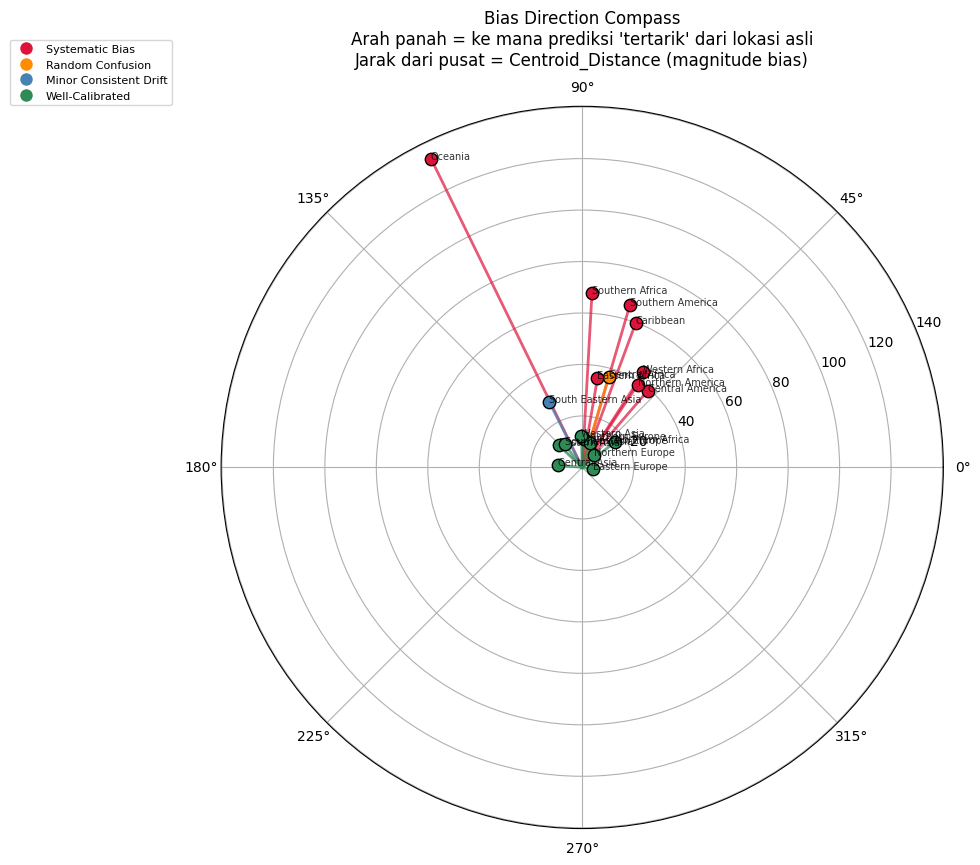


EKSPERIMEN C.3 — TARGET KEKELIRUAN (CONFUSION TARGET)
Region mana yang predicted centroid-nya paling dekat dengan
ACTUAL centroid region lain? -> 'model salah kira artefak ini dari mana'

 CONFUSION TARGET PER REGION:
   (Closest_Confusion_Target = region yang ACTUAL centroid-nya
    paling dekat dengan PREDICTED centroid region ini)
   (Improvement_vs_Self > 0 -> predicted centroid LEBIH DEKAT
    ke region lain daripada ke lokasi aslinya sendiri -> 'salah kira')

            Region  Centroid_Distance_to_Self Closest_Confusion_Target  Distance_to_Target  Improvement_vs_Self
           Oceania                 133.630829          Northern Europe            8.869863           124.760966
   Southern Africa                  67.864175          Southern Europe           13.290676            54.573499
  Southern America                  65.667960           Western Europe           29.353950            36.314011
         Caribbean                  59.965060          Northern Europe           

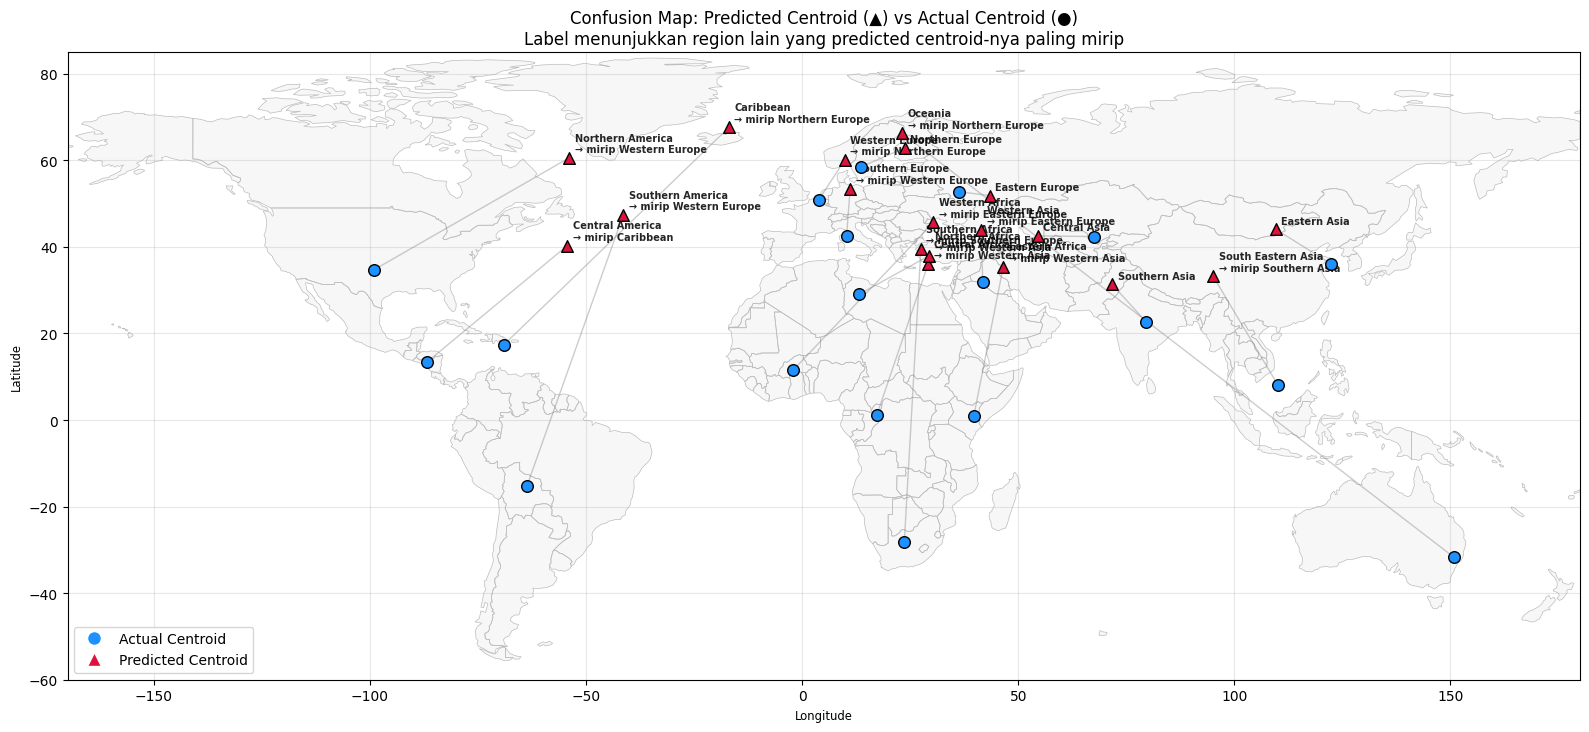


 EXPERIMENT 6.4 SELESAI.


In [26]:
# ============================================================
# EKSPERIMEN C.3 — Arah Bias dan Target Kekeliruan
# Objective:
#   (1) Direction Consistency: apakah region-region dengan bias
#       sistematis tinggi punya ARAH bias yang SAMA (mengindikasikan
#       satu "pusat gravitasi" representasional global)?
#   (2) Confusion Target: untuk tiap region, region lain mana yang
#       paling "tertukar" dengannya (mis. "Oceania -> dikira
#       Northern Europe").
#
# Dependensi: df_centroids dari Eksperimen C.1.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("=" * 65)
print("EKSPERIMEN C.3 — ARAH BIAS (DIRECTION CONSISTENCY)")
print("Apakah region-region 'Systematic Bias' mengarah ke")
print("satu 'gravitational center' yang sama?")
print("=" * 65)

# ------------------------------------------------------------
# 6.4.A.1 — Hitung bias vector (arah & magnitude) per region
# ------------------------------------------------------------
df_centroids = df_centroids.copy()

north_c, east_c = great_circle_error_vector(
    df_centroids['Pred_Centroid_Lat'].values, df_centroids['Pred_Centroid_Lon'].values,
    df_centroids['Actual_Centroid_Lat'].values, df_centroids['Actual_Centroid_Lon'].values
)
df_centroids['Bias_Vec_North'] = north_c
df_centroids['Bias_Vec_East'] = east_c

df_centroids['Bias_Angle_Deg'] = np.degrees(
    np.arctan2(df_centroids['Bias_Vec_North'], df_centroids['Bias_Vec_East'])
)

print("\n BIAS VECTOR PER REGION:")
print(df_centroids[['Region', 'Bias_Vec_North', 'Bias_Vec_East',
                     'Bias_Angle_Deg', 'Centroid_Distance', 'Bias_Ratio']]
      .sort_values('Bias_Ratio', ascending=False)
      .to_string(index=False))
# ------------------------------------------------------------
# 6.4.A.2 — Cek konsistensi arah HANYA untuk region "Systematic Bias"
# ------------------------------------------------------------
if 'Mechanism_2x2' in df_centroids.columns:
    systematic = df_centroids[
        df_centroids['Mechanism_2x2'].str.contains('Systematic Bias', na=False)
    ]
else:
    # fallback: pakai threshold Bias_Ratio > median
    ratio_median = df_centroids['Bias_Ratio'].median()
    systematic = df_centroids[df_centroids['Bias_Ratio'] > ratio_median]

print(f"\n⏳ Region dengan Systematic Bias (n={len(systematic)}): "
      f"{systematic['Region'].tolist()}")

if len(systematic) >= 2:
    angles_rad = np.radians(systematic['Bias_Angle_Deg'].values)
    R = np.sqrt(np.mean(np.cos(angles_rad))**2 + np.mean(np.sin(angles_rad))**2)
    mean_angle = np.degrees(np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad))))

    print(f"\n Direction Consistency (R) untuk region Systematic Bias: {R:.3f}")
    print(f"   Mean bias direction: {mean_angle:.1f}°")
    print("   (R mendekati 1 -> SEMUA region bias ke arah yang SAMA "
          "-> ada 'gravitational center' global)")
    print("   (R mendekati 0 -> arah bias berbeda-beda per region "
          "-> tiap region punya 'salah kaprah' sendiri-sendiri)")

    if R > 0.6:
        print("\n Indikasi kuat ada GRAVITATIONAL CENTER global.")
    else:
        print("\n Tidak ada gravitational center tunggal yang jelas;")
        print("      tiap region kemungkinan punya confusion target berbeda.")

# ------------------------------------------------------------
# 6.4.A.3 — Visualisasi: Compass plot (semua bias vector dari origin)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

colors_map = {
    "Systematic Bias (error tinggi, terarah)": "crimson",
    "Random Confusion (error tinggi, acak)": "darkorange",
    "Minor Consistent Drift (error rendah, sedikit terarah)": "steelblue",
    "Well-Calibrated (error rendah, acak)": "seagreen",
}

for _, row in df_centroids.iterrows():
    angle_rad = np.radians(row['Bias_Angle_Deg'])
    magnitude = row['Centroid_Distance']
    mech = row.get('Mechanism_2x2', 'Unknown')
    color = colors_map.get(mech, 'gray')

    ax.plot([angle_rad, angle_rad], [0, magnitude],
            color=color, alpha=0.7, linewidth=2)
    ax.scatter(angle_rad, magnitude, color=color, s=80,
               edgecolor='black', zorder=3)
    ax.annotate(row['Region'], (angle_rad, magnitude),
                fontsize=7, alpha=0.8)

# Tambahkan reference arah kompas
ax.set_theta_zero_location('E')  # 0° = timur (lon+)
ax.set_theta_direction(1)         # counter-clockwise = utara (lat+)
ax.set_title("Bias Direction Compass\n"
              "Arah panah = ke mana prediksi 'tertarik' dari lokasi asli\n"
              "Jarak dari pusat = Centroid_Distance (magnitude bias)",
              pad=30)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=c, markersize=10, label=m.split('(')[0].strip())
                    for m, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(-0.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.4.B — CONFUSION TARGET
# Untuk tiap region, cari region LAIN yang ACTUAL centroid-nya
# paling dekat dengan PREDICTED centroid region tersebut.
# -> "Model mengira artefak [Region A] itu sebenarnya dari [Region B]"
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.3 — TARGET KEKELIRUAN (CONFUSION TARGET)")
print("Region mana yang predicted centroid-nya paling dekat dengan")
print("ACTUAL centroid region lain? -> 'model salah kira artefak ini dari mana'")
print("=" * 65)

regions = df_centroids['Region'].values
actual_coords = df_centroids[['Actual_Centroid_Lat', 'Actual_Centroid_Lon']].values
pred_coords = df_centroids[['Pred_Centroid_Lat', 'Pred_Centroid_Lon']].values

# Jarak dari predicted centroid region i ke actual centroid region j (semua pasangan)
n = len(df_centroids)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = great_circle_deg(
            df_centroids['Pred_Centroid_Lat'].iloc[i],
            df_centroids['Pred_Centroid_Lon'].iloc[i],
            df_centroids['Actual_Centroid_Lat'].iloc[j],
            df_centroids['Actual_Centroid_Lon'].iloc[j]
        )

confusion_records = []
for i, region in enumerate(regions):
    # Urutkan jarak predicted_i ke semua actual_j, ambil yang terdekat
    # EXCLUDE region itu sendiri dulu untuk lihat "kalau bukan dirinya, mirip siapa"
    dists_to_others = {regions[j]: dist_matrix[i, j] for j in range(len(regions)) if j != i}
    dists_to_self = dist_matrix[i, i]  # = Centroid_Distance, untuk referensi

    sorted_targets = sorted(dists_to_others.items(), key=lambda x: x[1])
    closest_region, closest_dist = sorted_targets[0]
    second_region, second_dist = sorted_targets[1]

    confusion_records.append({
        "Region": region,
        "Centroid_Distance_to_Self": dists_to_self,
        "Closest_Confusion_Target": closest_region,
        "Distance_to_Target": closest_dist,
        "2nd_Closest_Target": second_region,
        "Distance_to_2nd": second_dist,
        "Improvement_vs_Self": dists_to_self - closest_dist,
    })

df_confusion = pd.DataFrame(confusion_records).sort_values(
    "Centroid_Distance_to_Self", ascending=False
)

print("\n CONFUSION TARGET PER REGION:")
print("   (Closest_Confusion_Target = region yang ACTUAL centroid-nya")
print("    paling dekat dengan PREDICTED centroid region ini)")
print("   (Improvement_vs_Self > 0 -> predicted centroid LEBIH DEKAT")
print("    ke region lain daripada ke lokasi aslinya sendiri -> 'salah kira')")
print()
print(df_confusion[['Region', 'Centroid_Distance_to_Self',
                     'Closest_Confusion_Target', 'Distance_to_Target',
                     'Improvement_vs_Self']].to_string(index=False))

# ------------------------------------------------------------
# 6.4.B.2 — Highlight "salah kira" yang paling jelas
# (predicted centroid lebih dekat ke region LAIN daripada ke dirinya sendiri)
# ------------------------------------------------------------
misidentified = df_confusion[df_confusion['Improvement_vs_Self'] > 0]
misidentified = misidentified.sort_values('Improvement_vs_Self', ascending=False)

print("\n REGION DENGAN 'SALAH KIRA' PALING JELAS:")
print("   (predicted centroid region ini LEBIH MIRIP region lain")
print("    daripada lokasi aslinya sendiri)\n")

if len(misidentified) == 0:
    print("   Tidak ada region yang predicted centroid-nya lebih dekat")
    print("   ke region lain dibanding ke dirinya sendiri.")
else:
    for _, row in misidentified.iterrows():
        print(f"   '{row['Region']}' artefaknya cenderung di-decode model "
              f"sebagai berasal dari '{row['Closest_Confusion_Target']}'")
        print(f"      (jarak ke {row['Closest_Confusion_Target']}: "
              f"{row['Distance_to_Target']:.1f}° "
              f"vs jarak ke lokasi asli sendiri: {row['Centroid_Distance_to_Self']:.1f}°)\n")

# ------------------------------------------------------------
# 6.4.B.3 — Visualisasi: Peta dengan confusion target arrows
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))

try:
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
        world.plot(ax=ax, color='#f7f7f7', zorder=0)
except NameError:
    pass

for _, row in df_centroids.iterrows():
    region = row['Region']
    conf_row = df_confusion[df_confusion['Region'] == region].iloc[0]

    # Actual centroid (biru)
    ax.scatter(row['Actual_Centroid_Lon'], row['Actual_Centroid_Lat'],
               color='dodgerblue', s=70, edgecolor='black', zorder=4)

    # Predicted centroid (merah)
    ax.scatter(row['Pred_Centroid_Lon'], row['Pred_Centroid_Lat'],
               color='crimson', s=70, edgecolor='black', zorder=4, marker='^')

    # Garis actual -> predicted
    ax.plot([row['Actual_Centroid_Lon'], row['Pred_Centroid_Lon']],
            [row['Actual_Centroid_Lat'], row['Pred_Centroid_Lat']],
            color='gray', alpha=0.4, linewidth=1, zorder=2)

    # Label: tampilkan confusion target jika "salah kira" signifikan
    label = region
    if conf_row['Improvement_vs_Self'] > 0:
        label += f"\n→ mirip {conf_row['Closest_Confusion_Target']}"

    ax.annotate(label, (row['Pred_Centroid_Lon'], row['Pred_Centroid_Lat']),
                fontsize=7, fontweight='bold', alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlim(-170, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Confusion Map: Predicted Centroid (▲) vs Actual Centroid (●)\n"
              "Label menunjukkan region lain yang predicted centroid-nya paling mirip")
ax.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue',
           markersize=10, label='Actual Centroid'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='crimson',
           markersize=10, label='Predicted Centroid')
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.4 SELESAI.")

EKSPERIMEN C.4 — GALAT TERNORMALISASI
Avg_Error relatif terhadap 'ukuran' geografis aktual region

 AVG_ERROR vs ACTUAL_SPREAD vs NORMALIZED_ERROR
   (diurutkan dari Avg_Error terendah -> region 'paling akurat' secara absolut)
            Region  N_Countries  Avg_Error  Actual_Spread  Normalized_Error
     Southern Asia            8  23.222457      12.682078          1.831124
   Northern Europe            8  24.482656       6.684869          3.662399
      Central Asia            5  24.647525       5.199937          4.739966
      Eastern Asia            8  25.239952      12.559786          2.009585
    Eastern Europe           13  25.461954      14.183904          1.795130
      Western Asia           16  25.548848       8.955134          2.852983
    Western Europe            8  25.832092       4.462230          5.789054
   Northern Africa            6  26.662878      14.170688          1.881551
   Southern Europe           12  28.603127       7.589540          3.768756
South Eastern

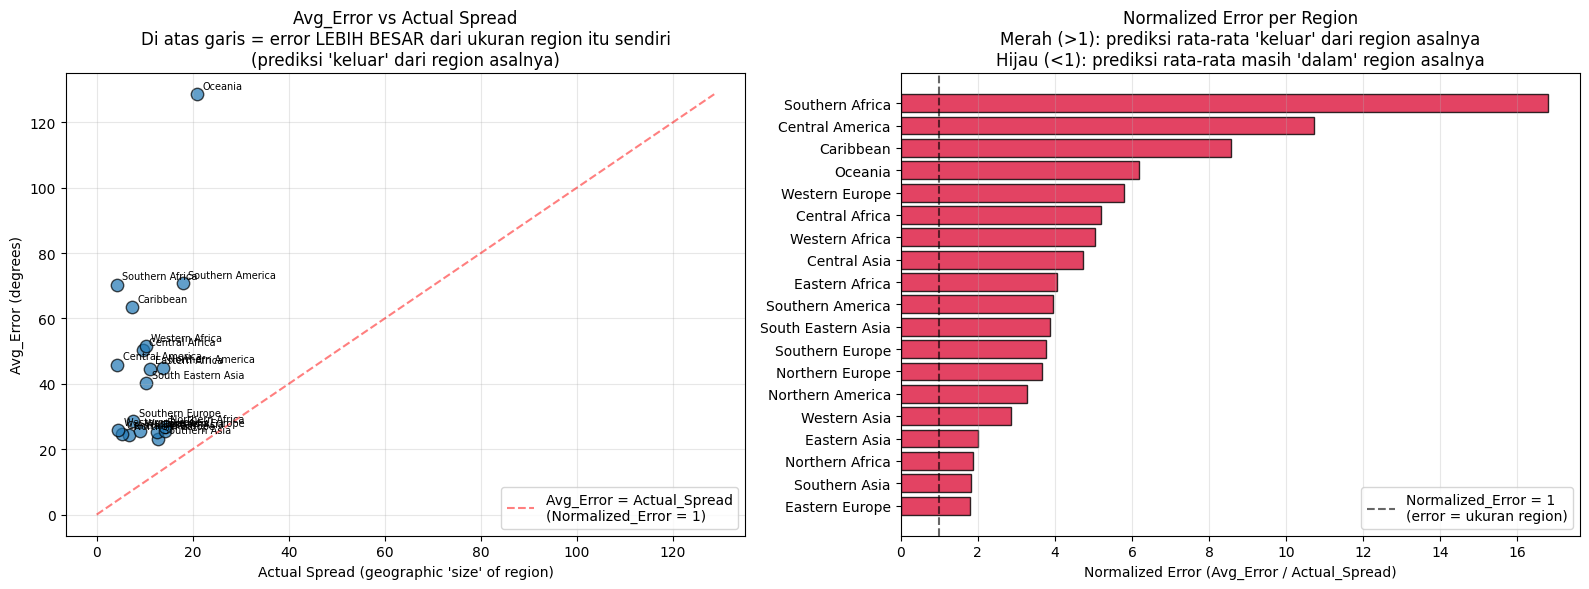


EKSPERIMEN C.4 — KORELASI STRUKTURAL (WITHIN-REGION DISCRIMINABILITY)
Apakah model membedakan negara A vs B DALAM region yang sama,
dengan struktur jarak relatif yang konsisten dgn realitas?

 WITHIN-REGION DISCRIMINABILITY (Structure Correlation):
   Structure_Correlation = korelasi Spearman antara:
   - jarak ASLI antar negara dalam region (actual pairwise distances)
   - jarak PREDIKSI antar negara yang sama (predicted pairwise distances)

   Tinggi (-> 1) : model menangkap STRUKTUR RELATIF dengan baik
                   (negara yg dekat secara asli, predicted-nya juga dekat)
   Rendah/negatif: model TIDAK BISA membedakan negara dalam region ini
                   (semua 'ditumpuk' di tempat serupa, tidak granular)

            Region  N_Countries  N_Pairs  Structure_Correlation  Structure_P_Mantel  Max_Permutations
      Western Asia           16      120               0.770748               0.001               999
   Southern Europe           12       66               0.769085   

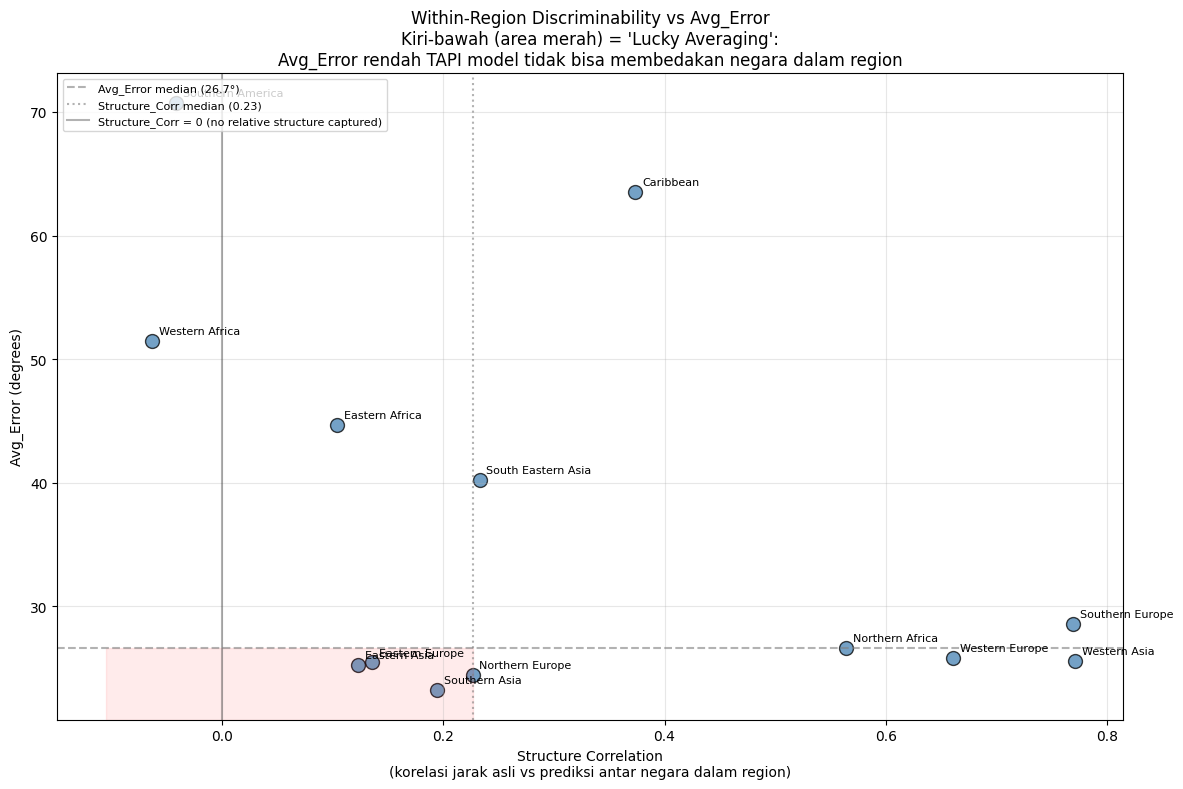


 EXPERIMENT 6.5 SELESAI.

Catatan interpretasi akhir:
- Normalized_Error tinggi (>1): error absolut MUNGKIN kecil,
  tapi RELATIF terhadap ukuran region, prediksi 'keluar jalur'.
- Structure_Correlation rendah + Avg_Error rendah: region ini
  'terlihat akurat' hanya karena KOMPAK secara geografis,
  bukan karena model benar-benar mengenali negara2 di dalamnya.
- Region yang LOLOS kedua tes ini (Normalized_Error rendah DAN
  Structure_Correlation tinggi) adalah kandidat PALING KUAT
  untuk klaim 'representasi geografis akurat & granular'.


In [27]:
# ============================================================
# EKSPERIMEN C.4 — Galat Ternormalisasi dan Korelasi Struktural
# Objective:
#   Membedakan "Avg_Error rendah karena representasi presisi" vs
#   "Avg_Error rendah karena wilayahnya kompak secara geografis".
#
#   (A) Normalized_Error: Avg_Error relatif terhadap sebaran
#       geografis aktual wilayah tersebut.
#   (B) Korelasi struktural (uji permutasi Mantel): apakah model
#       membedakan negara A vs B dalam satu wilayah, dibandingkan
#       struktur jarak relatif aktual vs prediksi.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

print("=" * 65)
print("EKSPERIMEN C.4 — GALAT TERNORMALISASI")
print("Avg_Error relatif terhadap 'ukuran' geografis aktual region")
print("=" * 65)

# ------------------------------------------------------------
# 6.5.A.1 — Hitung actual spread per region (dari df_results_pure,
# level negara, bukan individual artefak)
# ------------------------------------------------------------
spread_records = []

for region, group in df_results_pure.groupby("Region"):
    if len(group) < 2:
        continue

    # BARU: RMS great-circle dari tiap negara ke centroid aktual region
    c_lat, c_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)
    dist_to_centroid = great_circle_deg(
        group["Actual_Lat"].values, group["Actual_Lon"].values,
        np.full(len(group), c_lat), np.full(len(group), c_lon)
    )
    actual_spread = np.sqrt(np.mean(dist_to_centroid**2))   # RMS great-circle

    spread_records.append({
        "Region": region,
        "N_Countries": len(group),
        "Actual_Spread": actual_spread,
    })

df_spread = pd.DataFrame(spread_records)

# ------------------------------------------------------------
# 6.5.A.2 — Join dengan Avg_Error dari df_centroids, hitung Normalized_Error
# ------------------------------------------------------------
df_norm = df_spread.merge(
    df_centroids[["Region", "Avg_Error", "Bias_Ratio"]],
    on="Region", how="inner"
)

df_norm["Normalized_Error"] = df_norm["Avg_Error"] / df_norm["Actual_Spread"]

df_norm = df_norm.sort_values("Avg_Error")

print("\n AVG_ERROR vs ACTUAL_SPREAD vs NORMALIZED_ERROR")
print("   (diurutkan dari Avg_Error terendah -> region 'paling akurat' secara absolut)")
print(df_norm[["Region", "N_Countries", "Avg_Error",
                "Actual_Spread", "Normalized_Error"]].to_string(index=False))

# ------------------------------------------------------------
# 6.5.A.3 — Re-ranking: siapa yang "benar2 akurat" vs "untung karena kompak"
# ------------------------------------------------------------
df_norm_ranked = df_norm.copy()
df_norm_ranked["Rank_AvgError"] = df_norm_ranked["Avg_Error"].rank().astype(int)
df_norm_ranked["Rank_NormError"] = df_norm_ranked["Normalized_Error"].rank().astype(int)
df_norm_ranked["Rank_Shift"] = df_norm_ranked["Rank_AvgError"] - df_norm_ranked["Rank_NormError"]

print("\n PERUBAHAN RANKING: Avg_Error vs Normalized_Error")
print("   (Rank_Shift positif besar -> region ini 'terlihat lebih buruk'")
print("    setelah dinormalisasi -> sebelumnya 'untung' karena kompak)")
print("   (Rank_Shift negatif besar -> region ini 'terlihat lebih baik'")
print("    setelah dinormalisasi -> sebelumnya 'rugi' karena tersebar luas)")
print(df_norm_ranked[["Region", "Avg_Error", "Rank_AvgError",
                       "Normalized_Error", "Rank_NormError", "Rank_Shift"]]
      .sort_values("Rank_Shift", ascending=False)
      .to_string(index=False))

r_norm, p_norm = spearmanr(df_norm["Avg_Error"], df_norm["Normalized_Error"])
print(f"\n Korelasi Avg_Error vs Normalized_Error: r={r_norm:.3f} (p={p_norm:.4f})")
if r_norm < 0.5:
    print("   -> Ranking berubah CUKUP BANYAK setelah normalisasi.")
    print("      'Region akurat' menurut Avg_Error TIDAK SELALU akurat")
    print("      setelah memperhitungkan ukuran geografis region tersebut.")
else:
    print("   -> Ranking relatif konsisten; normalisasi tidak banyak mengubah urutan.")

# ------------------------------------------------------------
# 6.5.A.4 — Visualisasi: Avg_Error vs Actual_Spread
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.scatter(df_norm["Actual_Spread"], df_norm["Avg_Error"],
            s=80, edgecolor='black', alpha=0.7)
for _, row in df_norm.iterrows():
    ax1.annotate(row["Region"], (row["Actual_Spread"], row["Avg_Error"]),
                  fontsize=7, xytext=(4, 4), textcoords='offset points')

# Garis diagonal y=x sebagai referensi "error = ukuran region"
lims = [0, max(df_norm["Actual_Spread"].max(), df_norm["Avg_Error"].max())]
ax1.plot(lims, lims, 'r--', alpha=0.5, label='Avg_Error = Actual_Spread\n(Normalized_Error = 1)')

ax1.set_xlabel("Actual Spread (geographic 'size' of region)")
ax1.set_ylabel("Avg_Error (degrees)")
ax1.set_title("Avg_Error vs Actual Spread\n"
               "Di atas garis = error LEBIH BESAR dari ukuran region itu sendiri\n"
               "(prediksi 'keluar' dari region asalnya)")
ax1.legend()
ax1.grid(alpha=0.3)

# Bar chart Normalized_Error
ax2 = axes[1]
df_plot = df_norm.sort_values("Normalized_Error")
colors = ['crimson' if x > 1 else 'seagreen' for x in df_plot["Normalized_Error"]]
ax2.barh(df_plot["Region"], df_plot["Normalized_Error"], color=colors,
         edgecolor='black', alpha=0.8)
ax2.axvline(1.0, color='black', linestyle='--', alpha=0.6,
            label='Normalized_Error = 1\n(error = ukuran region)')
ax2.set_xlabel("Normalized Error (Avg_Error / Actual_Spread)")
ax2.set_title("Normalized Error per Region\n"
               "Merah (>1): prediksi rata-rata 'keluar' dari region asalnya\n"
               "Hijau (<1): prediksi rata-rata masih 'dalam' region asalnya")
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.5.B — WITHIN-REGION DISCRIMINABILITY
# Apakah model bisa membedakan negara A vs B DALAM region yang sama?
# Bandingkan struktur jarak relatif: actual pairwise distances vs
# predicted pairwise distances, dalam tiap region.
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.4 — KORELASI STRUKTURAL (WITHIN-REGION DISCRIMINABILITY)")
print("Apakah model membedakan negara A vs B DALAM region yang sama,")
print("dengan struktur jarak relatif yang konsisten dgn realitas?")
print("=" * 65)

MIN_COUNTRIES_FOR_DISCRIM = 6  # FIX: dinaikkan dari 4; N=4 hanya 24 permutasi unik (Bab III.1.3.4)
discrim_records = []

for region, group in df_results_pure.groupby("Region"):
    if len(group) < MIN_COUNTRIES_FOR_DISCRIM:
        continue

    group = group.reset_index(drop=True)
    n = len(group)

    actual_coords = group[["Actual_Lat", "Actual_Lon"]].values
    pred_coords   = group[["Pred_Lat",   "Pred_Lon"  ]].values

    # ── PATCH: great-circle, bukan Euclidean derajat ──
    actual_gc = np.zeros((n, n))
    pred_gc   = np.zeros((n, n))
    for a in range(n):
        for b in range(a+1, n):
            actual_gc[a, b] = great_circle_deg(
                actual_coords[a, 0], actual_coords[a, 1],
                actual_coords[b, 0], actual_coords[b, 1])
            pred_gc[a, b] = great_circle_deg(
                pred_coords[a, 0], pred_coords[a, 1],
                pred_coords[b, 0], pred_coords[b, 1])

    iu           = np.triu_indices(n, k=1)
    actual_dists = actual_gc[iu]
    pred_dists   = pred_gc[iu]

    if len(actual_dists) < 3 or actual_dists.std() == 0 or pred_dists.std() == 0:
        continue

    # r_struct: Spearman biasa masih ok untuk nilai korelasi
    r_struct, _ = spearmanr(actual_dists, pred_dists)

    # ── PATCH: Mantel test untuk p-value yang valid ──
    B   = 999
    rng = np.random.default_rng(42)
    count_extreme = 0
    for _ in range(B):
        perm      = rng.permutation(n)
        perm_dist = actual_gc[np.ix_(perm, perm)][iu]
        if perm_dist.std() == 0:
          continue
        r_perm, _ = spearmanr(perm_dist, pred_dists)
        if np.isnan(r_perm):
          continue
        if r_perm >= r_struct:
            count_extreme += 1
    p_mantel = (count_extreme + 1) / (B + 1)

    discrim_records.append({
        "Region":               region,
        "N_Countries":          n,
        "N_Pairs":              len(actual_dists),
        "Structure_Correlation": r_struct,
        "Structure_P_Mantel":   p_mantel,   # ganti nama kolom
        "Max_Permutations":     999,        # untuk transparansi
    })

df_discrim = pd.DataFrame(discrim_records).sort_values(
    "Structure_Correlation", ascending=False
)

print("\n WITHIN-REGION DISCRIMINABILITY (Structure Correlation):")
print("   Structure_Correlation = korelasi Spearman antara:")
print("   - jarak ASLI antar negara dalam region (actual pairwise distances)")
print("   - jarak PREDIKSI antar negara yang sama (predicted pairwise distances)")
print()
print("   Tinggi (-> 1) : model menangkap STRUKTUR RELATIF dengan baik")
print("                   (negara yg dekat secara asli, predicted-nya juga dekat)")
print("   Rendah/negatif: model TIDAK BISA membedakan negara dalam region ini")
print("                   (semua 'ditumpuk' di tempat serupa, tidak granular)\n")
print(df_discrim.to_string(index=False))

# ------------------------------------------------------------
# 6.5.B.2 — Join dengan Avg_Error & Normalized_Error untuk komparasi
# ------------------------------------------------------------
df_combined_65 = df_discrim.merge(
    df_norm[["Region", "Avg_Error", "Normalized_Error", "Bias_Ratio"]],
    on="Region", how="left"
)

print("\n TABEL GABUNGAN: Discriminability vs Error Metrics")
print(df_combined_65.sort_values("Avg_Error")
      [["Region", "N_Countries", "Avg_Error", "Normalized_Error",
        "Bias_Ratio", "Structure_Correlation"]]
      .to_string(index=False))

# ------------------------------------------------------------
# 6.5.B.3 — Highlight: region dengan Avg_Error rendah TAPI
# Structure_Correlation juga rendah -> "lucky averaging", bukan presisi
# ------------------------------------------------------------
error_median_65 = df_combined_65["Avg_Error"].median()
struct_median = df_combined_65["Structure_Correlation"].median()

print(f"\nThreshold (median-based):")
print(f"   Avg_Error median = {error_median_65:.2f}°")
print(f"   Structure_Correlation median = {struct_median:.3f}")

suspicious = df_combined_65[
    (df_combined_65["Avg_Error"] <= error_median_65) &
    (df_combined_65["Structure_Correlation"] <= struct_median)
]

print(f"\n REGION 'LOW ERROR TAPI LOW DISCRIMINABILITY' "
      f"(n={len(suspicious)}):")
print("   Avg_Error rendah, TAPI model TIDAK bisa membedakan")
print("   negara-negara dalam region ini secara granular.")
print("   -> Indikasi 'lucky averaging' (untung karena region kompak),")
print("      bukan representasi yang benar-benar presisi.\n")

if len(suspicious) == 0:
    print("   (Tidak ada region yang masuk kategori ini)")
else:
    for _, row in suspicious.iterrows():
        print(f"   - {row['Region']}: Avg_Error={row['Avg_Error']:.2f}°, "
              f"Structure_Correlation={row['Structure_Correlation']:.3f}")

# ------------------------------------------------------------
# 6.5.B.4 — Visualisasi: Avg_Error vs Structure_Correlation
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(df_combined_65["Structure_Correlation"], df_combined_65["Avg_Error"],
           s=100, edgecolor='black', alpha=0.75, c='steelblue')

for _, row in df_combined_65.iterrows():
    ax.annotate(row["Region"],
                 (row["Structure_Correlation"], row["Avg_Error"]),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(error_median_65, color='gray', linestyle='--', alpha=0.6,
           label=f'Avg_Error median ({error_median_65:.1f}°)')
ax.axvline(struct_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Structure_Corr median ({struct_median:.2f})')
ax.axvline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5,
           label='Structure_Corr = 0 (no relative structure captured)')

# Highlight kuadran "lucky averaging" (kiri-bawah)
ax.axvspan(ax.get_xlim()[0], struct_median, ymin=0,
           ymax=(error_median_65 - ax.get_ylim()[0]) /
                 (ax.get_ylim()[1] - ax.get_ylim()[0]),
           alpha=0.08, color='red')

ax.set_xlabel("Structure Correlation\n"
               "(korelasi jarak asli vs prediksi antar negara dalam region)")
ax.set_ylabel("Avg_Error (degrees)")
ax.set_title("Within-Region Discriminability vs Avg_Error\n"
              "Kiri-bawah (area merah) = 'Lucky Averaging':\n"
              "Avg_Error rendah TAPI model tidak bisa membedakan negara dalam region")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.5 SELESAI.")
print("\nCatatan interpretasi akhir:")
print("- Normalized_Error tinggi (>1): error absolut MUNGKIN kecil,")
print("  tapi RELATIF terhadap ukuran region, prediksi 'keluar jalur'.")
print("- Structure_Correlation rendah + Avg_Error rendah: region ini")
print("  'terlihat akurat' hanya karena KOMPAK secara geografis,")
print("  bukan karena model benar-benar mengenali negara2 di dalamnya.")
print("- Region yang LOLOS kedua tes ini (Normalized_Error rendah DAN")
print("  Structure_Correlation tinggi) adalah kandidat PALING KUAT")
print("  untuk klaim 'representasi geografis akurat & granular'.")

In [28]:
# ============================================================
# EKSPERIMEN D — Probing Region-Balanced (Uji Robustness)
# Objective: apakah pola bias yang ditemukan di Eksperimen C
# genuine representasional atau artefak ketimpangan jumlah
# artefak antarwilayah (lihat Bab III.2.5 dan III.3.6).
#
# Metode: setiap artefak dibobot 1/(n_wilayah x n_artefak_wilayah)
# sehingga tiap wilayah berkontribusi setara ke pelatihan probe.
# Bandingkan centroid prediksi dan Bias_Ratio terhadap kondisi asli.
# ============================================================

print("=" * 65)
print("EKSPERIMEN D — PROBING REGION-BALANCED (UJI ROBUSTNESS)")
print("=" * 65)

from collections import Counter

# ── 1. Hitung bobot per-baris: 1/(N_region × N_artefak_dalam_region)
#       Efek: tiap region punya total bobot = 1/N_region (setara)
# ──────────────────────────────────────────────────────────────────
region_counts = Counter(food_regions)   # food_regions dari Eks 4
n_regions = len(region_counts)

food_weights_balanced = []
for reg in food_regions:
    n_artefak_region = region_counts[reg]
    # Bobot: 1/(jumlah_region × jumlah_artefak_dalam_region)
    # → total bobot per region = n_artefak × (1/(n_region × n_artefak)) = 1/n_region
    w = 1.0 / (n_regions * n_artefak_region)
    food_weights_balanced.append(w)

food_weights_balanced_arr = np.array(food_weights_balanced)

# Verifikasi: total bobot per region harusnya sama (~1/n_regions)
print("Verifikasi bobot per region (harusnya sama semua):")
for reg in sorted(region_counts.keys()):
    idx = [i for i, r in enumerate(food_regions) if r == reg]
    total_w = food_weights_balanced_arr[idx].sum()
    print(f"  {reg:22} N={region_counts[reg]:4}  total_w={total_w:.4f}")

# ── 2. Probe dengan bobot seimbang ────────────────────────────────
probe_balanced = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                      scoring='neg_mean_absolute_error'))
])

cv_balanced = GroupKFold(n_splits=min(5, len(np.unique(food_groups))))

print(f"\n⏳ Probing dengan region-balanced weights...")
# FIX: target sferis (y_xyz_f, dari Eksperimen B) alih-alih lat/lon
# terpisah, konsisten dengan pipeline Eksperimen B/C dan aman
# terhadap distorsi antimeridian.
pred_xyz_bal = cross_val_predict(
    probe_balanced, X_f, y_xyz_f,
    cv=cv_balanced, groups=food_groups,
    params={'ridge__sample_weight': food_weights_balanced_arr}
)
pred_lat_bal, pred_lon_bal = xyz_to_latlon(pred_xyz_bal)

probe_balanced.fit(X_f, y_xyz_f,
                   ridge__sample_weight=food_weights_balanced_arr)
print(f"Alpha dipilih: {probe_balanced.named_steps['ridge'].alpha_}")

# ── 3. Hitung centroid & Bias_Ratio untuk kondisi balanced ────────
df_bal_points = pd.DataFrame({
    'Food':       food_labels,
    'Region':     food_regions,
    'Actual_Lat': y_lat_f,
    'Actual_Lon': y_lon_f,
    'Pred_Lat':   pred_lat_bal,
    'Pred_Lon':   pred_lon_bal,
})

centroid_bal = []
for region, group in df_bal_points.groupby("Region"):
    if len(group) < 2:
        continue

    pred_c_lat, pred_c_lon = spherical_centroid(
        group["Pred_Lat"].values, group["Pred_Lon"].values)
    act_c_lat, act_c_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)

    # FIX: dekomposisi galat berbasis azimuth eksak (great_circle_error_vector),
    # bukan selisih lat/lon mentah, konsisten dengan Eksperimen C.2/C.3 dan
    # aman terhadap distorsi antimeridian.
    north_err, east_err = great_circle_error_vector(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        group["Actual_Lat"].values, group["Actual_Lon"].values
    )
    errors = np.stack([north_err, east_err], axis=1)
    mse = np.mean(np.sum(errors**2, axis=1))
    bias_vec = errors.mean(axis=0)
    bias_sq = np.dot(bias_vec, bias_vec)
    bias_ratio_bal = bias_sq / mse if mse > 0 else 0.0

    centroid_dist = great_circle_deg(
        act_c_lat, act_c_lon, pred_c_lat, pred_c_lon)

    centroid_bal.append({
        "Region":           region,
        "N_Artifacts":      len(group),
        "Pred_Centroid_Lat": pred_c_lat,
        "Pred_Centroid_Lon": pred_c_lon,
        "Centroid_Distance": centroid_dist,
        "Bias_Ratio_Bal":   bias_ratio_bal,
    })

df_bal = pd.DataFrame(centroid_bal)

# ── 4. Tabel perbandingan: SEBELUM vs SESUDAH balancing ───────────
# Merge dengan df_centroids dari Eks 6 (kondisi asli)
df_compare = df_centroids[["Region", "Centroid_Distance",
                            "Bias_Ratio", "Pred_Centroid_Lat",
                            "Pred_Centroid_Lon"]].copy()
df_compare = df_compare.rename(columns={
    "Centroid_Distance": "CentDist_Original",
    "Bias_Ratio":        "BiasRatio_Original",
    "Pred_Centroid_Lat": "PredLat_Original",
    "Pred_Centroid_Lon": "PredLon_Original",
})
df_compare = df_compare.merge(
    df_bal[["Region", "Centroid_Distance", "Bias_Ratio_Bal",
            "Pred_Centroid_Lat", "Pred_Centroid_Lon"]].rename(columns={
        "Centroid_Distance": "CentDist_Balanced",
        "Pred_Centroid_Lat": "PredLat_Balanced",
        "Pred_Centroid_Lon": "PredLon_Balanced",
    }),
    on="Region", how="inner"
)

df_compare["CentDist_Change"] = (
    df_compare["CentDist_Balanced"] - df_compare["CentDist_Original"])
df_compare["BiasRatio_Change"] = (
    df_compare["Bias_Ratio_Bal"] - df_compare["BiasRatio_Original"])

print("\n PERBANDINGAN: Original vs Region-Balanced")
print("   CentDist_Change > 0 = error NAIK setelah balancing")
print("   CentDist_Change < 0 = error TURUN setelah balancing")
print()
print(df_compare[["Region", "CentDist_Original", "CentDist_Balanced",
                   "CentDist_Change", "BiasRatio_Original",
                   "Bias_Ratio_Bal", "BiasRatio_Change"]]
      .sort_values("CentDist_Original", ascending=False)
      .to_string(index=False))

# ── 5. Tes kunci: apakah "sumur gravitasi Eropa" bertahan? ────────
print("\n" + "="*65)
print("VERDICT: Apakah bias terarah ke Eropa bertahan?")
print("="*65)

# Cek Oceania: apakah masih mendarat di Italia?
oceania_orig = df_compare[df_compare["Region"]=="Oceania"]
if len(oceania_orig) > 0:
    o = oceania_orig.iloc[0]
    print(f"\nOceania centroid prediksi:")
    print(f"  Original : ({o['PredLat_Original']:.1f}°, "
          f"{o['PredLon_Original']:.1f}°)  "
          f"Centroid_Dist={o['CentDist_Original']:.1f}°")
    print(f"  Balanced : ({o['PredLat_Balanced']:.1f}°, "
          f"{o['PredLon_Balanced']:.1f}°)  "
          f"Centroid_Dist={o['CentDist_Balanced']:.1f}°")
    if abs(o['PredLon_Balanced'] - o['PredLon_Original']) > 20:
        print("  → Centroid BERGESER SIGNIFIKAN setelah balancing")
        print("    = SEBAGIAN BESAR artefak imbalance, bukan hanya model")
    else:
        print("  → Centroid TETAP MENDARAT di zona yang sama")
        print("    = Bias ini genuinely tentang representasi model")

# Cek apakah Bias_Ratio Oceania turun drastis
bias_high_orig = df_compare[
    df_compare["BiasRatio_Original"] > 0.4]["Region"].tolist()
bias_high_bal  = df_compare[
    df_compare["Bias_Ratio_Bal"] > 0.4]["Region"].tolist()

print(f"\nRegion Bias_Ratio > 0.4 (original) : {bias_high_orig}")
print(f"Region Bias_Ratio > 0.4 (balanced) : {bias_high_bal}")

if set(bias_high_bal) == set(bias_high_orig):
    print("\n→ POLA SISTEMATIS BERTAHAN setelah balancing")
    print("  Kesimpulan: bias terarah mencerminkan representasi MODEL,")
    print("  bukan artefak kepadatan dataset.")
elif len(bias_high_bal) < len(bias_high_orig):
    n_hilang = len(bias_high_orig) - len(bias_high_bal)
    print(f"\n→ {n_hilang} region KELUAR dari kategori sistematis setelah balancing")
    print("  Kesimpulan: sebagian bias disebabkan imbalance dataset.")
    print("  Sisa yang bertahan = representasi model yang genuine.")
else:
    print("\n→ Pola berubah tidak terduga — perlu investigasi lebih lanjut.")

EKSPERIMEN D — PROBING REGION-BALANCED (UJI ROBUSTNESS)
Verifikasi bobot per region (harusnya sama semua):
  Caribbean              N= 178  total_w=0.0526
  Central Africa         N=  23  total_w=0.0526
  Central America        N=  48  total_w=0.0526
  Central Asia           N=  39  total_w=0.0526
  Eastern Africa         N=  75  total_w=0.0526
  Eastern Asia           N= 557  total_w=0.0526
  Eastern Europe         N= 419  total_w=0.0526
  Northern Africa        N= 159  total_w=0.0526
  Northern America       N= 390  total_w=0.0526
  Northern Europe        N= 162  total_w=0.0526
  Oceania                N=  57  total_w=0.0526
  South Eastern Asia     N= 599  total_w=0.0526
  Southern Africa        N=  47  total_w=0.0526
  Southern America       N= 238  total_w=0.0526
  Southern Asia          N= 309  total_w=0.0526
  Southern Europe        N= 503  total_w=0.0526
  Western Africa         N= 115  total_w=0.0526
  Western Asia           N= 465  total_w=0.0526
  Western Europe         N= 4

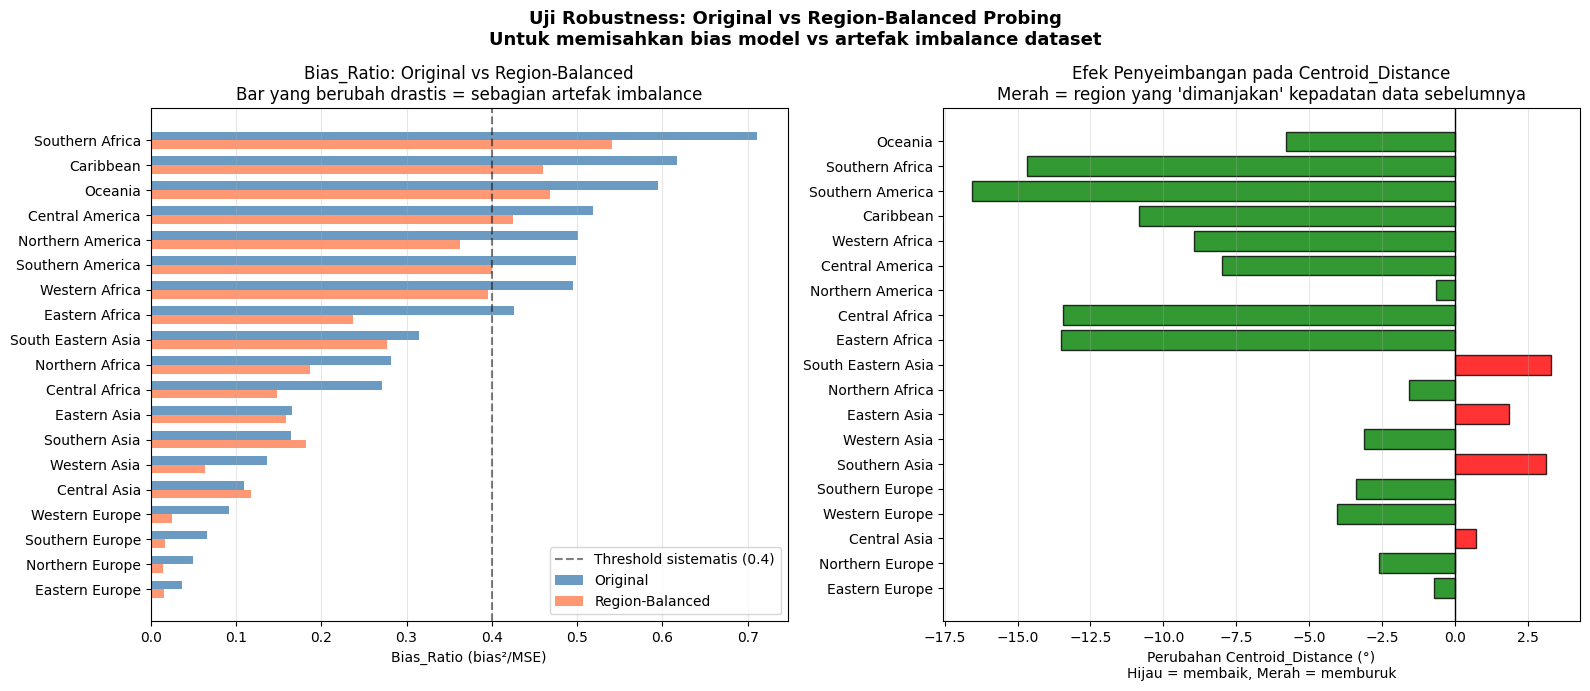

In [29]:
# ============================================================
# EKSPERIMEN D — Visualisasi Perbandingan Asli vs Seimbang
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Perbandingan Bias_Ratio
ax = axes[0]
df_plot_left = df_compare.sort_values("BiasRatio_Original", ascending=True)
x = np.arange(len(df_plot_left))
w = 0.35

ax.barh(x + w/2, df_plot_left["BiasRatio_Original"],
        w, label="Original", color="steelblue", alpha=0.8)
ax.barh(x - w/2, df_plot_left["Bias_Ratio_Bal"],
        w, label="Region-Balanced", color="coral", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(df_plot_left["Region"])
ax.axvline(0.4, color='black', linestyle='--', alpha=0.5,
           label='Threshold sistematis (0.4)')
ax.set_xlabel("Bias_Ratio (bias²/MSE)")
ax.set_title("Bias_Ratio: Original vs Region-Balanced\n"
             "Bar yang berubah drastis = sebagian artefak imbalance")
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 2: Perbandingan Centroid_Distance
ax = axes[1]
df_sorted = df_compare.sort_values("CentDist_Original", ascending=True)
colors = ['green' if c < 0 else 'red'
          for c in df_sorted["CentDist_Change"]]
ax.barh(df_sorted["Region"], df_sorted["CentDist_Change"],
        color=colors, alpha=0.8, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("Perubahan Centroid_Distance (°)\nHijau = membaik, Merah = memburuk")
ax.set_title("Efek Penyeimbangan pada Centroid_Distance\n"
             "Merah = region yang 'dimanjakan' kepadatan data sebelumnya")
ax.grid(axis='x', alpha=0.3)

plt.suptitle("Uji Robustness: Original vs Region-Balanced Probing\n"
             "Untuk memisahkan bias model vs artefak imbalance dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("robustness_balanced_probing.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================
# EKSPERIMEN D — Ringkasan Effect Size per Wilayah
# Klasifikasi GENUINE / MIXED / IMBALANCE berdasarkan besar
# perubahan Bias_Ratio setelah pembobotan region-balanced.
# ============================================================

print("\n RINGKASAN EFFECT SIZE:")
print(f"{'Region':<22} {'Orig':>8} {'Bal':>8} {'%Change':>10} {'Status'}")
print("-"*65)
for _, row in df_compare.sort_values("BiasRatio_Original",
                                      ascending=False).iterrows():
    pct = (row["Bias_Ratio_Bal"] - row["BiasRatio_Original"]) \
          / row["BiasRatio_Original"] * 100
    status = "GENUINE" if abs(pct) < 15 else \
             "MIXED"   if abs(pct) < 40 else "IMBALANCE"
    print(f"{row['Region']:<22} {row['BiasRatio_Original']:>8.3f} "
          f"{row['Bias_Ratio_Bal']:>8.3f} {pct:>9.1f}%  {status}")


 RINGKASAN EFFECT SIZE:
Region                     Orig      Bal    %Change Status
-----------------------------------------------------------------
Southern Africa           0.711    0.541     -23.9%  MIXED
Caribbean                 0.617    0.459     -25.6%  MIXED
Oceania                   0.595    0.468     -21.3%  MIXED
Central America           0.518    0.425     -18.0%  MIXED
Northern America          0.501    0.363     -27.6%  MIXED
Southern America          0.498    0.400     -19.7%  MIXED
Western Africa            0.495    0.395     -20.2%  MIXED
Eastern Africa            0.426    0.237     -44.5%  IMBALANCE
South Eastern Asia        0.315    0.278     -11.7%  GENUINE
Northern Africa           0.282    0.187     -33.7%  MIXED
Central Africa            0.272    0.149     -45.3%  IMBALANCE
Eastern Asia              0.165    0.159      -3.7%  GENUINE
Southern Asia             0.165    0.183      10.9%  GENUINE
Western Asia              0.137    0.064     -53.5%  IMBALANCE
Centra

In [31]:
# ============================================================
# EKSPERIMEN D — Ranking Perbandingan Centroid_Distance
# ============================================================

print("10 region terbaik di kondisi ORIGINAL:")
print(df_compare.nsmallest(10, "CentDist_Original")[
    ["Region", "CentDist_Original"]].to_string(index=False))

print("\n10 region terbaik di kondisi BALANCED:")
print(df_compare.nsmallest(10, "CentDist_Balanced")[
    ["Region", "CentDist_Balanced"]].to_string(index=False))

# Ranking semua region, bukan hanya Western Asia
print("\n RANKING SEMUA REGION: Original vs Balanced")
print(f"{'Region':<22} {'Orig(°)':>8} {'Rank_Orig':>10} {'Bal(°)':>8} {'Rank_Bal':>9} {'ΔRank':>7}")
print("-" * 70)

df_compare["Rank_Original"] = df_compare["CentDist_Original"].rank().astype(int)
df_compare["Rank_Balanced"] = df_compare["CentDist_Balanced"].rank().astype(int)
df_compare["Delta_Rank"]    = df_compare["Rank_Balanced"] - df_compare["Rank_Original"]

for _, row in df_compare.sort_values("Rank_Original").iterrows():
    delta = row["Delta_Rank"]
    arah  = f"↑{abs(delta)}" if delta < 0 else (f"↓{delta}" if delta > 0 else "=")
    print(f"{row['Region']:<22} {row['CentDist_Original']:>8.2f} "
          f"{row['Rank_Original']:>10} {row['CentDist_Balanced']:>8.2f} "
          f"{row['Rank_Balanced']:>9} {arah:>7}")

10 region terbaik di kondisi ORIGINAL:
            Region  CentDist_Original
    Eastern Europe           4.417183
   Northern Europe           6.517666
      Central Asia           9.628120
    Western Europe           9.816969
   Southern Europe          11.011637
     Southern Asia          11.219741
      Western Asia          12.035631
      Eastern Asia          12.505212
   Northern Africa          16.091372
South Eastern Asia          28.621193

10 region terbaik di kondisi BALANCED:
         Region  CentDist_Balanced
 Eastern Europe           3.699446
Northern Europe           3.901814
 Western Europe           5.759090
Southern Europe           7.626371
   Western Asia           8.901015
   Central Asia          10.355871
  Southern Asia          14.340552
   Eastern Asia          14.343984
Northern Africa          14.505642
 Eastern Africa          21.584017

 RANKING SEMUA REGION: Original vs Balanced
Region                  Orig(°)  Rank_Orig   Bal(°)  Rank_Bal   ΔRank
---

In [32]:
# ============================================================
# BASELINE — Prediktor Nihil (Null Predictor)
# Tujuan: menguji apakah pola arah bias (mis. Oceania -> Eropa)
# adalah representasi genuine atau sekadar shrinkage Ridge menuju
# rata-rata data latih (lihat Bab III.2.5, III.3.5.3).
# ============================================================
from sklearn.dummy import DummyRegressor

null_model = DummyRegressor(strategy='mean')

pred_xyz_null = cross_val_predict(
    null_model, X_f, y_xyz_f,
    cv=cv_f, groups=food_groups
)
pred_lat_null, pred_lon_null = xyz_to_latlon(pred_xyz_null)

gc_err_null = great_circle_deg(y_lat_f, y_lon_f, pred_lat_null, pred_lon_null)
avg_err_null = gc_err_null.mean()
std_err_null = gc_err_null.std()  # TAMBAHAN: standar deviasi galat great-circle
print(f"Prediktor Nihil — Average Global Error: {avg_err_null:.2f} derajat (SD: {std_err_null:.2f}°, n={len(gc_err_null)})")

# Lokasi rata-rata data latih (satu titik tetap, tanpa memandang input)
mean_lat_null, mean_lon_null = xyz_to_latlon(y_xyz_f.mean(axis=0))
mean_lat_null = float(np.ravel(mean_lat_null)[0])
mean_lon_null = float(np.ravel(mean_lon_null)[0])
print(f"Lokasi rata-rata data latih: ({mean_lat_null:.2f}, {mean_lon_null:.2f})")

# Uji langsung hipotesis "target kekeliruan = artefak shrinkage":
# wilayah mana yang centroid ASLI-nya paling dekat ke titik rata-rata ini?
df_centroids['Dist_NullMean_to_ActualCentroid'] = great_circle_deg(
    mean_lat_null, mean_lon_null,
    df_centroids['Actual_Centroid_Lat'], df_centroids['Actual_Centroid_Lon']
)
print(df_centroids[['Region', 'Dist_NullMean_to_ActualCentroid']]
      .sort_values('Dist_NullMean_to_ActualCentroid').to_string(index=False))

Prediktor Nihil — Average Global Error: 49.13 derajat (SD: 30.57°, n=4872)
Lokasi rata-rata data latih: (52.37, 41.42)
            Region  Dist_NullMean_to_ActualCentroid
    Eastern Europe                         3.140406
   Northern Europe                        16.726682
      Central Asia                        20.169241
      Western Asia                        20.471429
   Southern Europe                        23.049378
    Western Europe                        23.099589
   Northern Africa                        31.219840
     Southern Asia                        41.611293
    Eastern Africa                        51.421051
    Western Africa                        53.746145
    Central Africa                        55.038482
      Eastern Asia                        56.972058
South Eastern Asia                        70.619074
   Southern Africa                        82.108711
  Northern America                        86.372284
         Caribbean                        88.0580

In [33]:
# ============================================================
# BASELINE — Static Embedding (Non-Representasional)
# Tujuan: menguji apakah performa probe atas hidden state LLM
# melampaui performa yang bisa dicapai semata dari kemiripan
# ortografis nama artefak (lihat Bab II.2.3, III.2.6).
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# GANTI 'Food' sesuai nama kolom nama artefak di df_ind Anda
food_names = df_ind['Food'].tolist()

char_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=2000)
X_static = char_vectorizer.fit_transform(food_names).toarray()

probe_static = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                      scoring='neg_mean_absolute_error'))
])

pred_xyz_static = cross_val_predict(
    probe_static, X_static, y_xyz_f,
    cv=cv_f, groups=food_groups,
    params={'ridge__sample_weight': food_weights_arr}
)
pred_lat_static, pred_lon_static = xyz_to_latlon(pred_xyz_static)

gc_err_static = great_circle_deg(y_lat_f, y_lon_f, pred_lat_static, pred_lon_static)
avg_err_static = gc_err_static.mean()
std_err_static = gc_err_static.std()  # TAMBAHAN: standar deviasi galat great-circle
print(f"Static Embedding (char n-gram) — Average Global Error: {avg_err_static:.2f} derajat (SD: {std_err_static:.2f}°, n={len(gc_err_static)})")

Static Embedding (char n-gram) — Average Global Error: 40.59 derajat (SD: 29.82°, n=4872)


In [34]:
print(f"{'Kondisi':35} {'Avg Error (°)':>15}")
print("-" * 50)
print(f"{'Prediktor Nihil':35} {avg_err_null:>15.2f}")
print(f"{'Static Embedding (char n-gram)':35} {avg_err_static:>15.2f}")
print(f"{'Probe LLM (Eksperimen B)':35} {avg_err_f:>15.2f}")

Kondisi                               Avg Error (°)
--------------------------------------------------
Prediktor Nihil                               49.13
Static Embedding (char n-gram)                40.59
Probe LLM (Eksperimen B)                      35.50


In [35]:
# ============================================================
# LAYER-WISE 0 — Ekstraksi Pure Embedding SEMUA Layer
# Tujuan: menjawab saran penguji ("analisis terhadap semua layer").
# Satu forward pass per artefak (sama seperti Eksperimen A), tetapi
# SEMUA hidden state (layer 0 = embedding ... layer N = keluaran akhir)
# disimpan, bukan hanya layer terakhir. Hanya kondisi berbasis
# embedding (Agregat dan Individual) yang di-layer-kan; kondisi
# Kontrol berbasis prompt tetap di layer terakhir (definisinya di
# level distribusi keluaran).
# Prasyarat: Cell 12 (pure_food_cache) sudah dijalankan.
# ============================================================

import os, json, time
import numpy as np
import torch

# --- KONFIGURASI ---
ALL_LAYERS_FILE  = os.path.join(SAVE_DIR, "croissantLLM_pure_food_alllayers_fp16.npy")
ALL_LAYERS_NAMES = os.path.join(SAVE_DIR, "croissantLLM_pure_food_alllayers_names.json")
# True  : final RMSNorm diterapkan ke layer 0..N-1 (layer N memang sudah
#         ternormalisasi oleh model) -> skala konsisten, kurva kontinu,
#         dan titik layer terakhir identik dengan angka di laporan.
# False : residual stream mentah untuk layer 0..N-1 (layer N tetap
#         ternormalisasi) -> ada diskontinuitas skala di ujung kurva.
NORMALIZE_LAYERS = True
# -------------------

def get_final_norm(model):
    """Cari modul final RMSNorm (path berbeda antar arsitektur)."""
    for path in ["model.norm",                    # Qwen2, Llama, Kanana, Sarvam, Croissant
                 "model.language_model.norm",     # Gemma3 / Ministral3 (VLM wrapper)
                 "language_model.model.norm",
                 "model.language_model.model.norm"]:
        obj = model
        for part in path.split("."):
            obj = getattr(obj, part, None)
            if obj is None:
                break
        if obj is not None and callable(obj):
            return obj, path
    raise RuntimeError("Final norm tidak ditemukan. Cek print(model) dan tambahkan path-nya di get_final_norm().")

print("=" * 65)
print("LAYER-WISE 0 — EKSTRAKSI PURE EMBEDDING SEMUA LAYER")
print("=" * 65)

# Urutan & nama diambil dari cache layer-terakhir (BUKAN dari `food_names`,
# karena variabel itu ditimpa di sel Static Embedding).
layer_names = [str(k) for k in pure_food_cache.keys()]
N_art = len(layer_names)
D_hid = int(next(iter(pure_food_cache.values())).shape[-1])
L1 = num_layers + 1                       # layer 0 (embedding) .. num_layers

# --- Auto-load jika cache sudah ada dan cocok ---
RUN_ALL = True
if os.path.exists(ALL_LAYERS_FILE) and os.path.exists(ALL_LAYERS_NAMES):
    with open(ALL_LAYERS_NAMES) as f:
        cached_names = json.load(f)
    F_all = np.load(ALL_LAYERS_FILE)
    if cached_names == layer_names and F_all.shape == (N_art, L1, D_hid):
        print(f"Cache semua-layer ditemukan: {F_all.shape} (fp16). Ekstraksi di-skip.")
        RUN_ALL = False
    else:
        print("Cache lama tidak cocok (nama/jumlah/layer berbeda). Ekstraksi ulang...")

if RUN_ALL:
    _check_model_loaded()
    final_norm, norm_path = get_final_norm(model)
    norm_dtype = next(final_norm.parameters()).dtype
    print(f"Final norm: model.{norm_path}  (dtype {norm_dtype}) | "
          f"{N_art} artefak x {L1} layer x {D_hid} dim")

    # --- Cek asumsi: hidden_states[-1] sudah melewati final norm ---
    if NORMALIZE_LAYERS:
        _cap = {}
        _hook = final_norm.register_forward_hook(
            lambda m, i, o: _cap.__setitem__("o", o[:, -1, :].detach().float().clone()))
        _hs = safe_forward(model, tokenizer, layer_names[0])
        _hook.remove()
        gap = (_cap["o"] - _hs[-1]).abs().max().item()
        assert gap < 1e-2 * max(1.0, _hs[-1].abs().max().item()), (
            f"hidden_states[-1] TIDAK identik dengan keluaran final norm (selisih maks {gap:.3g}). "
            "Asumsi 'layer terakhir sudah ternormalisasi' gagal pada versi transformers ini; "
            "set NORMALIZE_LAYERS=False atau sesuaikan kode.")
        print(f"Cek asumsi OK: hidden_states[-1] == keluaran final norm (selisih maks {gap:.2g}).")
        del _hs, _cap

    F_all = np.zeros((N_art, L1, D_hid), dtype=np.float16)
    max_abs = 0.0
    t0 = time.time()
    for i, name in enumerate(layer_names):
        if (i + 1) % 200 == 0:
            print(f"  [{i+1}/{N_art}] {time.time()-t0:.0f}s")
        hs = safe_forward(model, tokenizer, name)       # tuple (L1) tensor (1, D), float32
        H = torch.cat(hs, dim=0)                         # (L1, D)
        if NORMALIZE_LAYERS:
            with torch.no_grad():
                Hn = final_norm(H[:-1].to(norm_dtype)).float()   # layer 0..N-1
            H = torch.cat([Hn, H[-1:]], dim=0)                   # layer N sudah ternormalisasi
        arr = H.cpu().numpy()
        max_abs = max(max_abs, float(np.abs(arr).max()))
        F_all[i] = arr.astype(np.float16)
        del hs, H
    assert max_abs < 6e4 and np.isfinite(F_all).all(), (
        f"Nilai di luar jangkauan fp16 (maks |x|={max_abs:.3g}). Simpan sebagai float32 atau pakai NORMALIZE_LAYERS=True.")
    np.save(ALL_LAYERS_FILE, F_all)
    with open(ALL_LAYERS_NAMES, "w") as f:
        json.dump(layer_names, f)
    flush()
    print(f"Selesai {time.time()-t0:.0f}s. Disimpan: {ALL_LAYERS_FILE} "
          f"({F_all.nbytes/1e6:.0f} MB)")

# --- Sanity check: layer terakhir harus identik dengan cache Eksperimen A ---
last_ref = np.stack(list(pure_food_cache.values())).astype(np.float32)
d_last = np.abs(F_all[:, -1, :].astype(np.float32) - last_ref).max()
print(f"Selisih maks layer terakhir vs pure_food_cache: {d_last:.3g}  "
      f"({'OK' if d_last < 1e-1 else 'PERIKSA!'})")
print(f"F_all: {F_all.shape} -> (artefak, layer 0..{num_layers}, dim)")

LAYER-WISE 0 — EKSTRAKSI PURE EMBEDDING SEMUA LAYER
Cache semua-layer ditemukan: (2414, 25, 2048) (fp16). Ekstraksi di-skip.
Selisih maks layer terakhir vs pure_food_cache: 0.00781  (OK)
F_all: (2414, 25, 2048) -> (artefak, layer 0..24, dim)


LAYER-WISE 1 — PROBING PER LAYER (AGREGAT + INDIVIDUAL)
Cek fitur layer terakhir vs Cell 13: selisih maks 0.0042
Cek fitur layer terakhir vs Cell 18: selisih maks 0.0078
Agregat selesai: 25 layer x 5 seed, 36s
  Individual layer 24 | err  35.50° |  1259s (sisa ~0s)
Individual selesai: 25 layer, 1259s

AGREGAT (Err_s42 = seed laporan; Err_mean±Err_sd = rata-rata atas seed CV):
 Layer  Depth  Err_s42  Err_mean  Err_sd  SD_titik  R2_lat  R2_lon  Alpha
     0  0.000   18.651    18.862   0.530    20.103   0.353   0.813  150.0
     1  0.042   19.036    18.974   0.523    19.904   0.313   0.807   50.0
     2  0.083   18.292    18.393   0.606    19.840   0.374   0.809   50.0
     3  0.125   17.851    17.867   0.619    21.169   0.435   0.799   50.0
     4  0.167   18.632    18.406   0.671    21.300   0.421   0.789  150.0
     5  0.208   18.281    18.078   0.700    20.894   0.431   0.791   50.0
     6  0.250   18.662    18.638   0.599    21.420   0.398   0.786   50.0
     7  0.292   18.070    17.

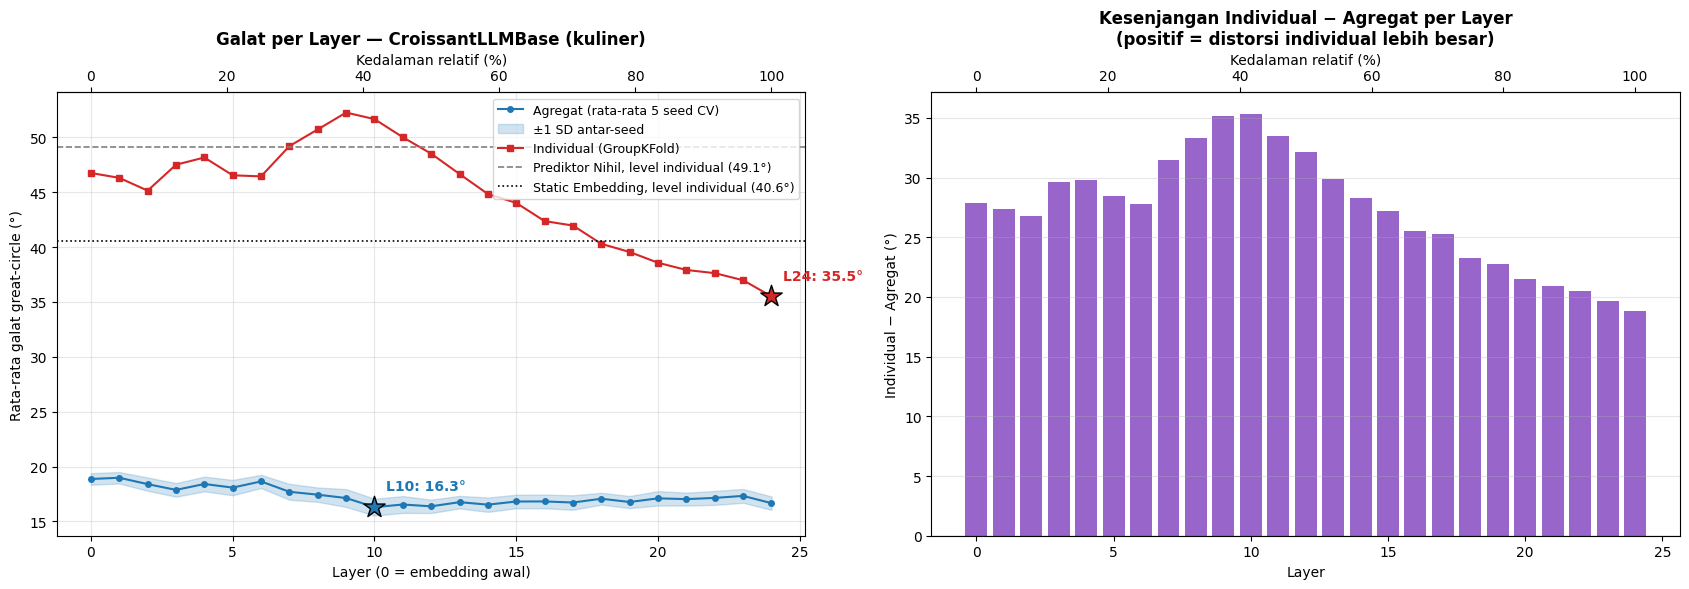

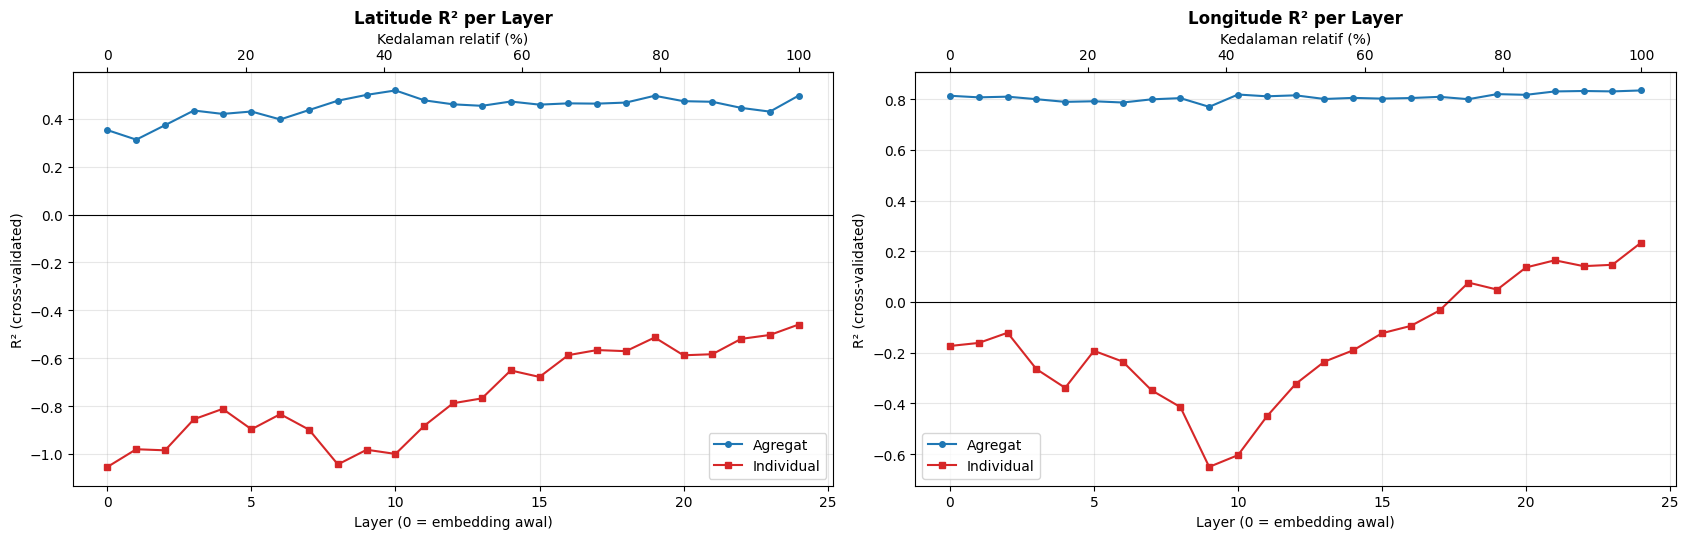

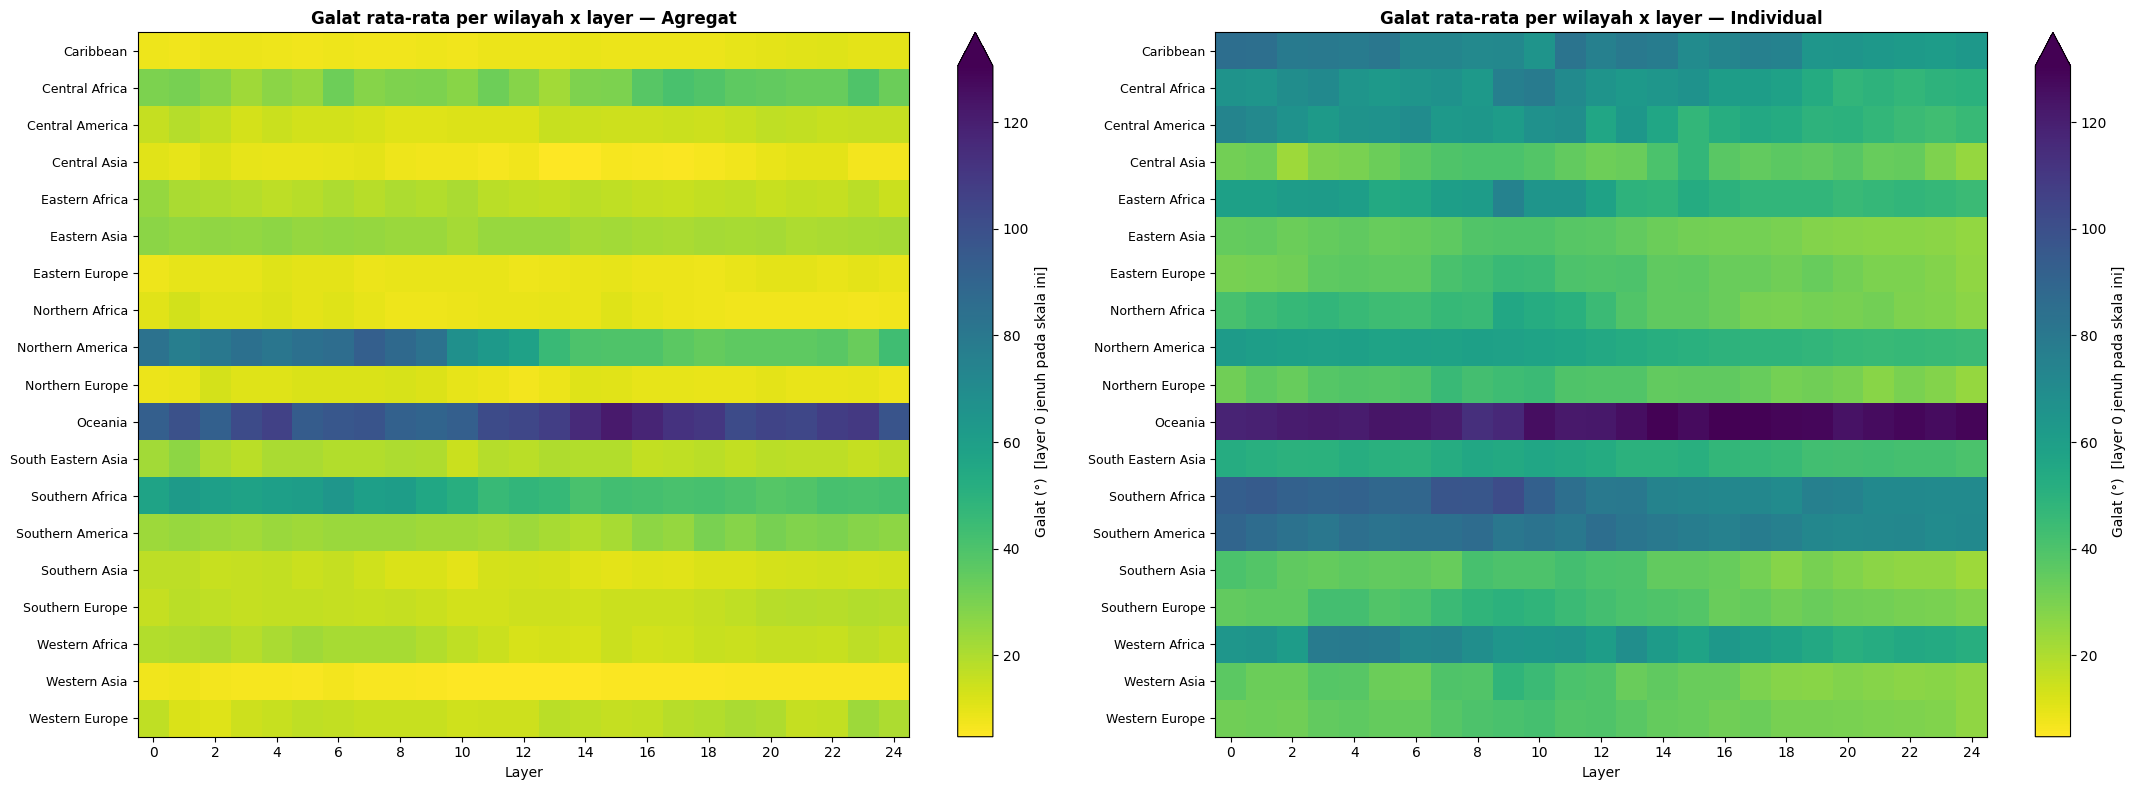


Tersimpan di /content/drive/MyDrive/Percobaan TA/Food KB/Data/: CroissantLLMBase_kuliner_layerwise_*.csv / *.png


In [36]:
# ============================================================
# LAYER-WISE 1 — Linear Probing per Layer (Agregat + Individual)
# Memakai PIPELINE, FOLD, DAN METRIK YANG SAMA dengan Cell 13
# (Agregat) dan Cell 18 (Individual); satu-satunya yang berubah
# adalah fitur: hidden state layer l dari F_all (Layer-wise 0).
# Output: tabel per layer, kurva Error, R2, selisih Individual-Agregat,
# dan heatmap error per wilayah x layer.
# Prasyarat: Cell 13, Cell 18, dan Layer-wise 0 sudah dijalankan.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- KONFIGURASI ---
DOMAIN_TAG       = "kuliner"
ALPHAS_PROBE     = [0.1, 1.0, 10.0, 50.0, 150.0, 500.0]   # sama dengan Cell 13/18
AGG_SEEDS        = [42, 43, 44, 45, 46]  # 42 = seed laporan; sisanya untuk mengukur noise CV
LAYER_STEP_IND   = 1                     # Individual paling lambat; set 2 untuk ~2x lebih cepat
# -------------------

_required = ["F_all", "layer_names", "num_layers", "valid_pure_countries", "country_to_foods_map",
             "y_lat_pure", "y_lon_pure", "food_labels", "food_regions", "y_xyz_f", "y_lat_f",
             "y_lon_f", "food_weights_arr", "food_groups", "cv_f", "X_f", "X_pure"]
_missing = [v for v in _required if v not in globals()]
assert not _missing, f"Jalankan dulu Cell 13, Cell 18, dan Layer-wise 0. Belum ada: {_missing}"

print("=" * 65)
print("LAYER-WISE 1 — PROBING PER LAYER (AGREGAT + INDIVIDUAL)")
print("=" * 65)

L1 = F_all.shape[1]
layer_ids = list(range(L1))
layers_ind = sorted(set(range(0, L1, LAYER_STEP_IND)) | {L1 - 1})
tag = f"{MODEL_ID.split('/')[-1]}_{DOMAIN_TAG}"

# ── Pemetaan baris -> indeks artefak di F_all ──
name_to_idx = {}
for i, n in enumerate(layer_names):
    name_to_idx[n] = i
    name_to_idx.setdefault(n.strip(), i)

# Agregat: matriks rata-rata (negara x artefak), duplikat dihitung seperti np.mean(list) di Cell 13
W_agg = np.zeros((len(valid_pure_countries), len(layer_names)), dtype=np.float32)
for r, c in enumerate(valid_pure_countries):
    for f in country_to_foods_map[c]:
        W_agg[r, name_to_idx[str(f)]] += 1.0
W_agg /= W_agg.sum(axis=1, keepdims=True)

y_xyz_pure = latlon_to_xyz(y_lat_pure, y_lon_pure)
agg_regions = np.array([get_country_region(c) for c in valid_pure_countries])

# Individual: indeks baris sesuai urutan X_f pada Cell 18
idx_rows = np.array([name_to_idx[str(n).strip()] for n in food_labels])
ind_regions = np.array(food_regions)
assert len(idx_rows) == len(X_f)

def _make_probe():
    return Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=ALPHAS_PROBE, scoring='neg_mean_absolute_error'))
    ])

# ── Sanity: fitur layer terakhir harus identik dengan Cell 13 / Cell 18 ──
_Xa_last = W_agg @ F_all[:, -1, :].astype(np.float32)
_Xi_last = F_all[idx_rows, -1, :].astype(np.float32)
print(f"Cek fitur layer terakhir vs Cell 13: selisih maks {np.abs(_Xa_last - X_pure).max():.2g}")
print(f"Cek fitur layer terakhir vs Cell 18: selisih maks {np.abs(_Xi_last - X_f).max():.2g}")

# ── Probing Agregat per layer (KFold acak, beberapa seed) ──
def probe_agg(X, seed):
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    pred = cross_val_predict(_make_probe(), X, y_xyz_pure, cv=cv)
    lat, lon = xyz_to_latlon(pred)
    err = great_circle_deg(y_lat_pure, y_lon_pure, lat, lon)
    return err, r2_score(y_lat_pure, lat), r2_score(y_lon_pure, lon)

rows_agg, err_pt_agg = [], {}
t0 = time.time()
for l in layer_ids:
    X = W_agg @ F_all[:, l, :].astype(np.float32)
    per_seed = [probe_agg(X, s) for s in AGG_SEEDS]
    errs = np.array([e.mean() for e, _, _ in per_seed])
    err_pt_agg[l] = per_seed[0][0]                       # per-titik, seed laporan
    alpha_full = _make_probe().fit(X, y_xyz_pure).named_steps['ridge'].alpha_
    rows_agg.append(dict(
        Layer=l, Depth=l / num_layers,
        Err_s42=errs[0], Err_mean=errs.mean(), Err_sd=errs.std(ddof=1) if len(errs) > 1 else 0.0,
        SD_titik=per_seed[0][0].std(),
        R2_lat=np.mean([a for _, a, _ in per_seed]), R2_lon=np.mean([b for _, _, b in per_seed]),
        Alpha=alpha_full))
df_layer_agg = pd.DataFrame(rows_agg)
print(f"Agregat selesai: {len(layer_ids)} layer x {len(AGG_SEEDS)} seed, {time.time()-t0:.0f}s")

# ── Probing Individual per layer (GroupKFold deterministik, bobot 1/N negara) ──
def probe_ind(X):
    pred = np.zeros_like(y_xyz_f)
    alphas = []
    for tr, te in cv_f.split(X, y_xyz_f, food_groups):
        p = _make_probe()
        p.fit(X[tr], y_xyz_f[tr], ridge__sample_weight=food_weights_arr[tr])
        pred[te] = p.predict(X[te])
        alphas.append(p.named_steps['ridge'].alpha_)
    lat, lon = xyz_to_latlon(pred)
    err = great_circle_deg(y_lat_f, y_lon_f, lat, lon)
    return err, r2_score(y_lat_f, lat), r2_score(y_lon_f, lon), alphas

rows_ind, err_pt_ind = [], {}
t0 = time.time()
for k, l in enumerate(layers_ind):
    X = F_all[idx_rows, l, :].astype(np.float32)
    err, r2a, r2o, alphas = probe_ind(X)
    err_pt_ind[l] = err
    rows_ind.append(dict(
        Layer=l, Depth=l / num_layers, Err=err.mean(), SD_titik=err.std(),
        R2_lat=r2a, R2_lon=r2o, Alpha_med=float(np.median(alphas)),
        Alpha_di_batas=float(np.mean(np.array(alphas) == max(ALPHAS_PROBE)))))
    el = time.time() - t0
    print(f"  Individual layer {l:>2} | err {err.mean():6.2f}° | "
          f"{el:5.0f}s (sisa ~{el/(k+1)*(len(layers_ind)-k-1):.0f}s)", end="\r")
df_layer_ind = pd.DataFrame(rows_ind)
print(f"\nIndividual selesai: {len(layers_ind)} layer, {time.time()-t0:.0f}s")

# ── Tabel ringkas & simpan ──
pd.set_option("display.width", 200)
print("\nAGREGAT (Err_s42 = seed laporan; Err_mean±Err_sd = rata-rata atas seed CV):")
print(df_layer_agg.round(3).to_string(index=False))
print("\nINDIVIDUAL:")
print(df_layer_ind.round(3).to_string(index=False))
df_layer_agg.to_csv(os.path.join(SAVE_DIR, f"{tag}_layerwise_agregat.csv"), index=False)
df_layer_ind.to_csv(os.path.join(SAVE_DIR, f"{tag}_layerwise_individual.csv"), index=False)

# ── Verifikasi replikasi layer terakhir terhadap hasil laporan ──
last = L1 - 1
print("\nREPLIKASI LAYER TERAKHIR:")
if "avg_err_pure" in globals():
    print(f"  Agregat    : {df_layer_agg.loc[df_layer_agg.Layer == last, 'Err_s42'].iloc[0]:.2f}°  vs Cell 13 = {avg_err_pure:.2f}°")
if "avg_err_f" in globals():
    print(f"  Individual : {df_layer_ind.loc[df_layer_ind.Layer == last, 'Err'].iloc[0]:.2f}°  vs Cell 18 = {avg_err_f:.2f}°")

# ── Ringkasan: layer 0, layer terbaik (eksploratif), layer terakhir ──
def _summ(df, col, name):
    i_best = df[col].idxmin()
    b, f0, fl = df.loc[i_best], df.iloc[0], df.iloc[-1]
    print(f"  {name:10}: layer 0 = {f0[col]:.2f}° | terbaik = layer {int(b.Layer)} "
          f"({b.Depth*100:.0f}% kedalaman) {b[col]:.2f}° | terakhir = {fl[col]:.2f}°")
print("\nRINGKASAN (layer 'terbaik' dipilih pada data yang sama dengan evaluasinya -> OPTIMISTIS; "
      "laporkan seluruh kurva, bukan hanya minimumnya):")
_summ(df_layer_agg, "Err_mean", "Agregat")
_summ(df_layer_ind, "Err", "Individual")
b = df_layer_agg.loc[df_layer_agg.Err_mean.idxmin()]
print(f"  Noise CV Agregat pada layer terbaik: SD antar-seed = {b.Err_sd:.2f}° "
      f"(selisih < ~2 SD jangan diinterpretasi sebagai beda nyata)")
if df_layer_ind.Alpha_di_batas.mean() > 0.3:
    print(f"  PERINGATAN: alpha Individual menyentuh batas atas grid ({max(ALPHAS_PROBE)}) "
          f"pada {df_layer_ind.Alpha_di_batas.mean()*100:.0f}% fold-layer; pertimbangkan grid lebih lebar "
          f"(catat bahwa layer terakhir tidak lagi persis sama dengan laporan).")

# ═══════════════ VISUALISASI ═══════════════
C_AGG, C_IND = "#1f77b4", "#d62728"
def _depth_axis(ax):
    sec = ax.secondary_xaxis("top", functions=(lambda x: x / num_layers * 100, lambda x: x * num_layers / 100))
    sec.set_xlabel("Kedalaman relatif (%)", fontsize=10)

# Figure 1: Error per layer + selisih Individual - Agregat
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
ax1.plot(df_layer_agg.Layer, df_layer_agg.Err_mean, "-o", ms=4, color=C_AGG, label=f"Agregat (rata-rata {len(AGG_SEEDS)} seed CV)")
ax1.fill_between(df_layer_agg.Layer, df_layer_agg.Err_mean - df_layer_agg.Err_sd,
                 df_layer_agg.Err_mean + df_layer_agg.Err_sd, color=C_AGG, alpha=0.2, label="±1 SD antar-seed")
ax1.plot(df_layer_ind.Layer, df_layer_ind.Err, "-s", ms=4, color=C_IND, label="Individual (GroupKFold)")
if "avg_err_null" in globals():
    ax1.axhline(avg_err_null, ls="--", color="gray", lw=1.2, label=f"Prediktor Nihil, level individual ({avg_err_null:.1f}°)")
if "avg_err_static" in globals():
    ax1.axhline(avg_err_static, ls=":", color="black", lw=1.2, label=f"Static Embedding, level individual ({avg_err_static:.1f}°)")
for df, col, c in [(df_layer_agg, "Err_mean", C_AGG), (df_layer_ind, "Err", C_IND)]:
    ib = df[col].idxmin()
    ax1.scatter(df.Layer[ib], df[col][ib], marker="*", s=260, color=c, edgecolor="black", zorder=6)
    ax1.annotate(f"L{int(df.Layer[ib])}: {df[col][ib]:.1f}°", (df.Layer[ib], df[col][ib]),
                 xytext=(8, 12), textcoords="offset points", fontsize=10, color=c, fontweight="bold")
ax1.set_xlabel("Layer (0 = embedding awal)"); ax1.set_ylabel("Rata-rata galat great-circle (°)")
ax1.set_title(f"Galat per Layer — {MODEL_ID.split('/')[-1]} ({DOMAIN_TAG})", fontweight="bold")
ax1.grid(alpha=0.3); ax1.legend(fontsize=9, loc="upper right"); _depth_axis(ax1)

common = sorted(set(df_layer_agg.Layer) & set(df_layer_ind.Layer))
gap = (df_layer_ind.set_index("Layer").loc[common, "Err"]
       - df_layer_agg.set_index("Layer").loc[common, "Err_mean"])
ax2.bar(common, gap.values, color="#7f3fbf", alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("Layer"); ax2.set_ylabel("Individual − Agregat (°)")
ax2.set_title("Kesenjangan Individual − Agregat per Layer\n(positif = distorsi individual lebih besar)", fontweight="bold")
ax2.grid(alpha=0.3, axis="y"); _depth_axis(ax2)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"{tag}_layerwise_error.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: R2 latitude & longitude per layer
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, ca, ci, ttl in [(axes[0], "R2_lat", "R2_lat", "Latitude R²"), (axes[1], "R2_lon", "R2_lon", "Longitude R²")]:
    ax.plot(df_layer_agg.Layer, df_layer_agg[ca], "-o", ms=4, color=C_AGG, label="Agregat")
    ax.plot(df_layer_ind.Layer, df_layer_ind[ci], "-s", ms=4, color=C_IND, label="Individual")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Layer (0 = embedding awal)"); ax.set_ylabel("R² (cross-validated)")
    ax.set_title(f"{ttl} per Layer", fontweight="bold"); ax.grid(alpha=0.3); ax.legend(); _depth_axis(ax)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"{tag}_layerwise_r2.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Heatmap galat per wilayah x layer
def _region_layer_matrix(err_pt, regions, layers):
    regs = sorted(set(regions))
    M = np.full((len(regs), len(layers)), np.nan)
    for j, l in enumerate(layers):
        for i, r in enumerate(regs):
            M[i, j] = err_pt[l][regions == r].mean()
    return regs, M

regs_a, M_a = _region_layer_matrix(err_pt_agg, agg_regions, layer_ids)
regs_i, M_i = _region_layer_matrix(err_pt_ind, ind_regions, layers_ind)
# skala warna tanpa layer 0 (embedding awal, galat sangat besar) agar variasi antar-layer terlihat
vmin = np.nanmin([M_a[:, 1:].min(), M_i[:, 1:].min()])
vmax = np.nanmax([M_a[:, 1:].max(), M_i[:, 1:].max()])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
for ax, M, regs, layers, ttl in [(ax1, M_a, regs_a, layer_ids, "Agregat"), (ax2, M_i, regs_i, layers_ind, "Individual")]:
    im = ax.imshow(M, aspect="auto", cmap="viridis_r", vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(regs))); ax.set_yticklabels(regs, fontsize=9)
    step = max(1, len(layers) // 12)
    ax.set_xticks(range(0, len(layers), step)); ax.set_xticklabels([layers[k] for k in range(0, len(layers), step)])
    ax.set_xlabel("Layer"); ax.set_title(f"Galat rata-rata per wilayah x layer — {ttl}", fontweight="bold")
    plt.colorbar(im, ax=ax, label="Galat (°)  [layer 0 jenuh pada skala ini]", extend="max")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"{tag}_layerwise_region_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTersimpan di {SAVE_DIR}: {tag}_layerwise_*.csv / *.png")

In [37]:
import os
import zipfile
from google.colab import files

# Mendeteksi semua file PNG di folder /content/
png_files = [f for f in os.listdir('.') if f.endswith('.png')]

if len(png_files) == 0:
    print("Tidak ditemukan file PNG di direktori saat ini.")
else:
    zip_filename = 'croissantLLM_all_visualization_maps.zip'

    # Membuat file zip dan memasukkan semua PNG
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file in png_files:
            zipf.write(file)
            print(f"Mengompresi: {file}")

    print(f"\nArsip zip berhasil dibuat: {zip_filename}")
    print("Memulai pengunduhan otomatis...")

    # Menjalankan fungsi download Colab
    files.download(zip_filename)

Mengompresi: pure_probing_southern_america.png
Mengompresi: pure_probing_eastern_europe.png
Mengompresi: control_map_western_europe.png
Mengompresi: pure_probing_eastern_asia.png
Mengompresi: flavor_map_full_eastern_africa.png
Mengompresi: flavor_map_full_central_asia.png
Mengompresi: control_map_northern_america.png
Mengompresi: control_map_oceania.png
Mengompresi: control_map_western_asia.png
Mengompresi: pure_probing_eastern_africa.png
Mengompresi: control_map_south_eastern_asia.png
Mengompresi: pure_probing_northern_america.png
Mengompresi: control_map_northern_africa.png
Mengompresi: pure_probing_southern_asia.png
Mengompresi: flavor_map_full_eastern_asia.png
Mengompresi: flavor_map_full_western_africa.png
Mengompresi: flavor_map_full_western_europe.png
Mengompresi: pure_probing_caribbean.png
Mengompresi: flavor_map_full_oceania.png
Mengompresi: control_map_southern_africa.png
Mengompresi: flavor_map_full_eastern_europe.png
Mengompresi: pure_probing_oceania.png
Mengompresi: flavor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>